In [103]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns 
import scipy.stats
from scipy.stats import gaussian_kde
from scipy.spatial.distance import euclidean, cosine
import numpy as np 
from numpy import dot
from numpy.linalg import norm
import pandas as pd
import os 
import json
import glob 
import itertools
import pickle
import random
import copy
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
import sys


from config import home_path, llm_review_path, supp_table_path

sys.path.insert(1, home_path) 
from common_functions import mean_confidence_interval, sort_dict_by_value, sort_dict_by_key, format_p, read_fasta

In [104]:

figure_path = llm_review_path + "high_res_figures/embedding_figure/"
SAVE_FIGS = False


def save_figure(fig, name, root_path = figure_path, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")
        

def p_val_to_stars(p):
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return "ns"

In [105]:
def cos_sim(a,b):
    return dot(a, b)/(norm(a)*norm(b))
   
def format_p(p):
    if p > 0.0001:
        return "{:.3g}".format(p)
    elif p < 10**(-256):
        return "< 10^{-256}"
    p = "{:.3g}".format(p)
    p = p.replace("e", " x 10^{") + "}"
    return p

def depickle_obj(fn):
    with open(fn, "rb") as f:
        data = pickle.load(f)
    f.close()
    return data

def get_cosine_similarity_from_ids(g1, g2, source_path = "./embeddings/esm_2_8M/", mean_reduce = True, include_end_tokens = True ):
    g1_data = depickle_obj(source_path + g1 + ".pkl")
    g2_data = depickle_obj(source_path + g2 + ".pkl")
    
    cls_1 = g1_data[0]
    cls_2 = g2_data[0]
    
    if include_end_tokens:
        
    
        mean_1 = np.mean(g1_data, axis  = 0)
        mean_2 = np.mean(g2_data, axis  = 0)
    else:
        mean_1 = np.mean(g1_data[1:-1], axis  = 0)
        mean_2 = np.mean(g2_data[1:-1], axis  = 0)
        

    if mean_reduce:
        return cos_sim(mean_1, mean_2)
    
    return cos_sim(cls_1,cls_2)

def get_all_pairs(lst):
    res = [(a, b) for idx, a in enumerate(lst) for b in lst[idx + 1:]]
    return res
        
    
def get_raw_embedding(g, source_path = "./embeddings/esm_2_8M/"):
    g_data = depickle_obj(source_path + g + ".pkl")
    return g_data

def get_aligned_fraction(s1, s2, use_local = False, get_maximum = True, return_score = False):
    
    if use_local:
        alignments = pairwise2.align.localxx(s1, s2)
    else:
        alignments = pairwise2.align.globalxx(s1, s2)
        
    if get_maximum:
        
        alignment = None 
        max_score = float("-inf")

        for k in alignments : 
            if k.score > max_score:
                max_score = k.score
                alignment = k
    else:
        alignment = alignments[0]
            
    matches = 0 
    mismatches = 0 
    gaps = 0

    seq_1_index = 0
    seq_2_index = 0

    cosine_dist_aln = []

    for c1, c2 in zip(alignments[0].seqA, alignments[0].seqB):
        if c1 != "-" and c2 != "-":
            if c1 == c2:
                matches += 1

        if c1 != "-":
            seq_1_index += 1

        if c2 != "-":
            seq_2_index += 1
            
    if return_score:
        return max_score, max(matches / len(s1), matches / len(s2))
            
    return max(matches / len(s1), matches / len(s2))


def get_cosine_similarity_from_ids_homstrad(g1, g2, source_path = "./embedding_extractions/esm_2_15B/", mean_reduce = True):
    g1_data = depickle_obj(source_path + g1 + ".pkl")
    g2_data = depickle_obj(source_path + g2 + ".pkl")
    
    cls_1 = g1_data[0]
    cls_2 = g2_data[0]
    
    mean_1 = np.mean(g1_data[1:-1], axis = 0)
    mean_2 = np.mean(g2_data[1:-1], axis = 0)
    
    if mean_reduce:
        return cos_sim(mean_1, mean_2)
    
    return cos_sim(cls_1,cls_2)
        

In [106]:
model_info = pd.read_csv("model_info.txt", delimiter = "\t")

display_names = dict(zip(model_info["model_string"], model_info["display_name"]))
model_to_dataset_string = dict(zip(model_info["model_string"], model_info["dataset_string"]))
model_to_params_string = dict(zip(model_info["model_string"], model_info["params_string"]))
model_to_base_string = dict(zip(model_info["model_string"], model_info["base_string"]))

In [107]:
orphan_path  = "../../Orphan25/"

orphan_25_names = glob.glob(orphan_path + "orphan_25_entries/*.fasta")
orphan_25_names = list(map(lambda x : x.replace(orphan_path + "orphan_25_entries/", "").replace(".fasta", ""), orphan_25_names))

non_orphan_names = glob.glob(orphan_path + "non_orphan_25_entries/*.fasta")
non_orphan_names = list(map(lambda x : x.replace(orphan_path + "non_orphan_25_entries/", "").replace(".fasta", ""), non_orphan_names))

models_in_question = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]

model_to_display_str = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}


In [108]:
orphan_human_distance_tracker = []

In [109]:
model_to_dists = {m : {} for m in models_in_question}

# distances for the orphan selections
for i , m in enumerate(models_in_question):
    orphan_25_pairs = get_all_pairs(orphan_25_names)
    all_distances = []
    for g in orphan_25_pairs:
        cs = get_cosine_similarity_from_ids(
            g[0], 
            g[1], 
            source_path = orphan_path +  "./embeddings/" + m + "/", 
            mean_reduce = True, 
            include_end_tokens=False
        )
        all_distances.append(cs)
        orphan_human_distance_tracker.append(["Orphan25", g[0], g[1], "Mean Pool", cs, m])
    model_to_dists[m]["orphan"] = all_distances 
    
# distances for the non-orphan selections
for i , m in enumerate(models_in_question):    
    non_orphan_pairs = get_all_pairs(non_orphan_names)
    all_distances = []
    for g in non_orphan_pairs:
        cs = get_cosine_similarity_from_ids(
            g[0], 
            g[1], 
            source_path = orphan_path + "./non_orphan_embeddings/" + m + "/", 
            mean_reduce = True, 
            include_end_tokens=False
        )
        
        orphan_human_distance_tracker.append(["Human Selections", g[0], g[1], "Mean Pool", cs , m])
        all_distances.append(cs)
    model_to_dists[m]["non_orphan"] = all_distances 

In [110]:
models_in_question = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]


esm_2_8M 0.00894
esm_2_35M 0.000347
esm_2_150M 1.16 x 10^{-08}
esm_2_650M 6.84 x 10^{-28}
esm_2 3.35 x 10^{-43}
esm_2_15B 8.18 x 10^{-10}


/tmp/ipykernel_21302/4265135649.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/4265135649.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


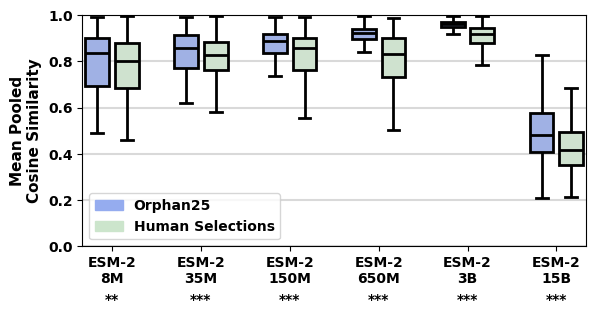

In [111]:
fig, ax = plt.subplots(figsize = (6.5,3))

data = []
x = []
my_pal = []
x_ticklabels = []
p_strings = []
stars = []

for i, m in enumerate(models_in_question):
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(model_to_dists[m]["orphan"])
    data.append(model_to_dists[m]["non_orphan"])
    data.append([])
    my_pal.append("#95acef")
    my_pal.append("#cce5cc")
    my_pal.append("white")
    x_ticklabels.append(model_to_base_string[m] + "\n" + model_to_params_string[m])
    
    _, p = scipy.stats.mannwhitneyu(
         model_to_dists[m]["orphan"],
         model_to_dists[m]["non_orphan"],
         alternative = "greater"
    )
    print(m, format_p(p))
    p_strings.append(r"$p = " + format_p(p) + "$")
    stars.append(p_val_to_stars(p))
    
# del my_pal[str((i*3) + 2)]
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)


x_ticks = np.arange(0.5, (6*3) + 0.001, 3)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 10, fontweight = "bold")
ax.set_ylim(top=1.05)
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

######################################################

## use this for the full p-val strings 
# for xpos, text in zip(x_ticks, p_strings):
#     ax.text(xpos, -0.06, text, horizontalalignment = "center", fontsize = 7)

## use this for the stars
for xpos, text in zip(x_ticks, stars):
    ax.text(xpos, -0.25, text, horizontalalignment = "center", fontsize = 10, fontweight = "bold")
    
######################################################
ax.set_ylabel("Mean Pooled\nCosine Similarity", fontsize = 11, fontweight = "bold")
    
blue_patch = mpatches.Patch(color="#95acef", label='Orphan25')
green_patch = mpatches.Patch(color="#cce5cc", label='Human Selections')

ax.set_yticks(ax.get_yticks())
ax.set_ylim(top = 1.0)

for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)

ax.legend(handles=[blue_patch,green_patch], loc = "lower left", prop = {"size" : 10, "weight" : "bold"})
save_figure(fig, "mean_pool_boxplots_orphan_v_human")

In [112]:
models_in_question = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]


In [113]:
model_to_cls_orphan_human = {m : {"orphan" : [], "human" : []} for m in models_in_question}

for m in models_in_question:
    for g in orphan_25_pairs:
        cs = get_cosine_similarity_from_ids(
            g[0], 
            g[1], 
            source_path = orphan_path +  "./embeddings/" + m + "/", 
            mean_reduce = False, 
            include_end_tokens=False
        )
        
        model_to_cls_orphan_human[m]["orphan"].append(cs)
        
        orphan_human_distance_tracker.append(["Orphan25", g[0], g[1], "CLS pool", cs, m])
        
    for g in non_orphan_pairs:
        cs = get_cosine_similarity_from_ids(
            g[0], 
            g[1], 
            source_path = orphan_path +  "./non_orphan_embeddings/" + m + "/", 
            mean_reduce = False, 
            include_end_tokens=False
        )
        
        orphan_human_distance_tracker.append(["Human Selections", g[0], g[1], "CLS pool", cs, m])
        
        model_to_cls_orphan_human[m]["human"].append(cs)
    

esm_2_8M 0.00484
esm_2_35M 0.999
esm_2_150M 4.05 x 10^{-05}
esm_2_650M 1.6 x 10^{-15}
esm_2 2.96 x 10^{-06}
esm_2_15B 1


/tmp/ipykernel_21302/696683682.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


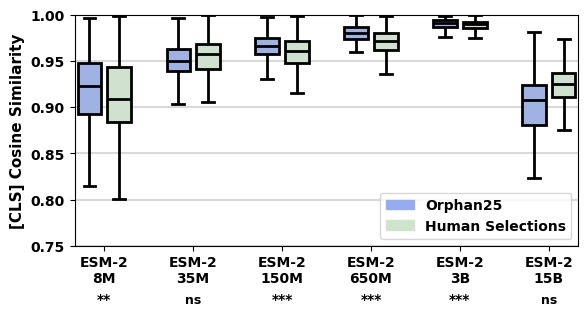

In [114]:
fig, ax = plt.subplots(figsize = (6.5,3))

data = []
x = []
my_pal = []
x_ticklabels = []
p_strings = []
stars = []

for i, m in enumerate(models_in_question):
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(model_to_cls_orphan_human[m]["orphan"])
    data.append(model_to_cls_orphan_human[m]["human"])
    data.append([])
    my_pal.append("#95acef")
    my_pal.append("#cce5cc")
    my_pal.append("white")
    x_ticklabels.append(model_to_base_string[m] + "\n" + model_to_params_string[m])
    
    _, p = scipy.stats.mannwhitneyu(
        model_to_cls_orphan_human[m]["orphan"],
        model_to_cls_orphan_human[m]["human"],
        alternative = "greater"
    )
    print(m, format_p(p))
    p_strings.append(r"$p = " + format_p(p) + "$")
    stars.append(p_val_to_stars(p))
    
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)


x_ticks = np.arange(0.5, (6*3) + 0.001, 3)



ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 10, fontweight = "bold")
ax.set_ylim(top=1.05)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

ax.set_ylim(top = 1.0)

for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)


######################################################

## use this for the full p-val strings 
# for xpos, text in zip(x_ticks, p_strings):
#     ax.text(xpos, -0.06, text, horizontalalignment = "center", fontsize = 7)

## use this for the stars
for xpos, text in zip(x_ticks, stars):
    fs = 10
    if text == "ns":
        fs = 9
    ax.text(xpos, 0.688, text, horizontalalignment = "center", fontsize = fs, fontweight = "bold")
    
######################################################
ax.set_ylabel("[CLS] Cosine Similarity", fontsize = 11, fontweight = "bold")
    
blue_patch = mpatches.Patch(color="#95acef", label='Orphan25')
green_patch = mpatches.Patch(color="#cce5cc", label='Human Selections')


ax.legend(handles=[blue_patch,green_patch], loc = "lower right",  prop = {"weight" : "bold", "size" : 10})

save_figure(fig, "CLS_pool_boxplots_orphan_v_human")

In [115]:
# fig, axes = plt.subplots(3,2, figsize = (12,9))
# axes = axes.ravel()

model_to_column_wise_dists = {m : {} for m in models_in_question}

# fig.subplots_adjust(hspace = 0.7, wspace = 0.3)

for i, m in enumerate(models_in_question):
#     ax = axes[i]
    
    
    orphan_embeddings = glob.glob(orphan_path + "embeddings/" + m +  "/*.pkl")
    non_orphan_embeddings = glob.glob(orphan_path + "non_orphan_embeddings/" + m +  "/*.pkl")

    orphan_pairs = get_all_pairs(orphan_embeddings)
    orphan_dists = []
    for pair in orphan_pairs:
        (p1,p2) = pair
        g1 = p1.replace("../../Orphan25/embeddings/" + m + "/", "").replace(".pkl", "")
        g2 = p2.replace("../../Orphan25/embeddings/" + m + "/", "").replace(".pkl", "")
        tmp = []
        emb_1 = depickle_obj(p1)[1:-1]
        emb_2 = depickle_obj(p2)[1:-1]
        for vec_1, vec_2 in zip(emb_1, emb_2):
            cs = cos_sim(vec_1, vec_2)
            orphan_dists.append(cs)
            tmp.append(str(round(cs, 5)))
            
        
        orphan_human_distance_tracker.append(["Orphan25", g1, g2, "Column Wise Dists", "|".join(tmp), m])

    non_orphan_pairs = get_all_pairs(non_orphan_embeddings)
    non_orphan_dists = []
    for pair in non_orphan_pairs:
        (p1,p2) = pair
        g1 = p1.replace("../../Orphan25/non_orphan_embeddings/" + m + "/", "").replace(".pkl", "")
        g2 = p2.replace("../../Orphan25/non_orphan_embeddings/" + m + "/", "").replace(".pkl", "")
        emb_1 = depickle_obj(p1)[1:-1]
        emb_2 = depickle_obj(p2)[1:-1]
        tmp  = []
        for vec_1, vec_2 in zip(emb_1, emb_2):
            cs = cos_sim(vec_1, vec_2)
            non_orphan_dists.append(cs)
            tmp.append(str(round(cs, 5)))
            
        orphan_human_distance_tracker.append(["Human Selections", g1, g2, "Column Wise Dists", "|".join(tmp), m])
        
    model_to_column_wise_dists[m]["orphan"] = orphan_dists
    model_to_column_wise_dists[m]["non_orphan"] = non_orphan_dists
            

esm_2_8M < 10^{-256}
esm_2_35M < 10^{-256}
esm_2_150M < 10^{-256}
esm_2_650M < 10^{-256}
esm_2 < 10^{-256}
esm_2_15B < 10^{-256}


/tmp/ipykernel_21302/3605052235.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


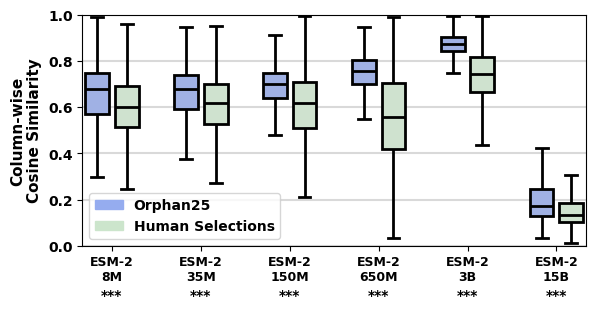

In [116]:
fig, ax = plt.subplots(figsize = (6.5,3))

data = []
x = []
my_pal = []
x_ticklabels = []
p_strings = []
stars = []

for i, m in enumerate(models_in_question):
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(model_to_column_wise_dists[m]["orphan"])
    data.append(model_to_column_wise_dists[m]["non_orphan"])
    data.append([])
    my_pal.append("#95acef")
    my_pal.append("#cce5cc")
    my_pal.append("white")
    x_ticklabels.append(model_to_base_string[m] + "\n" + model_to_params_string[m])
    
    _, p = scipy.stats.mannwhitneyu(
        model_to_column_wise_dists[m]["orphan"],
        model_to_column_wise_dists[m]["non_orphan"],
        alternative = "greater"
    )
    print(m, format_p(p))
    p_strings.append(r"$p = " + format_p(p) + "$")
    stars.append(p_val_to_stars(p))
    
# del my_pal[str((i*3) + 2)]
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)


x_ticks = np.arange(0.5, (6*3) + 0.001, 3)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 9, fontweight = "bold")

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(top = 1.0, bottom = 0 )

for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)

######################################################

## use this for the full p-val strings 
# for xpos, text in zip(x_ticks, p_strings):
#     ax.text(xpos, -0.06, text, horizontalalignment = "center", fontsize = 7)

## use this for the stars
for xpos, text in zip(x_ticks, stars):
    ax.text(xpos, -0.23, text, horizontalalignment = "center", fontsize = 10, fontweight = "bold")
    
######################################################
ax.set_ylabel("Column-wise\nCosine Similarity", fontweight = "bold", fontsize = 11)
    
blue_patch = mpatches.Patch(color="#95acef", label='Orphan25')
green_patch = mpatches.Patch(color="#cce5cc", label='Human Selections')


    
ax.legend(handles=[blue_patch,green_patch], loc = "lower left", prop = {"weight" : "bold", "size" : 10})

save_figure(fig, "column_wise_boxplots_orphan_v_human")

In [117]:
### make tables 
orphan_human_distance_tracker_df = pd.DataFrame(orphan_human_distance_tracker, columns = ["category", "protein1", "protein2", "similarity method", "distance", "model"])
orphan_human_distance_tracker_df["model"] = orphan_human_distance_tracker_df["model"].map(lambda x :model_to_display_str[x] )
orphan_human_distance_tracker_df.to_csv(supp_table_path + "orphan_25_human_pair_distances.csv")

print(orphan_human_distance_tracker_df["similarity method"].value_counts())

orphan_human_distance_tracker_df

similarity method
Mean Pool            3600
CLS pool             3600
Column Wise Dists    3600
Name: count, dtype: int64


,category,protein1,protein2,similarity method,distance,model
0,Orphan25,7AL0_A,7AD7_C,Mean Pool,0.75318,ESM-2 (8M)
1,Orphan25,7AL0_A,7COY_bI,Mean Pool,0.7959,ESM-2 (8M)
2,Orphan25,7AL0_A,7N50_A,Mean Pool,0.822168,ESM-2 (8M)
3,Orphan25,7AL0_A,6XYH_A,Mean Pool,0.818485,ESM-2 (8M)
4,Orphan25,7AL0_A,7JJV_B,Mean Pool,0.68633,ESM-2 (8M)
...,...,...,...,...,...,...
10795,Human Selections,P02795,P26678,Column Wise Dists,0.24408|0.12674|0.13565|0.10231|0.0914|0.0948|...,ESM-2 (15B)
10796,Human Selections,P02795,P56381,Column Wise Dists,0.33056|0.23679|0.19148|0.16778|0.22627|0.1856...,ESM-2 (15B)
10797,Human Selections,P47944,P26678,Column Wise Dists,0.29224|0.20393|0.20037|0.15504|0.15943|0.1429...,ESM-2 (15B)
10798,Human Selections,P47944,P56381,Column Wise Dists,0.33569|0.24927|0.19059|0.19456|0.15266|0.1742...,ESM-2 (15B)


## SCOPe data 

In [118]:
homstrad_path = home_path + "singh/nlp_review/remote_homology/"

df = pd.read_csv(homstrad_path + "all_romote_homologs_seqeunces.csv")

homolog_results = pd.read_csv(
    homstrad_path + "./high_quality_homolog_counts/SCOPe_proteins_UR50_hits_pct_identity_0.0_gap_pct_0.75_aln_frac_0.75.csv",
    index_col = 0
)

id_to_homologs = dict(zip(homolog_results["exp"].values, homolog_results["success"].values))

model_info = pd.read_csv(homstrad_path + "../notebooks/final_notebooks/model_info.txt", delimiter = "\t")
display_names = dict(zip(model_info["model_string"], model_info["display_name"]))

In [119]:
import random 

random_state = 2025
random.seed(random_state)

homstrad_path = home_path + "singh/nlp_review/remote_homology/"

model_to_case_df = {}

model_of_choice = "esm_2_8M"

df = pd.read_csv(homstrad_path + "all_romote_homologs_seqeunces.csv")

cos_sim_list = []
num_homologs_list = []
seq_sim = []

main_group = "fold_label"
alt_group = "family_label"

case_results = []

# getting initial results - selecting random sequences 
for i, sub_df in df.groupby(main_group):
    if len(sub_df) >= 2 :
        unique_groups = set(sub_df[alt_group].values)
        
        if len(unique_groups) == 1:
            continue 
            
        alt_group_1 = random.choices(list(unique_groups),k=1)[0]
        sub_df_1 = sub_df.loc[sub_df[alt_group] == alt_group_1] # randomly chosen e.g. superfamily 
        sub_df_2 = sub_df.loc[sub_df[alt_group] != alt_group_1] # must be different superfamily 
        
        sub_df_1 = sub_df_1.sample(frac=1, random_state = random_state) # shuffle rows 
        sub_df_2 = sub_df_2.sample(frac=1, random_state = random_state) # shuffle rows
        
        try:
            g1, g2 = sub_df_1.iloc[0]["id"], sub_df_2.iloc[0]["id"]
            seq1, seq2 = sub_df_1.iloc[0]["primary"], sub_df_2.iloc[0]["primary"]
            cos_sim_score = get_cosine_similarity_from_ids_homstrad(
                g1, 
                g2, 
                source_path= homstrad_path + "./embedding_extractions/" + model_of_choice + "/" 
            )
            cos_sim_list.append(cos_sim_score)
            num_homologs_list.append(min(id_to_homologs[g1], id_to_homologs[g2]))
            score, aligned_frac = get_aligned_fraction(seq1, seq2, return_score = True)
            score = score / min(len(seq1), len(seq2))
            seq_sim.append(score)
            
            alt_group_g1 = sub_df_1.iloc[0][alt_group]
            alt_group_g2 = sub_df_2.iloc[0][alt_group]
            
            main_group_g1 = sub_df_1.iloc[0][main_group]
            main_group_g2 = sub_df_2.iloc[0][main_group]
            
            case_results.append([
                main_group, 
                main_group_g1,
                main_group_g2,
                alt_group,
                alt_group_g1,
                alt_group_g2,
                g1, 
                g2, 
                cos_sim_score, 
                score, 
                id_to_homologs[g1], 
                id_to_homologs[g2],
            ])
                                
        except:

            continue # some do not have embeddings, i.e. length can't be accomodated  
            
            
columns = [
    "main_group", "main_group_g1", "main_group_g2", "alt_group", "alt_group_g1", "alt_group_g2",
    "g1", "g2", "cos_sim", "aln_score", "homologs_g1", "homologs_g2"
]
case_df = pd.DataFrame(case_results, columns = columns)
          
    
model_to_case_df[model_of_choice] = case_df



# getting the cos sims from other models 

print("selections finished")

needed_models = ["esm_2_35M","esm_2_150M","esm_2_650M","esm_2", "esm_2_15B"]
for model_of_interest in needed_models:
    print("getting", model_of_interest)
    new_cos_sims = []
    base_case_df = copy.deepcopy(case_df)
    for index, row in base_case_df.iterrows():
        g1 = row["g1"]
        g2 = row["g2"]
        cos_sim_score = get_cosine_similarity_from_ids_homstrad(
            g1, 
            g2, 
            source_path= homstrad_path + "./embedding_extractions/" + model_of_interest + "/" 
        )
        new_cos_sims.append(cos_sim_score)
    
    base_case_df["cos_sim"] = new_cos_sims
    model_to_case_df[model_of_interest] = base_case_df
        

selections finished
getting esm_2_35M
getting esm_2_150M
getting esm_2_650M
getting esm_2
getting esm_2_15B


In [120]:
print(len(base_case_df))

417


In [121]:
random.seed(random_state)

cos_sim_list_control = []
cos_sim_list_control_CLS = []
num_homologs_list_control = []
seq_sim_control = []

model_to_control_df = {}

control_results = []

# creating control groups - things in differnt folds 

for i, sub_df in df.groupby(main_group):
    
    alt_df = df.loc[df[main_group] != i]
        
    sub_df = sub_df.sample(frac = 1, random_state = random_state)
    alt_df = alt_df.drop_duplicates(subset = main_group) # assures uniform sampling from folds, some folds have many more proteins than others 
    alt_df = alt_df.sample(frac = 1, random_state = i) # can't shuffle the same each time, would be choosing the same one over and over 
    try:
    
        g1, g2 = sub_df.iloc[0]["id"], alt_df.iloc[0]["id"]
        
        seq1, seq2 = sub_df.iloc[0]["primary"], alt_df.iloc[0]["primary"]
        cos_sim_score = get_cosine_similarity_from_ids_homstrad(
            g1, 
            g2, 
            source_path= homstrad_path + "./embedding_extractions/" + model_of_choice + "/" 
        )
        
        cos_sim_list.append(cos_sim_score)
        
        cos_sim_score_CLS = get_cosine_similarity_from_ids_homstrad(
            g1, 
            g2, 
            source_path= homstrad_path + "./embedding_extractions/" + model_of_choice + "/" ,
            mean_reduce=False # cos_sim for CLS
        )
        
        cos_sim_list_control_CLS.append(cos_sim_score_CLS)
        
        
        num_homologs_list.append(min(id_to_homologs[g1], id_to_homologs[g2]))
        score, aligned_frac = get_aligned_fraction(seq1, seq2, return_score = True)
        score = score / min(len(seq1), len(seq2))
        seq_sim.append(score)
        
        
        alt_group_g1 = sub_df.iloc[0][alt_group]
        alt_group_g2 = alt_df.iloc[0][alt_group]

        main_group_g1 = sub_df.iloc[0][main_group]
        main_group_g2 = alt_df.iloc[0][main_group]

        
        control_results.append([
            main_group, 
            main_group_g1,
            main_group_g2,
            alt_group,
            alt_group_g1,
            alt_group_g2,
            g1, 
            g2, 
            cos_sim_score,
            cos_sim_score_CLS,
            score, 
            id_to_homologs[g1], 
            id_to_homologs[g2],
        ])
        
    except:
        continue 


columns = [
    "main_group", "main_group_g1", "main_group_g2", "alt_group", "alt_group_g1", "alt_group_g2",
    "g1", "g2", "cos_sim", "cos_sim_CLS", "aln_score", "homologs_g1", "homologs_g2"
]
control_df = pd.DataFrame(control_results, columns = columns)
    
model_to_control_df[model_of_choice] = control_df

# getting the cos sims from other models 

print("selections finished")

needed_models = ["esm_2_35M","esm_2_150M","esm_2_650M","esm_2", "esm_2_15B"]
for model_of_interest in needed_models:
    print("getting", model_of_interest)
    new_cos_sims = []
    new_cos_sims_CLS = []
    base_control_df = copy.deepcopy(control_df)
    for index, row in base_control_df.iterrows():
        g1 = row["g1"]
        g2 = row["g2"]
        cos_sim_score = get_cosine_similarity_from_ids_homstrad(
            g1, 
            g2, 
            source_path= homstrad_path + "./embedding_extractions/" + model_of_interest + "/" 
        )
        new_cos_sims.append(cos_sim_score)
        
        cos_sim_score_CLS = get_cosine_similarity_from_ids_homstrad(
            g1, 
            g2, 
            source_path= homstrad_path + "./embedding_extractions/" + model_of_interest + "/",
            mean_reduce = False
        )
        new_cos_sims_CLS.append(cos_sim_score_CLS)
    
    base_control_df["cos_sim"] = new_cos_sims
    base_control_df["cos_sim_CLS"] = new_cos_sims_CLS
    model_to_control_df[model_of_interest] = base_control_df

selections finished
getting esm_2_35M
getting esm_2_150M
getting esm_2_650M
getting esm_2
getting esm_2_15B


1189
62
4.144501451540822e-19
1189
62
8.31592822826238e-27
1189
62
9.192270131589559e-23
1189
62
5.696005256724333e-25
1189
62
4.813983923757184e-20
1189
62
3.120706508299867e-05


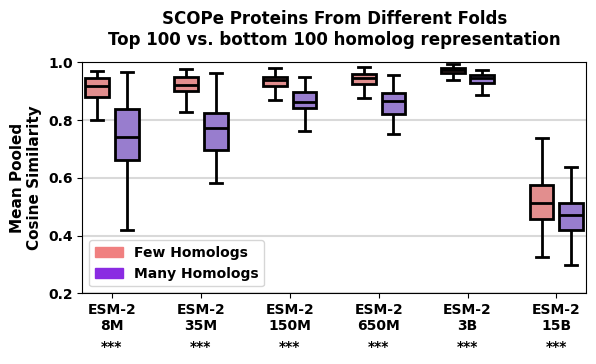

In [122]:
fig, ax = plt.subplots(figsize = (6.5, 3))

limit_1 = 100

data = []
x = []
my_pal = []
p_strings = []
stars = []

model_to_control_df_output_mean_pool = {}

for i, m in enumerate(models_in_question):
    
    control_df =  model_to_control_df[m]
    case_df = model_to_case_df[m]
    
    control_df["max_homologs"] = control_df[["homologs_g1", "homologs_g2"]].max(axis = 1)
    
    control_df = control_df.sort_values(by = "max_homologs") # Ascending order 
    
    
    
    
    print(len(control_df))
    cdf1 = control_df.head(limit_1)
    
    cdf2 = control_df.tail(limit_1)
    
    annotations = ["bottom_100"]*100 + ["N/A"]*(len(control_df) - 200) + ["top_100"]*100
    
    control_df["group_annotation"] = annotations
    
    model_to_control_df_output_mean_pool[m] = control_df
    
    print(np.max(cdf1["max_homologs"]))

    d1 = cdf1["cos_sim"].values
    d2 = cdf2["cos_sim"].values

    stat, p = scipy.stats.ks_2samp(cdf1["cos_sim"], cdf2["cos_sim"])
    
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(d1)
    data.append(d2)
    data.append([])
    my_pal.append("lightcoral")
    my_pal.append("mediumpurple")
    my_pal.append("white")
    
    _, p = scipy.stats.mannwhitneyu(d1,d2,alternative = "greater")
    print(p)
    p_str = format_p(p)
    if "<" not in p_str:
        p_str = "=" + p_str
    p_strings.append(r"$p " + p_str + "$")
    stars.append(p_val_to_stars(p))
    
    
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)




x_ticks = np.arange(0.5, (6*3) + 0.001, 3)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 10, fontweight = "bold")


ax.set_yticks([0.2,0.4,0.6,0.8,1.0])

ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(top = 1.0)

for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)


######################################################

## use this for the full p-val strings 
# for xpos, text in zip(x_ticks, p_strings):
#     ax.text(xpos, -0.06, text, horizontalalignment = "center", fontsize = 7)

## use this for the stars
for xpos, text in zip(x_ticks, stars):
    ax.text(xpos, -0.0, text, horizontalalignment = "center", fontsize = 10, fontweight = "bold")
    
######################################################
    
ax.set_ylabel("Mean Pooled\nCosine Similarity", fontsize = 11, fontweight = "bold")

coral_patch = mpatches.Patch(color="lightcoral", label='Few Homologs')
purple_patch = mpatches.Patch(color="blueviolet", label='Many Homologs')

ax.legend(handles=[coral_patch,purple_patch], loc = "lower left", prop = {"weight" : "bold", "size" : 10},)
ax.set_title(f"SCOPe Proteins From Different Folds\nTop {limit_1} vs. bottom {limit_1} homolog representation", y =1.04, fontweight = "bold")

ax.set_yticks(ax.get_yticks())
ax.set_ylim(top = 1.0) 


save_figure(fig, "mean_pool_boxplots_SCOPe_many_few")

In [123]:
limit_1 = 100

model_to_column_wise_scope = {}
model_to_cls_scope = {}

model_to_control_df_all_cos_sim_vals = {}

for i, m in enumerate(models_in_question):
    print(m)

    control_df =  model_to_control_df[m]

    control_df["max_homologs"] = control_df[["homologs_g1", "homologs_g2"]].max(axis = 1)
    
    

    control_df = control_df.sort_values(by = "max_homologs") # Ascending order 
    
    cos_sim_vals_cls = []
    cos_sim_vals_column_wise = []
    
    for index, row in control_df.iterrows():
        v1 = depickle_obj(homstrad_path + "./embedding_extractions/" + m + "/"  + row["g1"] + ".pkl")
        v2 = depickle_obj(homstrad_path + "./embedding_extractions/" + m + "/"  + row["g2"] + ".pkl")
        cos_sim_vals_cls.append(cos_sim(v1[0], v2[0]))
            
        v1 = v1[1:-1]
        v2 = v2[1:-1]
        
        this_entry_column_wise = []
        for k1, k2 in zip(v1,v2):
            this_entry_column_wise.append(round(cos_sim(k1,k2), 5))
            
        cos_sim_vals_column_wise.append("|".join(list(map(lambda x : str(x), this_entry_column_wise))))
        
    control_df["cos_sim_cls"] = cos_sim_vals_cls
    control_df["cos_sim_column_wise"] = cos_sim_vals_column_wise
    model_to_control_df_all_cos_sim_vals[m] = control_df
    
    

esm_2_8M
esm_2_35M
esm_2_150M
esm_2_650M
esm_2
esm_2_15B


In [124]:
control_df

,main_group,main_group_g1,main_group_g2,alt_group,alt_group_g1,alt_group_g2,g1,g2,cos_sim,cos_sim_CLS,aln_score,homologs_g1,homologs_g2,max_homologs,cos_sim_cls,cos_sim_column_wise
191,fold_label,191,853,family_label,320,2819,d1uf2c1,d1fn9a_,0.850129,0.971221,0.419847,0,2,2,0.971221,0.69361|0.46922|0.44003|0.42495|0.38472|0.4206...
661,fold_label,666,212,family_label,2009,363,d1n7za_,d1xoua_,0.629966,0.914449,0.691176,4,2,4,0.914449,0.38494|0.22276|0.2288|0.23404|0.2423|0.24279|...
493,fold_label,495,516,family_label,1609,1633,d2joka1,d1gaka_,0.793261,0.964465,0.394161,5,4,5,0.964465,0.55879|0.40546|0.57295|0.41291|0.36148|0.3638...
596,fold_label,599,715,family_label,1764,2100,d2pv4a1,d1cq3a_,0.707650,0.942873,0.421429,6,4,6,0.942873,0.48134|0.24261|0.2669|0.27027|0.29639|0.26221...
349,fold_label,350,169,family_label,933,3853,d2i9fa1,d1ikpa3,0.876685,0.961498,0.527273,7,7,7,0.961498,0.77214|0.57125|0.70532|0.52834|0.71482|0.4508...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,fold_label,56,954,family_label,95,2979,d2hlca_,d2ghvc1,0.403669,0.831819,0.409836,24215,166,24215,0.831819,0.17148|0.12369|0.1146|0.10357|0.12089|0.11995...
168,fold_label,168,18,family_label,1050,387,d1ztwa1,d1h32a2,0.489740,0.858557,0.554545,37652,181,37652,0.858557,0.19572|0.09385|0.11329|0.1157|0.10148|0.05766...
1040,fold_label,1045,65,family_label,3206,3619,d1pg4a_,d1dcea2,0.470453,0.888152,0.752294,44676,24,44676,0.888152,0.28719|0.15734|0.12126|0.12575|0.13568|0.1342...
124,fold_label,124,1018,family_label,216,3055,d1gzka_,d1cmia_,0.545514,0.850813,0.588235,88410,1080,88410,0.850813,0.26457|0.16697|0.14558|0.15437|0.13284|0.1221...


1.4239918304585405e-14
2.961889267278365e-14
8.60815446841717e-12
2.3767196619531978e-09
5.554910685524252e-10
4.9702159006459875e-08


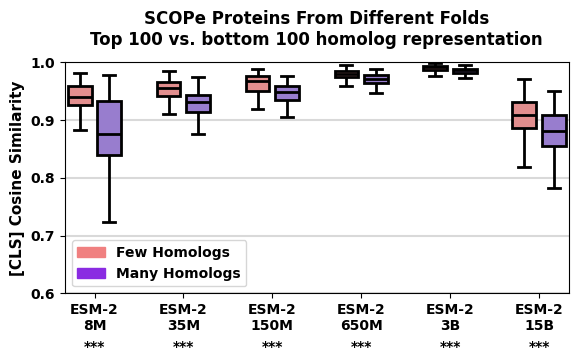

In [125]:
fig, ax = plt.subplots(figsize = (6.5, 3))

limit_1 = 100

data = []
x = []
my_pal = []
p_strings = []
stars = []

for m, control_df_full in model_to_control_df_all_cos_sim_vals.items():
    control_df_full["max_homologs"] = control_df_full[["homologs_g1", "homologs_g2"]].max(axis = 1)
    
    control_df_full = control_df_full.sort_values(by = "max_homologs") # Ascending order 
    
    cdf1 = control_df_full.head(limit_1)
    cdf2 = control_df_full.tail(limit_1)
    
    d1 = cdf1["cos_sim_cls"].values
    d2 = cdf2["cos_sim_cls"].values

    stat, p = scipy.stats.ks_2samp(cdf1["cos_sim"], cdf2["cos_sim"])
    
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(d1)
    data.append(d2)
    data.append([])
    
    my_pal.append("lightcoral")
    my_pal.append("mediumpurple")
    my_pal.append("white")
    
    _, p = scipy.stats.mannwhitneyu(d1,d2,alternative = "greater")
    print(p)
    p_str = format_p(p)
    if "<" not in p_str:
        p_str = "=" + p_str
    p_strings.append(r"$p " + p_str + "$")
    stars.append(p_val_to_stars(p))
    
    
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
#     color = "white", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)


x_ticks = np.arange(0.5, (6*3) + 0.001, 3)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 10, fontweight = "bold")

ax.set_yticks([0.6,0.7,0.8,0.9,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(top = 1.0)



for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)
    
ax.set_ylim(top = 1.0)
######################################################

## use this for the full p-val strings 
# for xpos, text in zip(x_ticks, p_strings):
#     ax.text(xpos, -0.06, text, horizontalalignment = "center", fontsize = 7)

## use this for the stars
for xpos, text in zip(x_ticks, stars):
    ax.text(xpos, 0.5, text, horizontalalignment = "center", fontsize = 10, fontweight = "bold")
    
######################################################
    
ax.set_ylabel("[CLS] Cosine Similarity", fontsize = 11, fontweight = "bold")

coral_patch = mpatches.Patch(color="lightcoral", label='Few Homologs')
purple_patch = mpatches.Patch(color="blueviolet", label='Many Homologs')

ax.legend(handles=[coral_patch,purple_patch], loc = "lower left", prop = {"weight" : "bold", "size" : 10})
ax.set_title(f"SCOPe Proteins From Different Folds\nTop {limit_1} vs. bottom {limit_1} homolog representation", y =1.04, fontweight = "bold")


save_figure(fig, "CLS_pool_boxplots_scope_many_few")

0.0
0.0
0.0
0.0
0.0
0.0


(-0.6, 1.01)

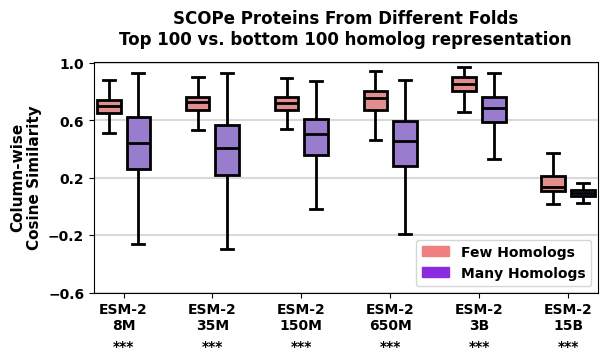

In [126]:
fig, ax = plt.subplots(figsize = (6.5, 3))

limit_1 = 100

data = []
x = []
my_pal = []
p_strings = []
stars = []

for m, control_df_full in model_to_control_df_all_cos_sim_vals.items():
    control_df_full["max_homologs"] = control_df_full[["homologs_g1", "homologs_g2"]].max(axis = 1)
    control_df_full = control_df_full.sort_values(by = "max_homologs") # Ascending order 
#     control_df["mean_homologs"] = control_df[["homologs_g1", "homologs_g2"]].mean(axis = 1)
    
#     control_df = control_df.sort_values(by = "mean_homologs") # Ascending order 
    
    cdf1 = control_df_full.head(limit_1)
    cdf2 = control_df_full.tail(limit_1)
    
    
    d1 = []
    d2 = []
    
    for i1, r1 in cdf1.iterrows():
        col_vals1 = list(map(lambda x : float(x), r1["cos_sim_column_wise"].split("|")))
        for cv1 in col_vals1:
            d1.append(cv1)
            
    for i2, r2 in cdf2.iterrows():
        col_vals2 = list(map(lambda x : float(x), r2["cos_sim_column_wise"].split("|")))
        for cv2 in col_vals2:
            d2.append(cv2)

    
    x = x + [i*3, (i*3) + 1, (i*3) + 2]
    data.append(d1)
    data.append(d2)
    data.append([])
    
    my_pal.append("lightcoral")
    my_pal.append("mediumpurple")
    my_pal.append("white")
    
    _, p = scipy.stats.mannwhitneyu(d1,d2,alternative = "greater")
    print(p)
    p_str = format_p(p)
    if "<" not in p_str:
        p_str = "=" + p_str
    p_strings.append(r"$p " + p_str + "$")
    stars.append(p_val_to_stars(p))
    
    
data = data[:-1]
x = x[:-1]
my_pal = my_pal[:-1]
    
sns.boxplot(
    data, 
#     color = "white", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal
)


x_ticks = np.arange(0.5, (6*3) + 0.001, 3)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize = 10, fontweight = "bold")
y_ticks = np.arange(-0.6,1.1,0.4)

ax.set_yticks(y_ticks)

ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(top=1.05)

for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15)
    
## use this for the stars
for xpos, text in zip(x_ticks, stars):
    ax.text(xpos, -1, text, horizontalalignment = "center", fontweight = "bold", fontsize = 10)
    
######################################################
    
ax.set_ylabel("Column-wise\nCosine Similarity", fontsize = 11, fontweight = "bold")

coral_patch = mpatches.Patch(color="lightcoral", label='Few Homologs')
purple_patch = mpatches.Patch(color="blueviolet", label='Many Homologs')

ax.legend(handles=[coral_patch,purple_patch], loc = "lower right",  prop = {"weight" : "bold", "size" : 10})
ax.set_title(f"SCOPe Proteins From Different Folds\nTop {limit_1} vs. bottom {limit_1} homolog representation", y =1.04, fontweight = "bold")

ax.set_ylim(top = 1.01)

# save_figure(fig, "columns_wise_boxplots_scope_many_few")

In [127]:
# make tables...
pieces = []

keeping = ["model", "main_group_g1", "main_group_g2", "g1", "g2", "homologs_g1", "homologs_g2", "cos_sim", "cos_sim_cls", "cos_sim_column_wise"]
for m, control_df_full in model_to_control_df_all_cos_sim_vals.items():
    control_df_full["model"] = model_to_display_str[m]
    control_df_full = control_df_full[keeping]
    control_df_full = control_df_full.rename(columns = {
        "main_group_g1" : "fold_protein_1",
        "main_group_g2" : "fold_protein_2",
        "g1" : "protein_1",
        "g2" : "protein_2",
        "homologs_g1": "homologs_protein_1",
        "homologs_g2": "homologs_protein_2",
        "cos_sim" : "cos_sim_mean_pool"
    })
    
    control_df_full["max_homologs"] = control_df_full[["homologs_protein_1", "homologs_protein_2"]].max(axis = 1)
    control_df_full = control_df_full.sort_values(by = "max_homologs") # Ascending order 
    
    
    annotations = ["bottom_100"]*100 + ["N/A"]*(len(control_df_full) - 200) + ["top_100"]*100
    control_df_full["group_annotation"] = annotations
    pieces.append(control_df_full)
    
top_bottom_homologs_scope_table = pd.concat(pieces)
top_bottom_homologs_scope_table.to_csv(supp_table_path + "top_bottom_homologs_pairs_scope_distances.csv", index = False)

In [128]:
top_bottom_homologs_scope_table

,model,fold_protein_1,fold_protein_2,protein_1,protein_2,homologs_protein_1,homologs_protein_2,cos_sim_mean_pool,cos_sim_cls,cos_sim_column_wise,max_homologs,group_annotation
191,ESM-2 (8M),191,853,d1uf2c1,d1fn9a_,0,2,0.954707,0.962375,0.90674|0.74557|0.78409|0.80236|0.76416|0.8274...,2,bottom_100
661,ESM-2 (8M),666,212,d1n7za_,d1xoua_,4,2,0.893808,0.950547,0.78971|0.75847|0.7237|0.74351|0.71947|0.75998...,4,bottom_100
493,ESM-2 (8M),495,516,d2joka1,d1gaka_,5,4,0.909830,0.952530,0.76411|0.71319|0.8481|0.7261|0.77043|0.71813|...,5,bottom_100
596,ESM-2 (8M),599,715,d2pv4a1,d1cq3a_,6,4,0.871278,0.883197,0.73793|0.56766|0.54217|0.50702|0.54972|0.5358...,6,bottom_100
349,ESM-2 (8M),350,169,d2i9fa1,d1ikpa3,7,7,0.948067,0.932761,0.89575|0.77331|0.90553|0.78858|0.91214|0.7489...,7,bottom_100
...,...,...,...,...,...,...,...,...,...,...,...,...
56,ESM-2 (15B),56,954,d2hlca_,d2ghvc1,24215,166,0.403669,0.831819,0.17148|0.12369|0.1146|0.10357|0.12089|0.11995...,24215,top_100
168,ESM-2 (15B),168,18,d1ztwa1,d1h32a2,37652,181,0.489740,0.858557,0.19572|0.09385|0.11329|0.1157|0.10148|0.05766...,37652,top_100
1040,ESM-2 (15B),1045,65,d1pg4a_,d1dcea2,44676,24,0.470453,0.888152,0.28719|0.15734|0.12126|0.12575|0.13568|0.1342...,44676,top_100
124,ESM-2 (15B),124,1018,d1gzka_,d1cmia_,88410,1080,0.545514,0.850813,0.26457|0.16697|0.14558|0.15437|0.13284|0.1221...,88410,top_100


In [129]:
model_in_q = "esm_2_35M"

orphan_embeddings = glob.glob(orphan_path + "embeddings/" + model_in_q +  "/*.pkl")

orphan_emb_list_mean_pooled = []
for p in orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ]
    emb = np.mean(emb, axis = 0 ) 
    orphan_emb_list_mean_pooled.append(emb)
    
joined_orphan = np.asarray(orphan_emb_list_mean_pooled).T
orphan_embedding_position_to_median = {}
for i, arr in enumerate(joined_orphan):
    orphan_embedding_position_to_median[i] = np.median(arr)
    
    
non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
non_orphan_emb_list_mean_pooled = []

for p in non_orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ]
    emb = np.mean(emb, axis = 0 ) 
    non_orphan_emb_list_mean_pooled.append(emb)   
    
joined_non_orphan = np.asarray(non_orphan_emb_list_mean_pooled).T
non_orphan_embedding_position_to_median = {}
for i, arr in enumerate(joined_non_orphan):
    non_orphan_embedding_position_to_median[i] = np.median(arr)

x1 = []
x2 = []
pos = []
for k in range(np.max(list(non_orphan_embedding_position_to_median.keys()))):
    pos.append(k)
    x1.append(non_orphan_embedding_position_to_median[k])
    x2.append(orphan_embedding_position_to_median[k])
    
dfo = pd.DataFrame.from_dict({
    "vector_position" : pos,
    "non_orphan_median": x1, 
    "orphan_median" : x2
})

In [130]:
model_to_dfo = {}

for i, model_in_q in enumerate(models_in_question):
    

    orphan_embeddings = glob.glob(orphan_path + "embeddings/" + model_in_q +  "/*.pkl")

    orphan_emb_list_mean_pooled = []
    for p in orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        emb = np.mean(emb, axis = 0 ) 
        orphan_emb_list_mean_pooled.append(emb)

    joined_orphan = np.asarray(orphan_emb_list_mean_pooled).T
    orphan_embedding_position_to_median = {}
    for i, arr in enumerate(joined_orphan):
        orphan_embedding_position_to_median[i] = np.median(arr)


    non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
    non_orphan_emb_list_mean_pooled = []

    for p in non_orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        emb = np.mean(emb, axis = 0 ) 
        non_orphan_emb_list_mean_pooled.append(emb)   

    joined_non_orphan = np.asarray(non_orphan_emb_list_mean_pooled).T
    non_orphan_embedding_position_to_median = {}
    for i, arr in enumerate(joined_non_orphan):
        non_orphan_embedding_position_to_median[i] = np.median(arr)

    x1 = []
    x2 = []
    pos = []
    for k in range(np.max(list(non_orphan_embedding_position_to_median.keys()))):
        pos.append(k)
        x1.append(non_orphan_embedding_position_to_median[k])
        x2.append(orphan_embedding_position_to_median[k])

    dfo = pd.DataFrame.from_dict({
        "vector_position" : pos,
        "non_orphan_median": x1, 
        "orphan_median" : x2
    })
    
    model_to_dfo[model_in_q] = dfo
    


In [131]:
intra_group_distance_pairs = []

In [132]:
# model_in_q = "esm_2"

for model_in_q in models_in_question:
    randseq_embedding_path = home_path + "singh/nlp_review/Orphan25/randseq_embeddings/"
    randseq_embedding_files = glob.glob(randseq_embedding_path + model_in_q + "/*.pkl")

    randseq_to_embedding_mean_pool = {}

    for p in randseq_embedding_files:
        n = p.split("/")[-1].replace(".pkl", "")
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        emb = np.mean(emb, axis = 0 ) 
        randseq_to_embedding_mean_pool[n] = emb

    randseq_pairs = get_all_pairs(list(randseq_to_embedding_mean_pool.keys()))

    cos_sim_list = []
    for rs_p in randseq_pairs:
        p1,p2 = rs_p
        v1 = randseq_to_embedding_mean_pool[p1]
        v2 = randseq_to_embedding_mean_pool[p2]
        cs = cos_sim(v1,v2)
        cos_sim_list.append(cs)
        
        intra_group_distance_pairs.append(["RandSeq", model_in_q, p1, p2, cs])

    model_to_dists[model_in_q]["randseq"] = cos_sim_list

In [133]:


for window_size in range(1,17):
    
    for model_in_q in models_in_question:
        markov_embedding_path = home_path + "singh/nlp_review/Orphan25/markov_based_embeddings/"
        markov_embedding_files = glob.glob(markov_embedding_path + model_in_q + f"/window_size_{window_size}"  + "/*.pkl")

        markov_to_embedding_mean_pool = {}

        for p in markov_embedding_files:
            n = p.split("/")[-1].replace(".pkl", "")
            emb = depickle_obj(p)
            emb = emb[1:-1, ]
            emb = np.mean(emb, axis = 0) 
            markov_to_embedding_mean_pool[n] = emb

        markov_pairs = get_all_pairs(list(markov_to_embedding_mean_pool.keys()))

        cos_sim_list = []
        for rs_p in markov_pairs:
            p1,p2 = rs_p
            v1 = markov_to_embedding_mean_pool[p1]
            v2 = markov_to_embedding_mean_pool[p2]
            cs = cos_sim(v1,v2)
            cos_sim_list.append(cs)
            intra_group_distance_pairs.append(["markov_window_" + str(window_size), model_in_q, p1, p2, cs])

        model_to_dists[model_in_q][f"markov_window_{window_size}"] = cos_sim_list

In [134]:
# making table
intra_dist_df = pd.DataFrame(intra_group_distance_pairs, columns = ["sequence_group", "model", "protein_1", "protein_2", "mean_pool_cosine_sim"])
intra_dist_df["model"] = intra_dist_df["model"].apply(lambda x : model_to_display_str[x])
intra_dist_df.to_csv(supp_table_path + "random_seq_intra_group_mean_pool_dists.csv", index = False)


In [135]:
for model_in_q in models_in_question:
    randseq_embedding_path = "/Genomics/argo/users/jf9645/singh/nlp_review/Orphan25/randseq_embeddings/"
    randseq_embedding_files = glob.glob(randseq_embedding_path + model_in_q + "/*.pkl")

    randseq_to_embedding = {}

    for p in randseq_embedding_files:
        n = p.split("/")[-1].replace(".pkl", "")
        emb = depickle_obj(p)
        emb = emb[1:-1,]
        randseq_to_embedding[n] = emb

    randseq_pairs = get_all_pairs(list(randseq_to_embedding_mean_pool.keys()))
    column_wise_cos_sim_list = []
    for rs_p in randseq_pairs:
        p1, p2 = rs_p
        v1 = randseq_to_embedding[p1]
        v2 = randseq_to_embedding[p2]
        
        for k1, k2 in zip(v1,v2):
            column_wise_cos_sim_list.append(cos_sim(k1, k2))
        
        
    model_to_column_wise_dists[model_in_q]["randseq"] = column_wise_cos_sim_list

In [136]:

##################

model_to_emb_pos_to_variance_list = {}

for model_in_q in models_in_question:
   
    orphan_embeddings = glob.glob( orphan_path + "./embeddings/" + model_in_q + "/*.pkl")
    orphan_emb_list = []

    for p in orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        orphan_emb_list.append(emb) 

    non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
    non_orphan_emb_list = []

    for p in non_orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ] 
        non_orphan_emb_list.append(emb)   


    emb_pos_to_variance_list = {"orphan" : {}, "non_orphan" : {}}

    for k in orphan_emb_list:
        for i, vec in enumerate(k.T):
            c = np.var(vec)
            if i in emb_pos_to_variance_list["orphan"].keys():
                emb_pos_to_variance_list["orphan"][i].append(c)
            else:
                emb_pos_to_variance_list["orphan"][i] = [c]

    for k in non_orphan_emb_list:
        for i, vec in enumerate(k.T):
            c = np.var(vec)
            if i in emb_pos_to_variance_list["non_orphan"].keys():
                emb_pos_to_variance_list["non_orphan"][i].append(c)
            else:
                emb_pos_to_variance_list["non_orphan"][i] = [c]
                
    model_to_emb_pos_to_variance_list[model_in_q] = emb_pos_to_variance_list





In [137]:
import matplotlib.patches as patches

In [138]:
embedding_dimension_table_tracker_orphan_human = []

12
320 320 proportion non-orphan higher :  0.925
480 480 proportion non-orphan higher :  0.9604166666666667
640 640 proportion non-orphan higher :  0.9171875
1280 1280 proportion non-orphan higher :  0.9953125
2560 2560 proportion non-orphan higher :  1.0
5120 5120 proportion non-orphan higher :  0.846484375


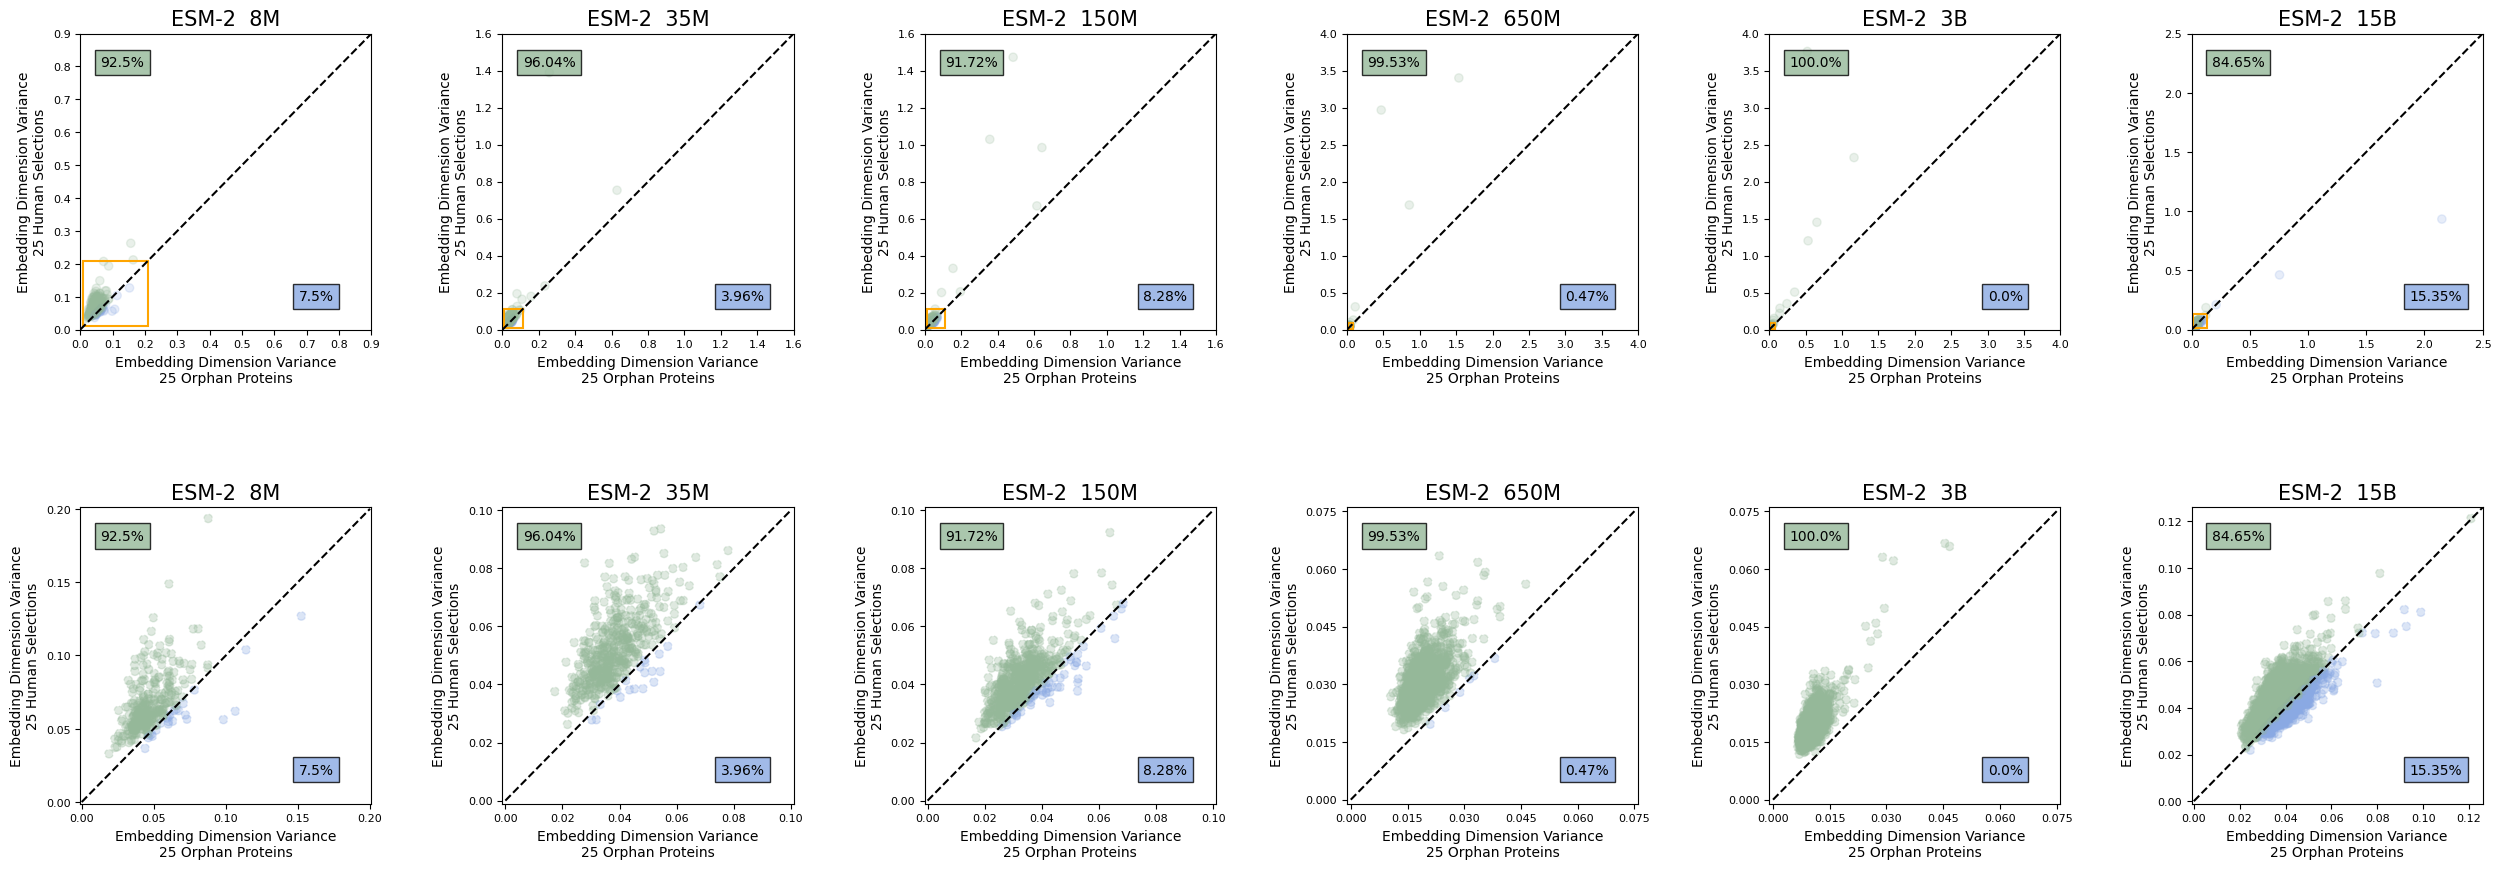

In [139]:
fig, axes = plt.subplots(2, 6, figsize = (31,10))
axes = axes.ravel()

print(len(axes))
fig.subplots_adjust(hspace = 0.6, wspace = 0.45)

# below_color = "slateblue"
# above_color = "forestgreen"


below_color = "#8aa9e3"
above_color = "#95b899"

model_to_inset_pos = {
    "esm_2_8M" : 0.2,
    "esm_2_35M" : 0.1,
    "esm_2_150M" : 0.1,
    "esm_2_650M" : 0.075,
    "esm_2" : 0.075,
    "esm_2_15B" : 0.125,
    
}

model_to_inset_ticks = {
    "esm_2_8M" : np.arange(0, 0.2 + 0.001, 0.05),
    "esm_2_35M" : np.arange(0, 0.1 + 0.001, 0.02),
    "esm_2_150M" : np.arange(0, 0.1 + 0.001, 0.02),
    "esm_2_650M" : np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2" :np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2_15B" : np.arange(0, 0.14 + 0.001, 0.02)
}

orphan25_model_to_dimension_summary_stats = {}

for ax_i, model_in_q in enumerate(models_in_question):
   
    orphan_embeddings = glob.glob( orphan_path + "./embeddings/" + model_in_q + "/*.pkl")
    orphan_emb_list = []

    for p in orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        orphan_emb_list.append(emb) 

    non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
    non_orphan_emb_list = []

    for p in non_orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ] 
        non_orphan_emb_list.append(emb) 
        
    joined_embeddings_orphan = np.concatenate(orphan_emb_list)
    joined_embeddings_non_orphan = np.concatenate(non_orphan_emb_list)
    
    x = []
    y = []
    color_list_full = []
    
    inset_xlim = model_to_inset_pos[model_in_q]
    inset_ylim = model_to_inset_pos[model_in_q]

    inset_x = []
    inset_y = []
    color_list_inset = []

    above_line = 0
    below_line = 0 
    
    
    for i in range(np.shape(joined_embeddings_orphan)[1]):
        arr_1 = joined_embeddings_orphan[:, i]
        arr_2 = joined_embeddings_non_orphan[:, i]
        v1 = np.var(arr_1)
        v2 = np.var(arr_2)
        
        embedding_dimension_table_tracker_orphan_human.append(["Orphan25", model_in_q, i, v1])
        embedding_dimension_table_tracker_orphan_human.append(["Human Selections", model_in_q, i, v2])
        
        if v2 > v1:
            above_line += 1
            color_list_full.append(above_color)
        else:
            below_line += 1
            color_list_full.append(below_color)
            
        x.append(v1)
        y.append(v2)
        
        if v1 < inset_xlim and v2 < inset_ylim:
            inset_x.append(v1)
            inset_y.append(v2)
            if v2 > v1:
                color_list_inset.append(above_color)
            else:
                
                color_list_inset.append(below_color)
            
        
    print(len(x), len(y), "proportion non-orphan higher : ", above_line/len(x) )
        
    ax1 = axes[ax_i]
    ax2 = axes[ax_i + 6]
    
    ax = ax1
    ax.scatter(x,y, alpha = 0.2, c = color_list_full)
    
    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        
    ax.set_xticks(max_ticks)
    ax.set_yticks(max_ticks)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 8)
        
    x1 = np.linspace(0, np.max(max_ticks), 100)
    ax.plot(x1,x1, linestyle = "--", color = "black",)
    
    display_epsilon = 0.01
    rect = patches.Rectangle((0+display_epsilon, 0+display_epsilon), inset_xlim, inset_ylim, lw=1.5, edgecolor='orange', facecolor='none')
    ax.add_patch(rect)
    ax.set_xlim(left = 0, right = np.max(max_ticks) )
    ax.set_ylim(bottom = 0, top = np.max(max_ticks))
    
    
    pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
    pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"
    orphan25_model_to_dimension_summary_stats
    orphan25_model_to_dimension_summary_stats[model_in_q] = {"above" : pct_above, "below" : pct_below}
    
    ax.text(
        0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None)
    )

    ax.text(
        0.75,0.1,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None)
    )
    
    
    
    ax.set_ylabel("Embedding Dimension Variance\n25 Human Selections", fontsize = 10)
    ax.set_xlabel("Embedding Dimension Variance\n25 Orphan Proteins", fontsize = 10)
    
    ax.set_title(model_to_base_string[model_in_q] + "  " + model_to_params_string[model_in_q], fontsize = 15)
    
    ax = ax2 

    ax.scatter(inset_x, inset_y, linestyle = "--", alpha = 0.3, c = color_list_inset)

    ax.set_ylabel("Embedding Dimension Variance\n25 Human Selections", fontsize = 10)
    ax.set_xlabel("Embedding Dimension Variance\n25 Orphan Proteins", fontsize = 10)
    
    ax.set_title(model_to_base_string[model_in_q] + "  " + model_to_params_string[model_in_q], fontsize = 15)
    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        
#     inset_ticks = np.arange(0, inset_ylim + 0.001, 0.015)

    ax.set_xticks(model_to_inset_ticks[model_in_q])
    ax.set_yticks(model_to_inset_ticks[model_in_q])
    
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 8)
    ax.set_xlim(left = -0.01)
    ax.set_ylim(bottom = -0.01)
    x1 = np.linspace(0, np.max(model_to_inset_ticks[model_in_q]), 100)

    ax.plot(x1,x1, linestyle = "--", color = "black",  )
    ax.set_xlim(right = inset_xlim + 0.001, left = -0.001)
    ax.set_ylim(top = inset_xlim + 0.001, bottom = -0.001)
    

    ax.text(
        0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None)
    )

    ax.text(
        0.75,0.1,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None)
    )

    
save_figure(fig, f"esm_2_models_variance_human_vs_orphans_proteins_together")

320 320 proportion non-orphan higher :  0.925
480 480 proportion non-orphan higher :  0.9604166666666667
640 640 proportion non-orphan higher :  0.9171875
1280 1280 proportion non-orphan higher :  0.9953125
2560 2560 proportion non-orphan higher :  1.0


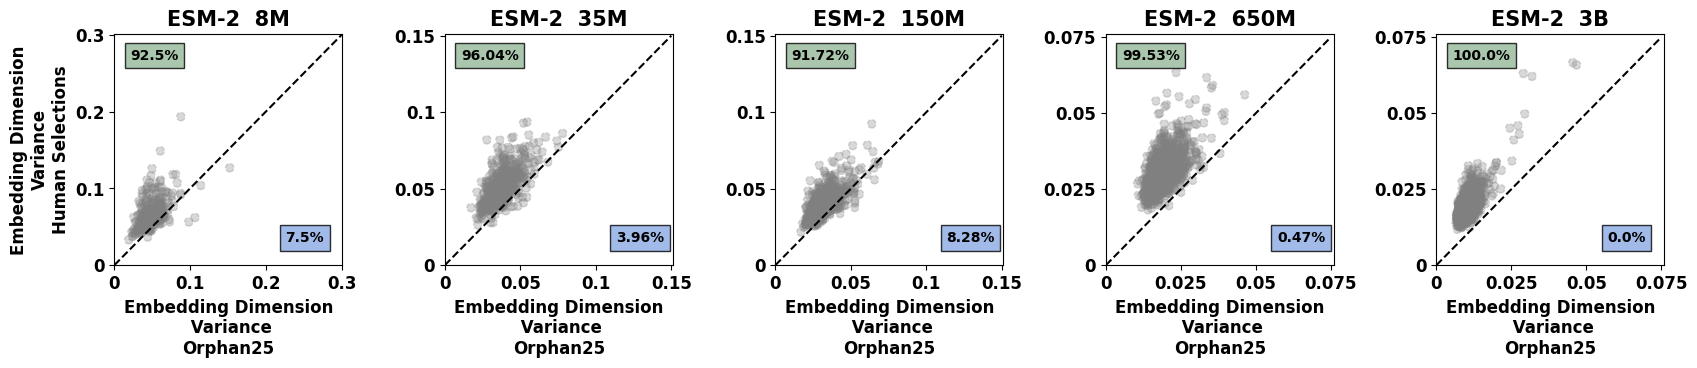

In [140]:
fig, axes = plt.subplots(1,5,figsize = (20,3))
fig.subplots_adjust(wspace = 0.45)


x_ticklist = [
    [0,0.1,0.2,0.3],
    [0,0.05,0.10,0.15],
    [0,0.05,0.10,0.15],
    [0,0.025,0.05,0.075],
    [0,0.025,0.05,0.075]
    
]

for ax_i, model_in_q in enumerate(models_in_question):
    
    if model_in_q == "esm_2_15B":
        continue 
   
    orphan_embeddings = glob.glob( orphan_path + "./embeddings/" + model_in_q + "/*.pkl")
    orphan_emb_list = []

    for p in orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ]
        orphan_emb_list.append(emb) 

    non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
    non_orphan_emb_list = []

    for p in non_orphan_embeddings:
        emb = depickle_obj(p)
        emb = emb[1:-1, ] 
        non_orphan_emb_list.append(emb) 
        
    joined_embeddings_orphan = np.concatenate(orphan_emb_list)
    joined_embeddings_non_orphan = np.concatenate(non_orphan_emb_list)
    
    x = []
    y = []
    color_list_full = []
    
    inset_xlim = model_to_inset_pos[model_in_q]
    inset_ylim = model_to_inset_pos[model_in_q]

    inset_x = []
    inset_y = []
    color_list_inset = []

    above_line = 0
    below_line = 0 
    
    
    for i in range(np.shape(joined_embeddings_orphan)[1]):
        arr_1 = joined_embeddings_orphan[:, i]
        arr_2 = joined_embeddings_non_orphan[:, i]
        v1 = np.var(arr_1)
        v2 = np.var(arr_2)
        
        embedding_dimension_table_tracker_orphan_human.append(["Orphan25", model_in_q, i, v1])
        embedding_dimension_table_tracker_orphan_human.append(["Human Selections", model_in_q, i, v2])
        
        if v2 > v1:
            above_line += 1
            color_list_full.append(above_color)
        else:
            below_line += 1
            color_list_full.append(below_color)
            
        x.append(v1)
        y.append(v2)
        
        if v1 < inset_xlim and v2 < inset_ylim:
            inset_x.append(v1)
            inset_y.append(v2)
            if v2 > v1:
                color_list_inset.append(above_color)
            else:
                
                color_list_inset.append(below_color)
            
        
    print(len(x), len(y), "proportion non-orphan higher : ", above_line/len(x) )
    
    pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
    pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"
    
    ax = axes[ax_i]
        
    ax.scatter(inset_x, inset_y, linestyle = "--", alpha = 0.3, c = "gray", zorder = 1)
    
    if model_in_q == "esm_2_8M":
        
        ax.set_ylabel("Embedding Dimension\nVariance\nHuman Selections", fontsize = 12, fontweight="bold")
    
    ax.set_xlabel("Embedding Dimension\n Variance\nOrphan25", fontsize = 12, fontweight="bold")
    
    ax.set_title(model_to_base_string[model_in_q] + "  " + model_to_params_string[model_in_q], fontsize = 15, fontweight="bold")
    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        

    ax.set_xticks(x_ticklist[ax_i])
    ax.set_yticks(x_ticklist[ax_i])
    
    
    ax.set_xticklabels(x_ticklist[ax_i], fontsize = 12, fontweight="bold")
    ax.set_yticklabels(x_ticklist[ax_i], fontsize = 12, fontweight="bold")
    ax.set_xlim(left = -0.01)
    ax.set_ylim(bottom = -0.01)
    x1 = np.linspace(0, np.max(x_ticklist[ax_i]), 100)

    ax.plot(x1,x1, linestyle = "--", color = "black",  )
    
    ax.set_xlim(right = np.max(x_ticklist[ax_i]) + 0.001, left = np.min(x_ticklist[ax_i]))
    ax.set_ylim(top = np.max(x_ticklist[ax_i]) + 0.001, bottom = np.min(x_ticklist[ax_i]))
    

    ax.text(
        0.07,0.89, pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None),
        fontweight = "bold"
    )

    ax.text(
        0.75,0.1,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None),
        fontweight = "bold"
    )



4334 5120


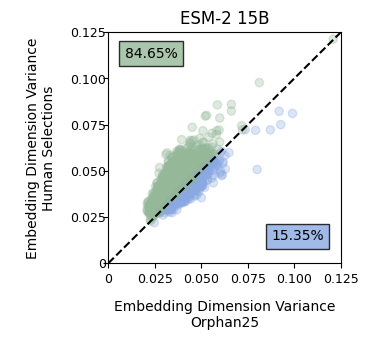

In [141]:
sns.set_style(None)

fig, ax = plt.subplots(figsize = (3,3))


below_color = "#8aa9e3"
above_color = "#95b899"

model_in_q = "esm_2_15B"

orphan_embeddings = glob.glob( orphan_path + "./embeddings/" + model_in_q + "/*.pkl")
orphan_emb_list = []

for p in orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ]
    orphan_emb_list.append(emb) 

non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
non_orphan_emb_list = []

for p in non_orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ] 
    non_orphan_emb_list.append(emb) 

joined_embeddings_orphan = np.concatenate(orphan_emb_list)
joined_embeddings_non_orphan = np.concatenate(non_orphan_emb_list)

x = []
y = []
color_list_full = []

inset_xlim = model_to_inset_pos[model_in_q]
inset_ylim = model_to_inset_pos[model_in_q]

inset_x = []
inset_y = []
color_list_inset = []

above_line = 0
below_line = 0 


for i in range(np.shape(joined_embeddings_orphan)[1]):
    arr_1 = joined_embeddings_orphan[:, i]
    arr_2 = joined_embeddings_non_orphan[:, i]
    v1 = np.var(arr_1)
    v2 = np.var(arr_2)
    if v2 > v1:
        above_line += 1
        color_list_full.append(above_color)
    else:
        below_line += 1
        color_list_full.append(below_color)

    x.append(v1)
    y.append(v2)
    
    
#     orphan_human_embedding_variance_tracker.append([""])
    
    if v1 < inset_xlim and v2 < inset_ylim:
        inset_x.append(v1)
        inset_y.append(v2)
        if v2 > v1:
            color_list_inset.append(above_color)
        else:
            color_list_inset.append(below_color)
            
ax.scatter(x,y, c=color_list_full, alpha = 0.3,zorder = 1)
ax.set_xlim(right = 0.125,left = 0)
ax.set_ylim(top = 0.125,bottom = 0)
x1 = np.linspace(0, 0.125, 100)
ax.plot(x1,x1,color = "black", linestyle = "--", zorder = 100)
ticks = [0,0.025,0.05,0.075,0.1,0.125]
ticklabels = ["0", "0.025", "0.050", "0.075", "0.100", "0.125"]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticklabels,rotation = 0, fontsize = 9)
ax.set_yticklabels(ticklabels, fontsize = 9)

for tick in ax.get_yaxis().get_major_ticks():
    tick.set_pad(-2.0)

pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"

ax.text(
    0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
    bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None)
)

ax.text(
    0.7,0.1,pct_below, transform = ax.transAxes, color = "black", 
    bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None)
)



ax.set_xlabel("Embedding Dimension Variance\nOrphan25",labelpad = 10, fontsize = 10)
ax.set_ylabel("\nEmbedding Dimension Variance\nHuman Selections", labelpad = 10, fontsize = 10)

ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q])

print(above_line, (above_line + below_line))

In [142]:
model_to_dists[model_in_q].keys()

dict_keys(['orphan', 'non_orphan', 'randseq', 'markov_window_1', 'markov_window_2', 'markov_window_3', 'markov_window_4', 'markov_window_5', 'markov_window_6', 'markov_window_7', 'markov_window_8', 'markov_window_9', 'markov_window_10', 'markov_window_11', 'markov_window_12', 'markov_window_13', 'markov_window_14', 'markov_window_15', 'markov_window_16'])

In [143]:
for window_size in [1,2,3,4,5,6]:
    print(window_size)
    
    for model_in_q in models_in_question:
        markov_embedding_path = "/Genomics/argo/users/jf9645/singh/nlp_review/Orphan25/markov_based_embeddings/"
        markov_embedding_files = glob.glob(markov_embedding_path + model_in_q + f"/window_size_{window_size}"  + "/*.pkl")

        markov_to_embedding_mean_pool = {}

        for p in markov_embedding_files:
            n = p.split("/")[-1].replace(".pkl", "")
            emb = depickle_obj(p)
            emb = emb[1:-1, ]
            emb = np.mean(emb, axis = 0 ) 
            markov_to_embedding_mean_pool[n] = emb

        markov_pairs = get_all_pairs(list(markov_to_embedding_mean_pool.keys()))

        cos_sim_list = []
        for rs_p in markov_pairs:
            p1,p2 = rs_p
            v1 = markov_to_embedding_mean_pool[p1]
            v2 = markov_to_embedding_mean_pool[p2]
            cos_sim_list.append(cos_sim(v1,v2))

        model_to_dists[model_in_q][f"markov_window_{window_size}"] = cos_sim_list
        

1
2
3
4
5
6


In [144]:
import random 
random.seed(2025)

scope_path = ""

label_to_sampled_dists = {m : {"family_label" : [], "superfamily_label" : [], "fold_label" : []} for m in models_in_question}

label_to_subgroup = {
    "superfamily_label" : "family_label",
    "fold_label" : "superfamily_label",
    "family_label": "N/A"
}

df = pd.read_csv(homstrad_path + "all_romote_homologs_seqeunces.csv")
df["homologs"] = df["id"].apply(lambda x : id_to_homologs[x])

# hom_cutoff = np.percentile(df["homologs"], 75)
df_g = df

results_tracker = []


In [145]:
family_fold_superfamily_choices = []

no_valid_superfamily_found = 0

for fold_label, sub_df in df.groupby("fold_label"):
    
    num_superfamilies = len(set(sub_df["superfamily_label"]))
    num_families = len(set(sub_df["family_label"]))
    
    if num_superfamilies <= 1 or num_families <= 1:
        continue
        
    sub_df_unique_superfamilies = sub_df.drop_duplicates(subset = "superfamily_label")
    sub_df_unique_superfamilies = sub_df_unique_superfamilies.sample(frac = 1 , random_state = fold_label)

    same_fold_differnt_superfamily_1 =  sub_df_unique_superfamilies.iloc[0].to_dict()
    same_fold_differnt_superfamily_2 =  sub_df_unique_superfamilies.iloc[1].to_dict()
    
    same_fold_differnt_superfamily_1["grouping"] = "same_fold_different_superfamily"
    same_fold_differnt_superfamily_2["grouping"] = "same_fold_different_superfamily"
    
    
    
    superfamilies = set(sub_df["superfamily_label"].values)
    valid_superfamily_found = False
    chosen_superfamily = None 
    for candidate_superfamily in superfamilies:
        superfamily_sub_families =  set(sub_df.loc[sub_df["superfamily_label"] == candidate_superfamily]["family_label"].values)
        if len(superfamily_sub_families) > 1:
            chosen_superfamily = candidate_superfamily
            valid_superfamily_found = True
            break
    
    
    if not valid_superfamily_found:
        no_valid_superfamily_found += 1
        continue # skip this fold 
        
            
    superfamily_sub_df = sub_df.loc[sub_df["superfamily_label"] == chosen_superfamily]
    superfamily_sub_df = superfamily_sub_df.sample(frac = 1, random_state = fold_label)
    superfamily_sub_df = superfamily_sub_df.drop_duplicates(subset = "family_label")

    same_superfamily_differnt_family_1 = superfamily_sub_df.iloc[0].to_dict()
    same_superfamily_differnt_family_2 = superfamily_sub_df.iloc[1].to_dict()
    
    same_superfamily_differnt_family_1["grouping"] = "same_superfamily_different_family"
    same_superfamily_differnt_family_2["grouping"] = "same_superfamily_different_family"

    
    families = set(sub_df.sample(frac = 1 , random_state = fold_label + 2)['family_label'].values)
    
    valid_family_found = False
    chosen_family = None 
    for candidate_family in families:
        family_hits = sub_df.loc[sub_df["family_label"] == candidate_family]
        if len(family_hits) > 1:
            valid_family_found = True
            chosen_family = candidate_family
            break
            
    if not valid_family_found:
        continue
       
    family_subset = sub_df.loc[sub_df["family_label"] == chosen_family].sample(frac = 1, random_state =  fold_label + 3)
    same_family_1 = family_subset.iloc[0].to_dict()
    same_family_1["grouping"] = "same_family"
    same_family_2 = family_subset.iloc[1].to_dict()
    same_family_2["grouping"] = "same_family"
    
    
    same_fam_results = {
        "id_1" : same_family_1["id"],
        "fold_1" : same_family_1["fold_label"],
        "superfamily_1" : same_family_1["superfamily_label"],
        "family_1" : same_family_1["family_label"],      
        "id_2" : same_family_2["id"],
        "fold_2" : same_family_2["fold_label"],
        "superfamily_2" : same_family_2["superfamily_label"],
        "family_2" : same_family_2["family_label"],
        "grouping" : same_family_2["grouping"]
    }
    
    same_superfam_results = {
        "id_1" : same_superfamily_differnt_family_1["id"],
        "fold_1" : same_superfamily_differnt_family_1["fold_label"],
        "superfamily_1" : same_superfamily_differnt_family_1["superfamily_label"],
        "family_1" : same_superfamily_differnt_family_1["family_label"],      
        "id_2" : same_superfamily_differnt_family_2["id"],
        "fold_2" : same_superfamily_differnt_family_2["fold_label"],
        "superfamily_2" : same_superfamily_differnt_family_2["superfamily_label"],
        "family_2" : same_superfamily_differnt_family_2["family_label"],
        "grouping" : same_superfamily_differnt_family_2["grouping"]
    }
        
    same_fold_results = {
         "id_1" : same_fold_differnt_superfamily_1["id"],
        "fold_1" : same_fold_differnt_superfamily_1["fold_label"],
        "superfamily_1" : same_fold_differnt_superfamily_1["superfamily_label"],
        "family_1" : same_fold_differnt_superfamily_1["family_label"],      
        "id_2" : same_fold_differnt_superfamily_2["id"],
        "fold_2" : same_fold_differnt_superfamily_2["fold_label"],
        "superfamily_2" : same_fold_differnt_superfamily_2["superfamily_label"],
        "family_2" : same_fold_differnt_superfamily_2["family_label"],
        "grouping" : same_fold_differnt_superfamily_2["grouping"]
    }

    family_fold_superfamily_choices.append(same_fam_results)
    family_fold_superfamily_choices.append(same_superfam_results)
    family_fold_superfamily_choices.append(same_fold_results)
    

    
    
    
    
family_fold_superfamily_choices = pd.DataFrame(family_fold_superfamily_choices)

In [146]:
family_fold_superfamily_choices 

,id_1,fold_1,superfamily_1,family_1,id_2,fold_2,superfamily_2,family_2,grouping
0,d1spgb_,0,0,0,d1fhja_,0,0,0,same_family
1,d1hlma_,0,0,0,d1dlwa_,0,0,310,same_superfamily_different_family
2,d1idra_,0,0,310,d1gtea1,0,518,3440,same_fold_different_superfamily
3,d1v5da_,1,1,2,d1ut9a1,1,1,2,same_family
4,d1ks8a_,1,1,2,d1ulva1,1,1,315,same_superfamily_different_family
...,...,...,...,...,...,...,...,...,...
265,d1v4pa_,446,814,1430,d1tkea2,446,814,1429,same_superfamily_different_family
266,d1uv7a_,446,1935,3833,d1v4pa_,446,814,1430,same_fold_different_superfamily
267,d2fqla1,449,1633,3170,d1ekga_,449,1633,3170,same_family
268,d1ew4a_,449,1633,3170,d2fug71,449,1633,3171,same_superfamily_different_family


In [147]:
model_to_cos_sims_to_append = {}

for model_of_interest in models_in_question:
    print(model_of_interest)
    cos_sim_vals = []
    for index, row in family_fold_superfamily_choices.iterrows():

        cos_sim_score = get_cosine_similarity_from_ids_homstrad(
            row["id_1"], 
            row["id_2"],  
            source_path= homstrad_path + "./embedding_extractions/" + model_of_interest + "/" ,
            mean_reduce=True
        )
        cos_sim_vals.append(cos_sim_score)
    
    model_to_cos_sims_to_append[model_of_interest] = cos_sim_vals
    
for k,v in model_to_cos_sims_to_append.items():
    family_fold_superfamily_choices[k] = v

esm_2_8M
esm_2_35M
esm_2_150M
esm_2_650M
esm_2
esm_2_15B


In [148]:
model_to_cos_sims_to_append_CLS = {}

for model_of_interest in models_in_question:
    print(model_of_interest)
    cos_sim_vals = []
    for index, row in family_fold_superfamily_choices.iterrows():

        cos_sim_score = get_cosine_similarity_from_ids_homstrad(
            row["id_1"], 
            row["id_2"],  
            source_path= homstrad_path + "./embedding_extractions/" + model_of_interest + "/" ,
            mean_reduce=False # this gets CLS
        )
        cos_sim_vals.append(cos_sim_score)
    
    model_to_cos_sims_to_append_CLS[model_of_interest] = cos_sim_vals
    
for k, v in model_to_cos_sims_to_append_CLS.items():
    family_fold_superfamily_choices[k + "_CLS"] = v
   
family_fold_superfamily_choices.to_csv(supp_table_path + "scope_orphanage_choices_with_distances.csv")

esm_2_8M
esm_2_35M
esm_2_150M
esm_2_650M
esm_2
esm_2_15B


In [149]:
family_fold_superfamily_choices

,id_1,fold_1,superfamily_1,family_1,id_2,fold_2,superfamily_2,family_2,grouping,esm_2_8M,...,esm_2_150M,esm_2_650M,esm_2,esm_2_15B,esm_2_8M_CLS,esm_2_35M_CLS,esm_2_150M_CLS,esm_2_650M_CLS,esm_2_CLS,esm_2_15B_CLS
0,d1spgb_,0,0,0,d1fhja_,0,0,0,same_family,0.965789,...,0.961521,0.975320,0.980118,0.843928,0.975656,0.980734,0.986357,0.995673,0.997763,0.988440
1,d1hlma_,0,0,0,d1dlwa_,0,0,310,same_superfamily_different_family,0.947006,...,0.956775,0.961084,0.977865,0.693197,0.964199,0.962177,0.944717,0.987512,0.992721,0.924961
2,d1idra_,0,0,310,d1gtea1,0,518,3440,same_fold_different_superfamily,0.935186,...,0.923171,0.884282,0.945240,0.507479,0.964276,0.970864,0.952318,0.982916,0.992857,0.928409
3,d1v5da_,1,1,2,d1ut9a1,1,1,2,same_family,0.953066,...,0.968433,0.964405,0.976805,0.846212,0.959987,0.961396,0.973622,0.979183,0.986835,0.920928
4,d1ks8a_,1,1,2,d1ulva1,1,1,315,same_superfamily_different_family,0.970344,...,0.928568,0.925557,0.974948,0.688201,0.959206,0.950288,0.960688,0.981687,0.988522,0.885670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,d1v4pa_,446,814,1430,d1tkea2,446,814,1429,same_superfamily_different_family,0.931321,...,0.911052,0.920239,0.969640,0.648730,0.947011,0.945604,0.955942,0.961597,0.989556,0.910809
266,d1uv7a_,446,1935,3833,d1v4pa_,446,814,1430,same_fold_different_superfamily,0.902761,...,0.849091,0.874571,0.957898,0.428356,0.950033,0.897837,0.918702,0.934031,0.984870,0.848587
267,d2fqla1,449,1633,3170,d1ekga_,449,1633,3170,same_family,0.980464,...,0.990400,0.989258,0.991727,0.890766,0.986839,0.977736,0.992716,0.994724,0.996137,0.971574
268,d1ew4a_,449,1633,3170,d2fug71,449,1633,3171,same_superfamily_different_family,0.940284,...,0.917187,0.834761,0.929144,0.361072,0.950752,0.965085,0.957269,0.945843,0.989269,0.922413


/tmp/ipykernel_21302/1990705688.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/1990705688.py:96: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/1990705688.py:111: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(


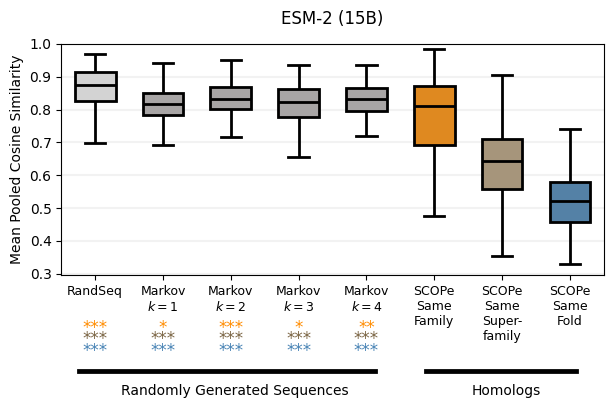

In [150]:
model_of_interest = "esm_2_15B"

fig, ax = plt.subplots(figsize = (7,3))

data = []
i = 0
my_pal = {}

c1 = "#a8a5a5"
c2 = "#fcc879"

needed_keys = ['markov_window_1', 'markov_window_2', 'markov_window_3', 'markov_window_4']

data.append(model_to_dists[model_of_interest]["randseq"])
my_pal[str(i)] = "lightgray"
i+=1

for k in needed_keys:
    data.append(model_to_dists[model_of_interest][k])
    my_pal[str(i)] = c1
    i += 1
    
# data.append([])
# my_pal[str(i)] = c1
# i += 1

v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_family"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "darkorange"
i += 1

v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_superfamily_different_family"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "#ad9674"
i += 1


v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_fold_different_superfamily"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "steelblue"
i += 1

sns.boxplot(
    data, 
    color = "black", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal,
    width = 0.6
)

labels = [
    "RandSeq",
    "Markov\n$k=1$",
    "Markov\n$k=2$",
    "Markov\n$k=3$", 
    "Markov\n$k=4$",
    "SCOPe\nSame\nFamily",
    "SCOPe\nSame\nSuper-\nfamily",
    "SCOPe\nSame\nFold",
]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels, fontsize = 9)

for i in range(0, len(data) - 3):
    st1, p1 = scipy.stats.mannwhitneyu(data[i], data[-3], alternative = "greater")
    stars_1 = p_val_to_stars(p1)
    ax.text((i+0.5)/len(data), -0.25, stars_1, color = "darkorange", fontsize = 12, horizontalalignment="center", transform = ax.transAxes)
    
    st1, p2 = scipy.stats.mannwhitneyu(data[i], data[-2], alternative = "greater")
    stars_2 = p_val_to_stars(p2)
    ax.text((i+0.5)/len(data), -0.3, stars_2, color = "#7a6443", fontsize = 12, horizontalalignment="center", transform = ax.transAxes)
    
    st1, p3 = scipy.stats.mannwhitneyu(data[i], data[-1], alternative = "greater")
    stars_3 = p_val_to_stars(p3)
    ax.text((i+0.5)/len(data), -0.35, stars_3, color = "steelblue", fontsize = 12, horizontalalignment="center",  transform = ax.transAxes)
    
ax.set_ylabel("Mean Pooled Cosine Similarity")
ax.set_ylim(top = 1.)
for y in ax.get_yticks():
    ax.axhline(y = y, color = "black", alpha = 0.05, zorder = 1)
    
rect = mpatches.Rectangle(
    (0.03, -0.42), 
    0.55, 
    0.01, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

ax.text(0.32, -0.52, "Randomly Generated Sequences", horizontalalignment = "center", transform = ax.transAxes)


rect = mpatches.Rectangle(
    (0.67, -0.42), 
    0.28, 
    0.01, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

ax.text(0.82, -0.52, "Homologs", horizontalalignment = "center", transform = ax.transAxes)

ax.set_title("ESM-2 (15B)", y = 1.05)

save_figure(fig, "esm_2_15B_orphanange_dist_to_scope_boxplots")

/tmp/ipykernel_21302/136646872.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/136646872.py:107: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/136646872.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/136646872.py:107: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/136646872.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

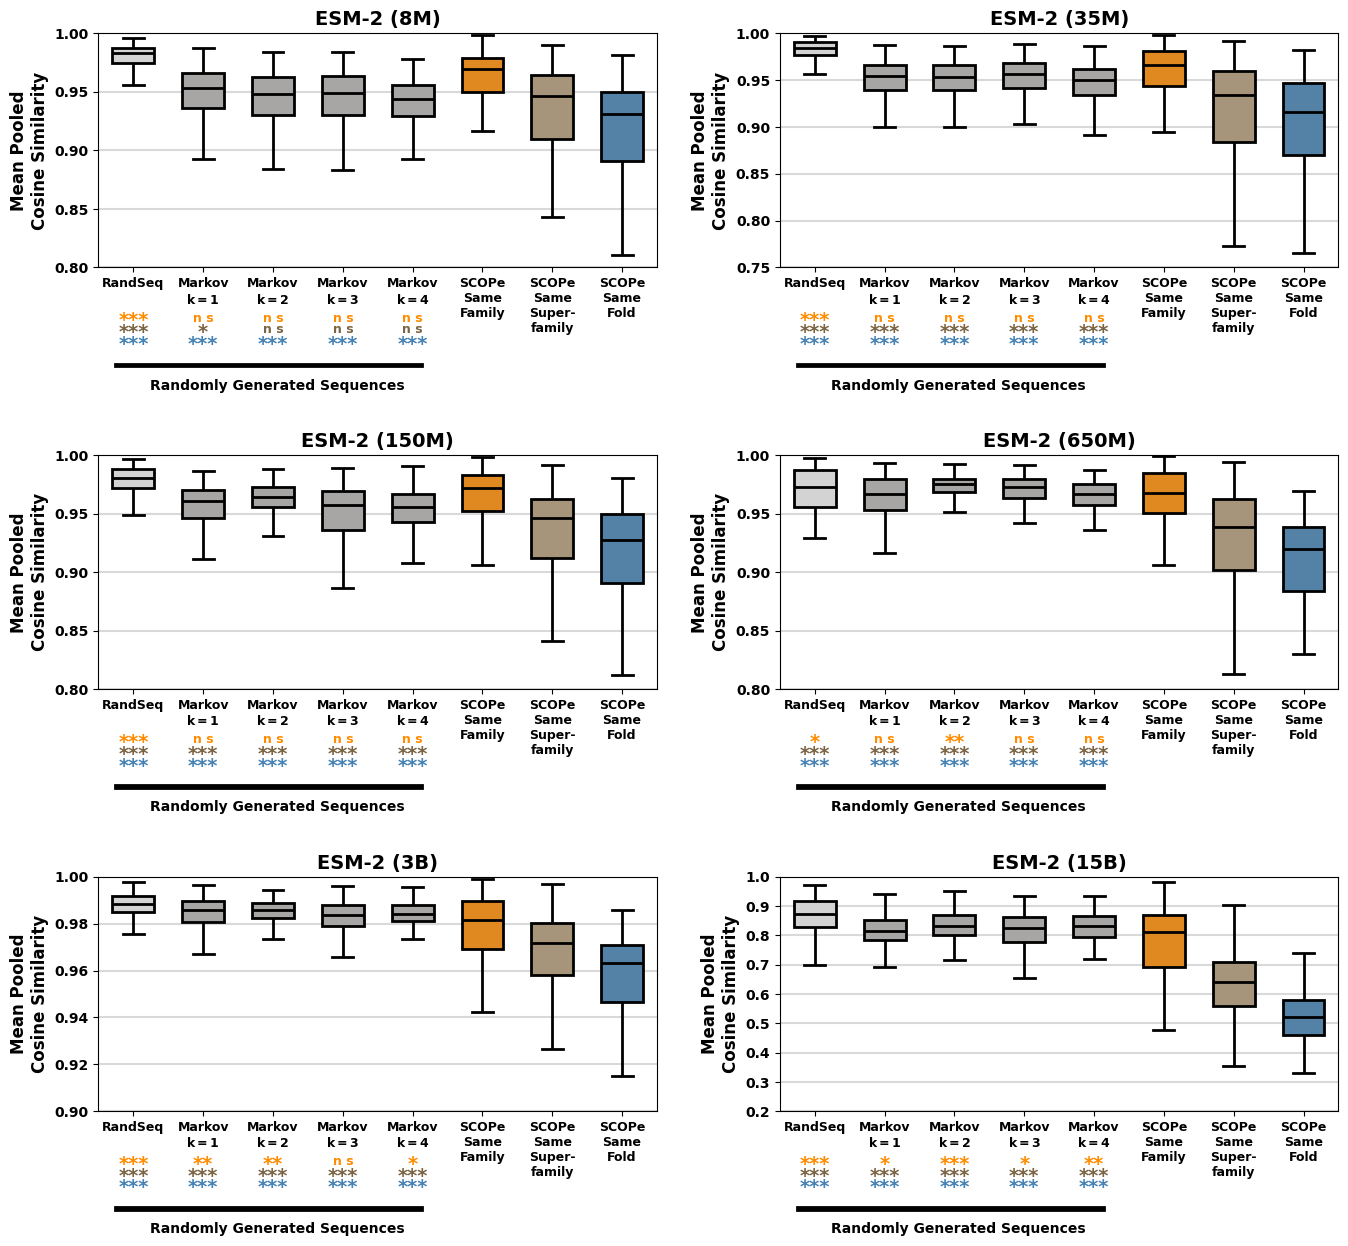

In [151]:
fig, axes = plt.subplots(3,2,figsize = (16,14))
axes = axes.ravel()
fig.subplots_adjust(hspace = 0.8, wspace = 0.22)


for i, model_of_interest in enumerate(models_in_question):
    ax = axes[i]
    
    data = []
    i = 0
    my_pal = {}

    c1 = "#a8a5a5"
    c2 = "#fcc879"

    needed_keys = ['markov_window_1', 'markov_window_2', 'markov_window_3', 'markov_window_4']

    data.append(model_to_dists[model_of_interest]["randseq"])
    my_pal[str(i)] = "lightgray"
    i+=1

    for k in needed_keys:
        data.append(model_to_dists[model_of_interest][k])
        my_pal[str(i)] = c1
        i += 1

    # data.append([])
    # my_pal[str(i)] = c1
    # i += 1

    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_family"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "darkorange"
    i += 1

    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_superfamily_different_family"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "#ad9674"
    i += 1


    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_fold_different_superfamily"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "steelblue"
    i += 1

    sns.boxplot(
        data, 
        color = "black", 
        boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
        medianprops=dict(linewidth=2, color='black', zorder = 100),
        whiskerprops=dict(linewidth=2, color='black', zorder = 100),
        capprops = dict(linewidth=2, color='black', zorder = 100),
        showfliers = False,
        palette = my_pal,
        width = 0.6,
        ax = ax
    )

    labels = [
        "RandSeq",
        "Markov\n$\mathbf{k=1}$",
        "Markov\n$\mathbf{k=2}$",
        "Markov\n$\mathbf{k=3}$", 
        "Markov\n$\mathbf{k=4}$",
        "SCOPe\nSame\nFamily",
        "SCOPe\nSame\nSuper-\nfamily",
        "SCOPe\nSame\nFold",
    ]

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, fontsize = 9, fontweight = "bold")

    for i in range(0, len(data) - 3):
        
        st1, p1 = scipy.stats.mannwhitneyu(data[i], data[-3], alternative = "greater")
        stars_1 = p_val_to_stars(p1)
        
        
       
        ax.text((i+0.5)/len(data), -0.23 if stars_1 == "ns" else -0.25, "n s" if stars_1 == "ns" else stars_1, color = "darkorange", fontsize = 9 if stars_1 == "ns" else 14, fontweight = "bold", horizontalalignment="center", transform = ax.transAxes)

        st1, p2 = scipy.stats.mannwhitneyu(data[i], data[-2], alternative = "greater")
        stars_2 = p_val_to_stars(p2)
        ax.text((i+0.5)/len(data), -0.28 if stars_2 == "ns" else -0.3, "n s" if stars_2 == "ns" else stars_2, color = "#7a6443", fontsize = 9 if stars_2 == "ns" else 14, fontweight = "bold", horizontalalignment="center", transform = ax.transAxes)

        st1, p3 = scipy.stats.mannwhitneyu(data[i], data[-1], alternative = "greater")
        stars_3 = p_val_to_stars(p3)
        ax.text((i+0.5)/len(data), -0.35, "n s" if stars_3 == "ns" else stars_3, color = "steelblue", fontsize = 9 if stars_3 == "ns" else 14, horizontalalignment="center", fontweight = "bold",  transform = ax.transAxes)

    ax.set_ylabel("Mean Pooled\nCosine Similarity", fontsize = 12, fontweight = "bold")
    ax.set_yticks(ax.get_yticks())
    ax.set_ylim(top = 1.)
    
    for y in ax.get_yticks():
        ax.axhline(y = y, color = "black", alpha = 0.15, zorder = 1)

    rect = mpatches.Rectangle(
        (0.03, -0.42), 
        0.55, 
        0.01, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    
    ax.text(0.32, -0.52, "Randomly Generated Sequences", horizontalalignment = "center", transform = ax.transAxes, fontweight = "bold")


    ax.set_title(model_to_base_string[model_of_interest] + " (" + model_to_params_string[model_of_interest] + ")", y= 1.0, fontsize = 14, fontweight = "bold")



In [152]:
# fig.delaxes(axes[-1])

save_figure(fig, "all_model_orphanange_dist_to_scope_boxplots")

1189


/tmp/ipykernel_21302/3379559107.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/3379559107.py:78: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/3379559107.py:95: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/3379559107.py:112: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(


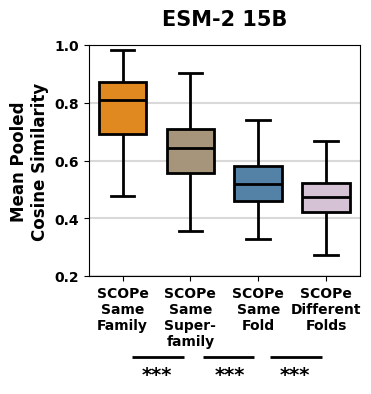

In [153]:
model_of_interest = "esm_2_15B"

fig, ax = plt.subplots(figsize = (3.5,3))

data = []
i = 0
my_pal = {}


v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_family"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "darkorange"
i += 1

v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_superfamily_different_family"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "#ad9674"
i += 1


v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_fold_different_superfamily"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "steelblue"
i += 1

control_df = model_to_control_df[model_of_interest]
print(len(control_df))

v1 = control_df.sample(frac = 1, random_state = random_state)["cos_sim"].values

data.append(v1)
my_pal[str(i)] = "thistle"
i += 1


sns.boxplot(
    data, 
    color = "black", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal,
    width = 0.7
)

labels = [
    "SCOPe\nSame\nFamily",
    "SCOPe\nSame\nSuper-\nfamily",
    "SCOPe\nSame\nFold",
    "SCOPe\nDifferent\nFolds"
]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels, fontsize = 10, fontweight = "bold")

ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylabel("Mean Pooled\nCosine Similarity", fontsize = 12, fontweight = "bold")
ax.set_ylim(top = 1.)
for y in ax.get_yticks():
    ax.axhline(y = y, color = "black", alpha = 0.15, zorder = 1)
    

ax.set_title("ESM-2 15B", y = 1.05,  fontsize = 15, fontweight = "bold")


rect = mpatches.Rectangle(
    (0.16, -0.35), 
    0.19, 
    0.001, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

st1, p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "greater")
stars_1 = p_val_to_stars(p1)
ax.text(0.25, -0.45,stars_1,fontsize = 14, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")


rect = mpatches.Rectangle(
    (0.42, -0.35), 
    0.19, 
    0.001, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

st2, p2 = scipy.stats.mannwhitneyu(data[1], data[2], alternative = "greater")
stars_2 = p_val_to_stars(p2)
ax.text(0.52, -0.45,stars_2, fontsize = 14, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")


rect = mpatches.Rectangle(
    (0.67, -0.35), 
    0.19, 
    0.001, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

st3, p3 = scipy.stats.mannwhitneyu(data[2], data[3], alternative = "greater")
stars_3 = p_val_to_stars(p3)
ax.text(0.76, -0.45,stars_3,fontsize = 14, fontweight = "bold",transform = ax.transAxes, horizontalalignment="center")

save_figure(fig, "scope_class_comparisons_15B")

/tmp/ipykernel_21302/2143757041.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/2143757041.py:82: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/2143757041.py:99: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/2143757041.py:116: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/2143757041.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/2143757041.py:8

1.2557259266446898e-07 0.005035004658450227 0.0033861109251257975
4.33768825312017e-09 0.029981308776519135 0.024126983189196937
2.4698204650627507e-09 0.000229833400750854 0.003540158923532057
2.7497269111469878e-08 0.003270775368847394 0.00349951260397994
5.519041181745923e-05 0.0002503944112239137 0.00014195927841353662
1.1613502798985063e-12 4.563594133796752e-09 5.929319874216524e-08


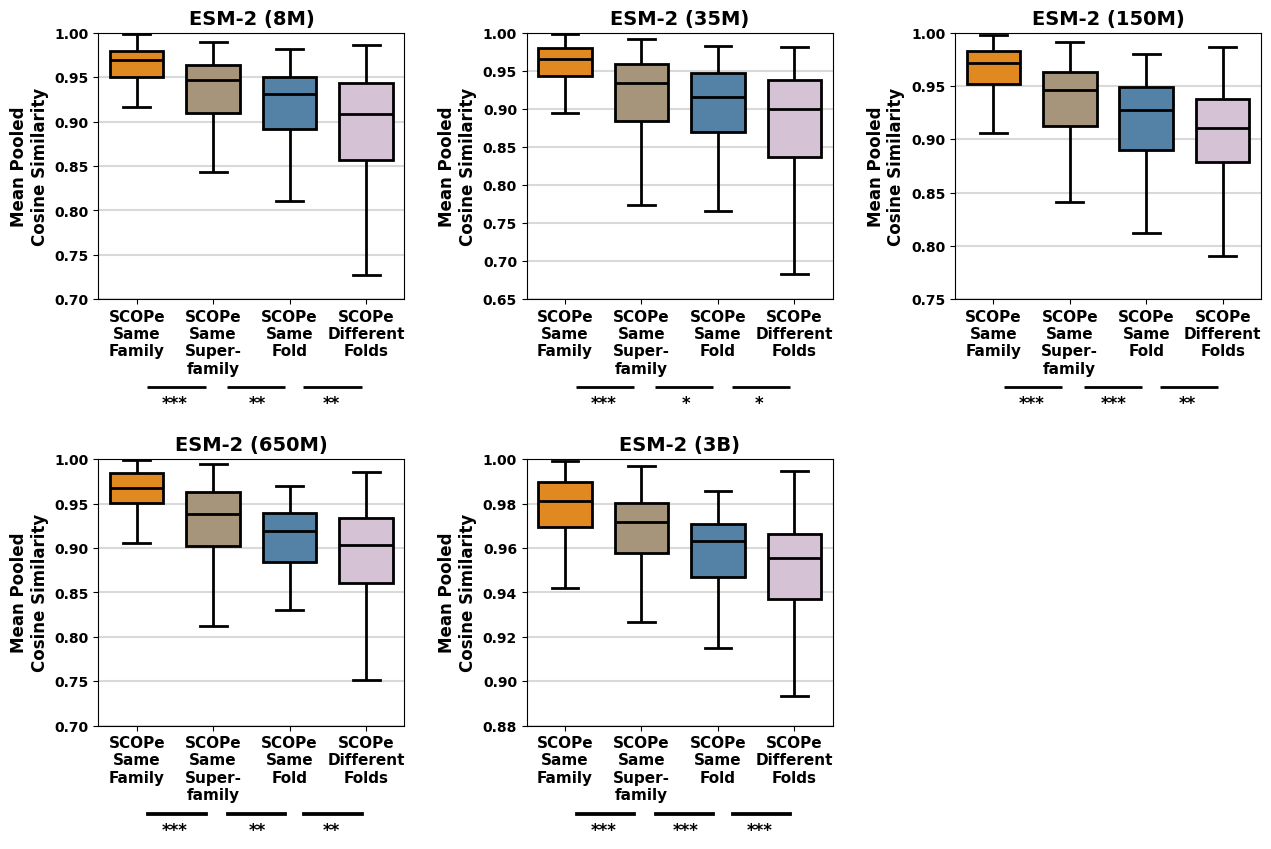

In [154]:
fig, axes = plt.subplots(2,3,figsize = (15,9))
axes = axes.ravel()
fig.subplots_adjust(hspace = 0.6, wspace = 0.4)


for ax_i, model_of_interest in enumerate(models_in_question):

    ax = axes[ax_i]
    
    data = []
    i = 0
    my_pal = {}


    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_family"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "darkorange"
    i += 1

    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_superfamily_different_family"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "#ad9674"
    i += 1


    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_fold_different_superfamily"
    ][model_of_interest].values

    data.append(v1)
    my_pal[str(i)] = "steelblue"
    i += 1

    control_df = model_to_control_df[model_of_interest]

    v1 = control_df.sample(frac = 1, random_state = random_state)["cos_sim"].values

    data.append(v1)
    my_pal[str(i)] = "thistle"
    i += 1


    sns.boxplot(
        data, 
        color = "black", 
        boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
        medianprops=dict(linewidth=2, color='black', zorder = 100),
        whiskerprops=dict(linewidth=2, color='black', zorder = 100),
        capprops = dict(linewidth=2, color='black', zorder = 100),
        showfliers = False,
        palette = my_pal,
        width = 0.7,
        ax=ax
    )

    labels = [
        "SCOPe\nSame\nFamily",
        "SCOPe\nSame\nSuper-\nfamily",
        "SCOPe\nSame\nFold",
        "SCOPe\nDifferent\nFolds"
    ]

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, fontsize = 11, fontweight = "bold")

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    ax.set_ylabel("Mean Pooled\nCosine Similarity", fontweight = "bold", fontsize = 12)
    ax.set_ylim(top = 1.)
    for y in ax.get_yticks():
        ax.axhline(y = y, color = "black", alpha = 0.15, zorder = 1)




    rect = mpatches.Rectangle(
        (0.16, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st1, p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "greater")
    stars_1 = p_val_to_stars(p1)
    ax.text(0.25, -0.41,stars_1,fontsize = 12,transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")


    rect = mpatches.Rectangle(
        (0.42, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st2, p2 = scipy.stats.mannwhitneyu(data[1], data[2], alternative = "greater")
    stars_2 = p_val_to_stars(p2)
    ax.text(0.52, -0.41,stars_2,fontsize = 12,transform = ax.transAxes, fontweight = "bold",horizontalalignment="center")


    rect = mpatches.Rectangle(
        (0.67, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st3, p3 = scipy.stats.mannwhitneyu(data[2], data[3], alternative = "greater")
    stars_3 = p_val_to_stars(p3)
    ax.text(0.76, -0.41,stars_3,fontsize = 12,transform = ax.transAxes,fontweight = "bold", horizontalalignment="center")
    
    ax.set_title(model_to_base_string[model_of_interest] + " (" + model_to_params_string[model_of_interest] + ")", y= 1.0,fontweight = "bold", fontsize = 14)
    
    print(p1, p2, p3)
    
fig.delaxes(axes[-1])

save_figure(fig, "scope_class_comparisons_all_models")

/tmp/ipykernel_21302/4197512830.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/4197512830.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/4197512830.py:98: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/4197512830.py:115: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(
/tmp/ipykernel_21302/4197512830.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/4197512830.py:8

1.7503680228225101e-06 0.025604097524659464 0.0020559226580442844
2.2985533424818103e-07 0.010517699457209196 0.014096160472773074
3.075932612611675e-08 0.0004882106960963667 0.08815260769820282
1.80755521899718e-07 0.0003546963178341439 0.08824730428398186
4.7356159584831845e-05 0.0002530818420183756 0.022354202337540367
2.5139905908186654e-07 2.628025493379567e-05 0.002841259677841205


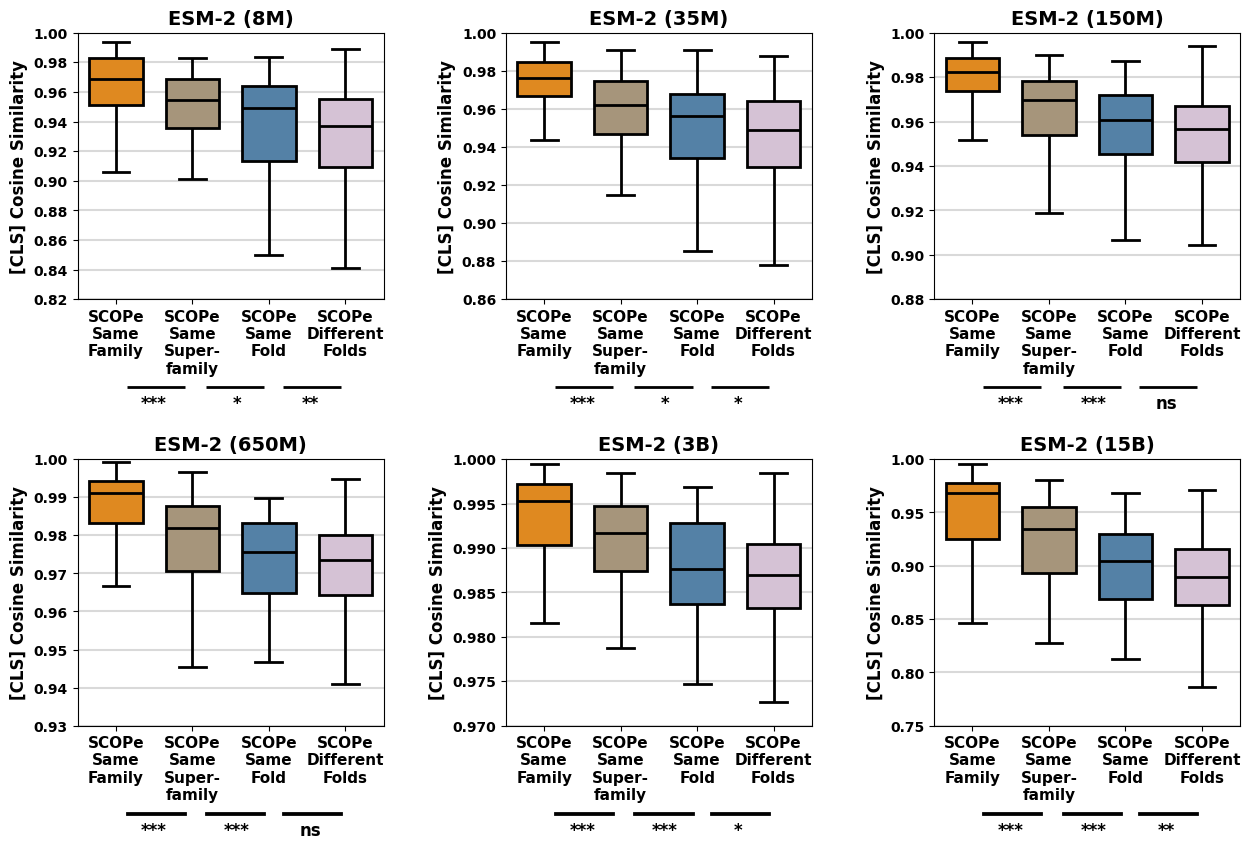

In [155]:
fig, axes = plt.subplots(2,3,figsize = (15,9))
axes = axes.ravel()
fig.subplots_adjust(hspace = 0.6, wspace = 0.4)


for ax_i, model_of_interest in enumerate(models_in_question):

    ax = axes[ax_i]
    
    data = []
    i = 0
    my_pal = {}


    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_family"
    ][model_of_interest + "_CLS"].values

    data.append(v1)
    my_pal[str(i)] = "darkorange"
    i += 1

    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_superfamily_different_family"
    ][model_of_interest + "_CLS"].values

    data.append(v1)
    my_pal[str(i)] = "#ad9674"
    i += 1


    v1 = family_fold_superfamily_choices.loc[
        family_fold_superfamily_choices["grouping"] == "same_fold_different_superfamily"
    ][model_of_interest + "_CLS"].values

    data.append(v1)
    my_pal[str(i)] = "steelblue"
    i += 1

    control_df = model_to_control_df[model_of_interest]

    v1 = control_df.sample(frac = 1, random_state = random_state)["cos_sim_CLS"].values

    data.append(v1)
    my_pal[str(i)] = "thistle"
    i += 1


    sns.boxplot(
        data, 
        color = "black", 
        boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
        medianprops=dict(linewidth=2, color='black', zorder = 100),
        whiskerprops=dict(linewidth=2, color='black', zorder = 100),
        capprops = dict(linewidth=2, color='black', zorder = 100),
        showfliers = False,
        palette = my_pal,
        width = 0.7,
        ax=ax
    )

    labels = [
        "SCOPe\nSame\nFamily",
        "SCOPe\nSame\nSuper-\nfamily",
        "SCOPe\nSame\nFold",
        "SCOPe\nDifferent\nFolds"
    ]

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, fontsize = 11, fontweight = "bold")

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    ax.set_ylabel("[CLS] Cosine Similarity", fontweight = "bold", fontsize = 12)
    ax.set_ylim(top = 1.)
    for y in ax.get_yticks():
        ax.axhline(y = y, color = "black", alpha = 0.15, zorder = 1)



    rect = mpatches.Rectangle(
        (0.16, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st1, p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "greater")
    stars_1 = p_val_to_stars(p1)
    ax.text(0.25, -0.41,stars_1,fontsize = 12,transform = ax.transAxes,  fontweight = "bold", horizontalalignment="center")


    rect = mpatches.Rectangle(
        (0.42, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st2, p2 = scipy.stats.mannwhitneyu(data[1], data[2], alternative = "greater")
    stars_2 = p_val_to_stars(p2)
    ax.text(0.52, -0.41,stars_2,fontsize = 12,transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")


    rect = mpatches.Rectangle(
        (0.67, -0.33), 
        0.19, 
        0.001, 
        transform = ax.transAxes, 
        clip_on=False, 
        linewidth=2, 
        edgecolor="black", 
        color = "black"
    )
    ax.add_patch(rect)

    st3, p3 = scipy.stats.mannwhitneyu(data[2], data[3], alternative = "greater")
    stars_3 = p_val_to_stars(p3)
    ax.text(0.76, -0.41,stars_3,fontsize = 12,transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")
    
    ax.set_title(model_to_base_string[model_of_interest] + " (" + model_to_params_string[model_of_interest] + ")", y= 1.0, fontsize = 14, fontweight = "bold")
    
    print(p1, p2, p3)


/tmp/ipykernel_21302/1884113290.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_21302/1884113290.py:69: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
/tmp/ipykernel_21302/1884113290.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle(


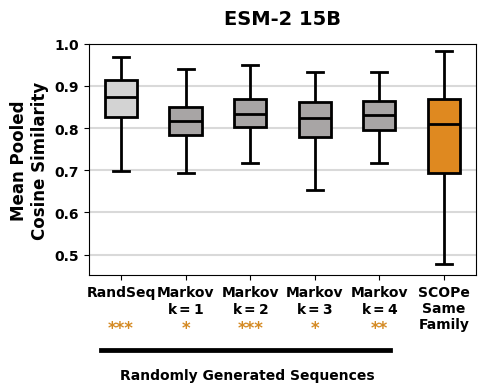

In [156]:
model_of_interest = "esm_2_15B"

fig, ax = plt.subplots(figsize = (5,3))

data = []
i = 0
my_pal = {}

c1 = "#a8a5a5"
c2 = "#fcc879"

needed_keys = ['markov_window_1', 'markov_window_2', 'markov_window_3', 'markov_window_4']

data.append(model_to_dists[model_of_interest]["randseq"])
my_pal[str(i)] = "lightgray"
i+=1

for k in needed_keys:
    data.append(model_to_dists[model_of_interest][k])
    my_pal[str(i)] = c1
    i += 1
    
# data.append([])
# my_pal[str(i)] = c1
# i += 1

v1 = family_fold_superfamily_choices.loc[
    family_fold_superfamily_choices["grouping"] == "same_family"
][model_of_interest].values

data.append(v1)
my_pal[str(i)] = "darkorange"

sns.boxplot(
    data, 
    color = "black", 
    boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False,
    palette = my_pal,
    width = 0.5
)

labels = [
    "RandSeq",
    "Markov\n$\mathbf{k=1}$",
    "Markov\n$\mathbf{k=2}$",
    "Markov\n$\mathbf{k=3}$", 
    "Markov\n$\mathbf{k=4}$",
    "SCOPe\nSame\nFamily",
]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels, fontsize = 10, fontweight = "bold")

for i in range(0, len(data) - 1):
    st1, p1 = scipy.stats.mannwhitneyu(data[i], data[-1], alternative = "greater")
    stars_1 = p_val_to_stars(p1)
    ax.text((i+0.5)/len(data), -0.25, stars_1, color = "#d48a24", fontsize = 12, fontweight = "bold", horizontalalignment="center", transform = ax.transAxes)
    
ax.set_ylabel("Mean Pooled\nCosine Similarity", fontweight = "bold", fontsize = 12)
ax.set_ylim(top = 1.)
for y in ax.get_yticks():
    ax.axhline(y = y, color = "black", alpha = 0.15, zorder = 1)
    
    
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
rect = mpatches.Rectangle(
    (0.03, -0.33), 
    0.75, 
    0.01, 
    transform = ax.transAxes, 
    clip_on=False, 
    linewidth=2, 
    edgecolor="black", 
    color = "black"
)
ax.add_patch(rect)

ax.text(0.41, -0.45, "Randomly Generated Sequences", horizontalalignment = "center",fontweight = "bold", transform = ax.transAxes)


ax.set_title("ESM-2 15B", y = 1.05, fontsize = 14, fontweight = "bold")

save_figure(fig, "esm_2_15B_orphanange_dist_to_scope_boxplots_only_family")

In [157]:
bottom_set = df.loc[df["homologs"] > 0].sort_values(by = "homologs").head(25)
top_set = df.loc[df["homologs"] > 0].sort_values(by = "homologs").tail(25)

top_set_100 = df.loc[df["homologs"] > 0].sort_values(by = "homologs").tail(100)

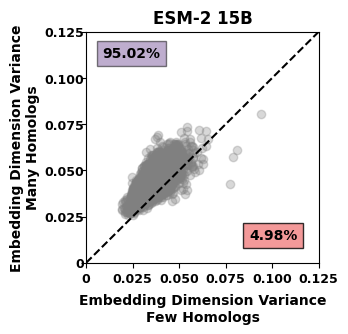

In [158]:
model_in_q = "esm_2_15B"
source_path= homstrad_path + "./embedding_extractions/" + model_in_q + "/" 


emb_list_1 = []
for k in bottom_set["id"].values:
    emb = depickle_obj(source_path + k + ".pkl")
    emb_list_1.append(emb[1:-1])
    
emb_list_2 = []

for k in top_set["id"].values:
    emb = depickle_obj(source_path + k + ".pkl")
    emb_list_2.append(emb[1:-1])
    


arr_1 = np.concatenate(emb_list_1, axis = 0)
arr_2 = np.concatenate(emb_list_2, axis = 0)

above_color = "#7e5d9e"
below_color = "lightcoral"

x, y = [], []

for i, dim in enumerate(arr_1.T):
    x.append(np.var(dim)) 
    
for i, dim in enumerate(arr_2.T):
    y.append(np.var(dim))  

above_line = 0
below_line = 0

colors = []
for xval, yval in zip(x,y):
    if yval > xval:
        above_line += 1
        colors.append(above_color)
    else:
        below_line += 1
        colors.append(below_color)
    
fig, ax = plt.subplots(figsize = (3,3))

x1 = np.linspace(0,0.1,100)

ax.scatter(
    x,
    y, 
    c="gray", 
    alpha = 0.3,
    zorder = 1
)
ax.set_xlim(right = 0.125,left = 0)
ax.set_ylim(top = 0.125,bottom = 0)
x1 = np.linspace(0, 0.125, 100)
ax.plot(x1,x1,color = "black", linestyle = "--", zorder = 100)
ticks = [0,0.025,0.05,0.075,0.1,0.125]
ticklabels = ["0", "0.025", "0.050", "0.075", "0.100", "0.125"]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticklabels,rotation = 0, fontsize = 9,  fontweight = "bold")
ax.set_yticklabels(ticklabels, fontsize = 9, fontweight = "bold")

for tick in ax.get_yaxis().get_major_ticks():
    tick.set_pad(-2.0)

pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"

ax.text(
    0.07,
    0.89,
    pct_above, 
    transform = ax.transAxes, 
    color = "black", 
    bbox=dict(facecolor=above_color,alpha = 0.5, edgecolor=None),
    fontweight = "bold"
)

ax.text(
    0.7,
    0.1,
    pct_below, 
    transform = ax.transAxes, 
    color = "black", 
    bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None),
    fontweight = "bold"
)



ax.set_xlabel("Embedding Dimension Variance\nFew Homologs",labelpad = 6, fontsize = 10,  fontweight = "bold")
ax.set_ylabel("Embedding Dimension Variance\nMany Homologs", labelpad = 3, fontsize = 10,  fontweight = "bold")
ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q],  fontweight = "bold")

save_figure(fig, "scope_esm_2_15B_many_vs_few_embedding_variance")

In [159]:
model_to_joined_embeddings_top_bottom_scope = {}
for model_in_q in models_in_question:
    source_path= homstrad_path + "./embedding_extractions/" + model_in_q + "/" 

    emb_list_1 = []
    for k in bottom_set["id"].values:
        emb = depickle_obj(source_path + k + ".pkl")
        emb_list_1.append(emb[1:-1])

    emb_list_2 = []

    for k in top_set["id"].values:
        emb = depickle_obj(source_path + k + ".pkl")
        emb_list_2.append(emb[1:-1])

    arr_1 = np.concatenate(emb_list_1, axis = 0)
    arr_2 = np.concatenate(emb_list_2, axis = 0)
    model_to_joined_embeddings_top_bottom_scope[model_in_q] = {"low_homs" : arr_1, "high_homs" : arr_2}

In [160]:
embedding_dimension_table_tracker_scope_top_bottom = []

320 320 proportion non-orphan higher :  1.0
480 480 proportion non-orphan higher :  1.0
640 640 proportion non-orphan higher :  0.9984375
1280 1280 proportion non-orphan higher :  0.9984375
2560 2560 proportion non-orphan higher :  0.999609375
5120 5120 proportion non-orphan higher :  0.9501953125


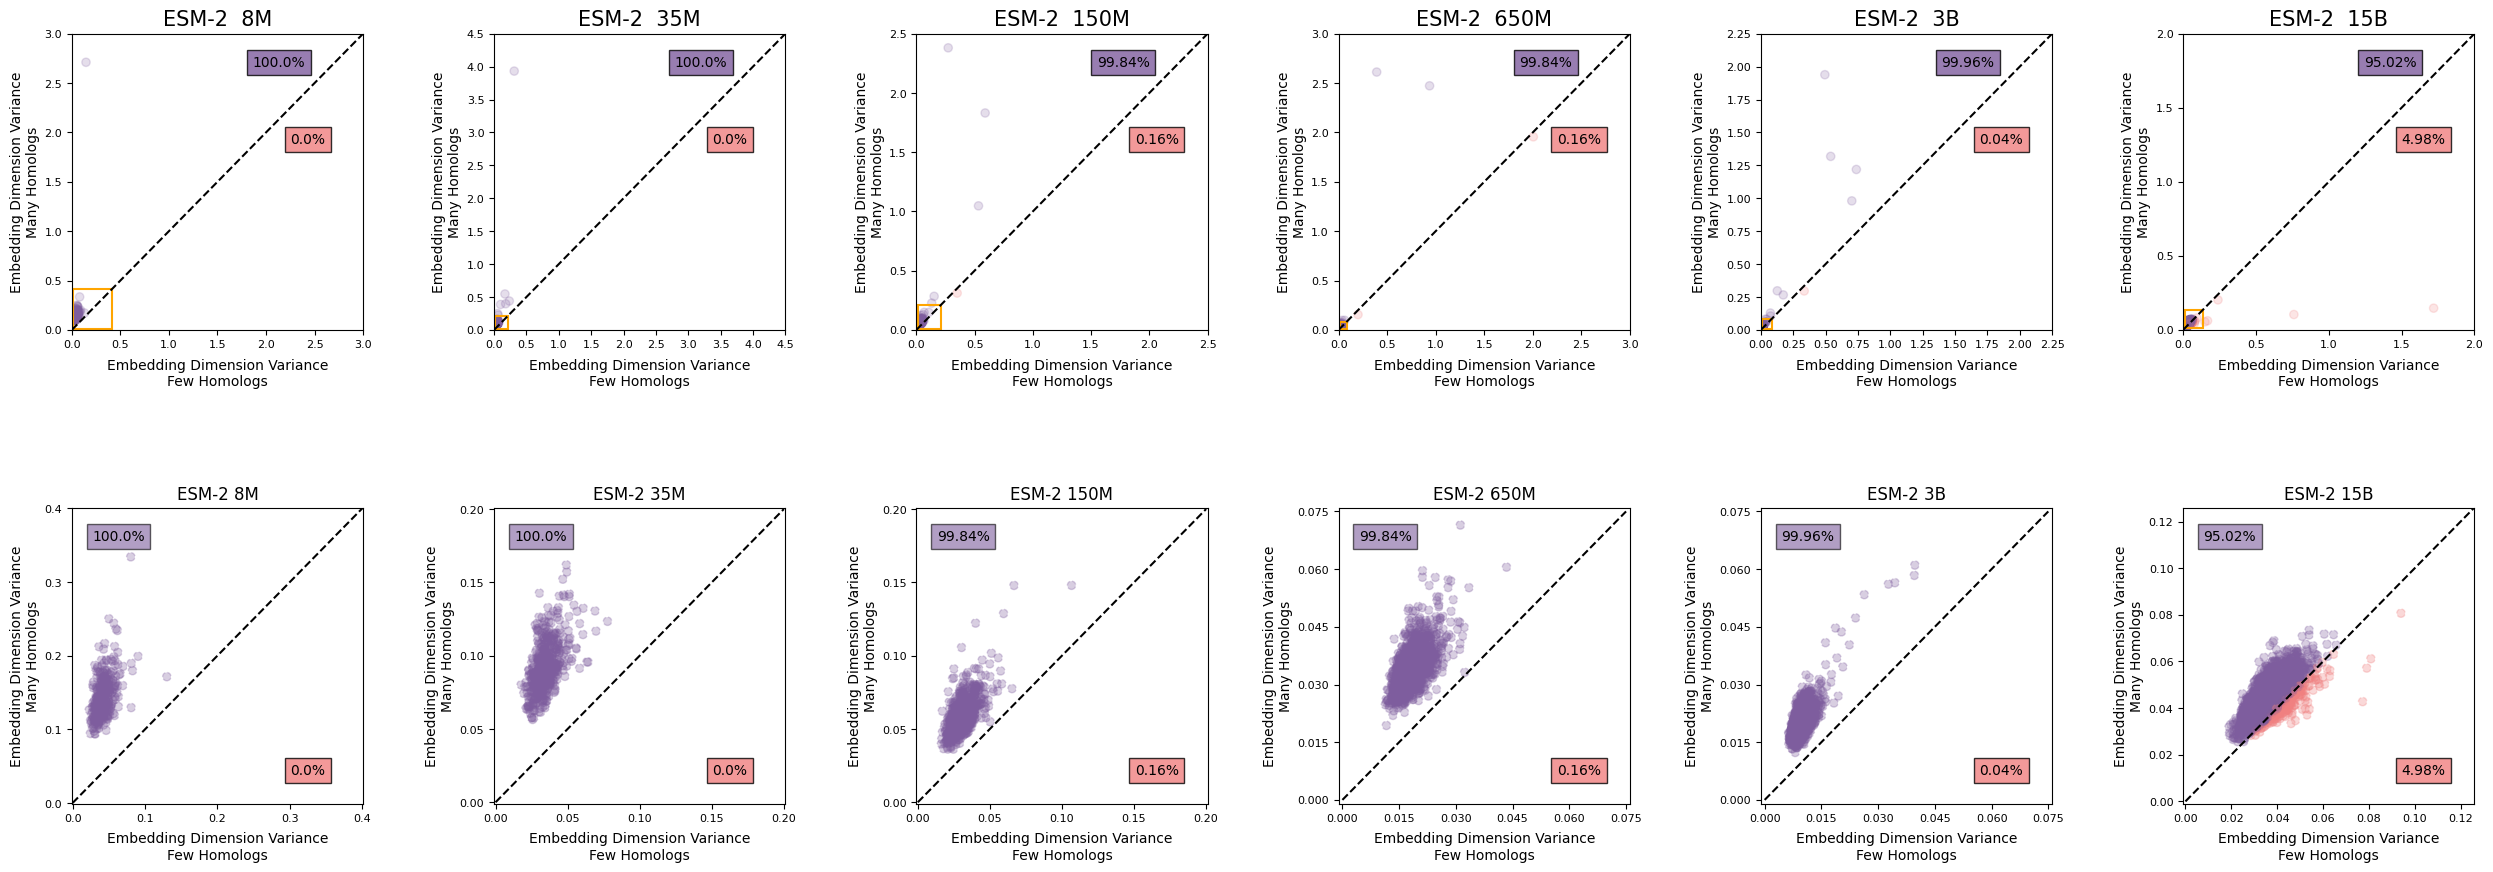

In [161]:

fig, axes = plt.subplots(2, 6, figsize = (31,10))
axes = axes.ravel()

fig.subplots_adjust(hspace = 0.6, wspace = 0.45)


model_to_inset_pos = {
    "esm_2_8M" : 0.4,
    "esm_2_35M" : 0.2,
    "esm_2_150M" : 0.2,
    "esm_2_650M" : 0.075,
    "esm_2" : 0.075,
    "esm_2_15B" : 0.125,
    
}

model_to_inset_ticks = {
    "esm_2_8M" : np.arange(0, 0.4 + 0.001, 0.1),
    "esm_2_35M" : np.arange(0, 0.2 + 0.001, 0.05),
    "esm_2_150M" : np.arange(0, 0.2 + 0.001, 0.05),
    "esm_2_650M" : np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2" :np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2_15B" : np.arange(0, 0.14 + 0.001, 0.02)
}

above_color = "#7e5d9e"
below_color = "lightcoral"

scope_model_to_dimension_summary_stats = {}

for ax_i, model_in_q in enumerate(models_in_question):
    joined_embeddings_low = model_to_joined_embeddings_top_bottom_scope[model_in_q]["low_homs"]
    joined_embeddings_high = model_to_joined_embeddings_top_bottom_scope[model_in_q]["high_homs"]
    
    x = []
    y = []
    color_list_full = []
    
    inset_xlim = model_to_inset_pos[model_in_q]
    inset_ylim = model_to_inset_pos[model_in_q]

    inset_x = []
    inset_y = []
    color_list_inset = []

    above_line = 0
    below_line = 0 
    
    
    for i in range(np.shape(joined_embeddings_low)[1]):
        arr_1 = joined_embeddings_low[:, i]
        arr_2 = joined_embeddings_high[:, i]
        v1 = np.var(arr_1)
        v2 = np.var(arr_2)
        if v2 > v1:
            above_line += 1
            color_list_full.append(above_color)
        else:
            below_line += 1
            color_list_full.append(below_color)
            
        x.append(v1)
        y.append(v2)
        
        embedding_dimension_table_tracker_scope_top_bottom.append(["SCOPe 25 Proteins with fewest homologs", model_in_q, i, v1])
        embedding_dimension_table_tracker_scope_top_bottom.append(["SCOPe 25 Proteins with most homologs", model_in_q, i, v2])
        
        if v1 < inset_xlim and v2 < inset_ylim:
            inset_x.append(v1)
            inset_y.append(v2)
            if v2 > v1:
                color_list_inset.append(above_color)
            else:
                
                color_list_inset.append(below_color)
            
        
    print(len(x), len(y), "proportion non-orphan higher : ", above_line/len(x) )
        
    ax1 = axes[ax_i]
    ax2 = axes[ax_i + 6]
    
    ax = ax1
    ax.scatter(x,y, alpha = 0.2, c = color_list_full)
    
    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        
    ax.set_xticks(max_ticks)
    ax.set_yticks(max_ticks)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 8)
        
    x1 = np.linspace(0, np.max(max_ticks), 100)
    ax.plot(x1,x1, linestyle = "--", color = "black",)
    
    display_epsilon = 0.01
    rect = patches.Rectangle((0+display_epsilon, 0+display_epsilon), inset_xlim, inset_ylim, lw=1.5, edgecolor='orange', facecolor='none')
    ax.add_patch(rect)
    ax.set_xlim(left = 0, right = np.max(max_ticks) )
    ax.set_ylim(bottom = 0, top = np.max(max_ticks))
    
    
    pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
    pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"
    
    scope_model_to_dimension_summary_stats[model_in_q] = {"above" : pct_above, "below" : pct_below}
    
    ax.text(
        0.62,0.89,pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None)
    )

    ax.text(
        0.75,0.63,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None)
    )
    
    ax.set_xlabel("Embedding Dimension Variance\nFew Homologs",labelpad = 6, fontsize = 10)
    ax.set_ylabel("Embedding Dimension Variance\nMany Homologs", labelpad = 3, fontsize = 10)
    ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q])

    
    ax.set_title(model_to_base_string[model_in_q] + "  " + model_to_params_string[model_in_q], fontsize = 15)
    
    ax = ax2 

    ax.scatter(inset_x, inset_y, linestyle = "--", alpha = 0.3, c = color_list_inset)

#     ax.set_ylabel("Embedding Variance\n25 Human Selections", fontsize = 12)
#     ax.set_xlabel("Embedding Variance\n25 Orphan Proteins", fontsize = 12)
    
#     ax.set_title(model_to_base_string[model_in_q] + "  " + model_to_params_string[model_in_q], fontsize = 15)
    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        
#     inset_ticks = np.arange(0, inset_ylim + 0.001, 0.015)

    ax.set_xticks(model_to_inset_ticks[model_in_q])
    ax.set_yticks(model_to_inset_ticks[model_in_q])
    
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 8)
    ax.set_xlim(left = -0.01)
    ax.set_ylim(bottom = -0.01)
    x1 = np.linspace(0, np.max(model_to_inset_ticks[model_in_q]), 100)

    ax.plot(x1,x1, linestyle = "--", color = "black",  )
    ax.set_xlim(right = inset_xlim + 0.001, left = -0.001)
    ax.set_ylim(top = inset_xlim + 0.001, bottom = -0.001)
    
    ax.set_xlabel("Embedding Dimension Variance\nFew Homologs",labelpad = 6, fontsize = 10)
    ax.set_ylabel("Embedding Dimension Variance\nMany Homologs", labelpad = 3, fontsize = 10)
    ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q])

    ax.text(
        0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.6, edgecolor=None)
    )

    ax.text(
        0.75,0.1,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None)
    )



save_figure(fig, f"esm_2_models_variance_scope_proteins_together")
    






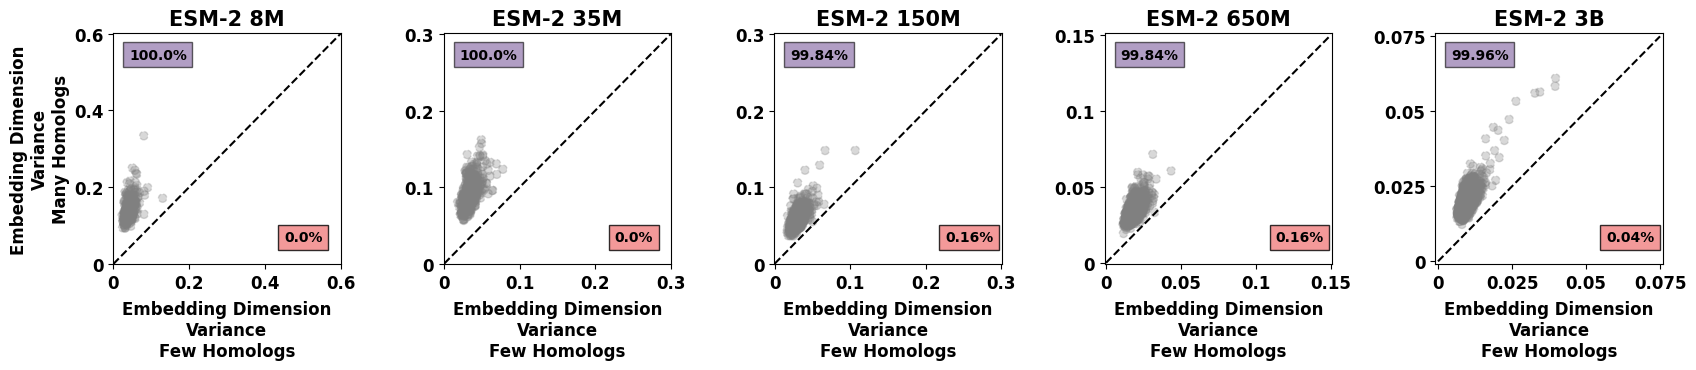

In [162]:

fig, axes = plt.subplots(1,5, figsize = (20,3))
axes = axes.ravel()

fig.subplots_adjust(hspace = 0.6, wspace = 0.45)



x_ticklist = [
    [0,0.2,0.4,0.6],
    [0,0.1,0.2,0.3],
    [0,0.1,0.2,0.3],
    [0,0.05,0.1,0.15],
    [0,0.025,0.05,0.075],
    
]



model_to_inset_pos = {
    "esm_2_8M" : 0.4,
    "esm_2_35M" : 0.2,
    "esm_2_150M" : 0.2,
    "esm_2_650M" : 0.075,
    "esm_2" : 0.075,
    "esm_2_15B" : 0.125,
    
}

model_to_inset_ticks = {
    "esm_2_8M" : np.arange(0, 0.4 + 0.001, 0.1),
    "esm_2_35M" : np.arange(0, 0.2 + 0.001, 0.05),
    "esm_2_150M" : np.arange(0, 0.2 + 0.001, 0.05),
    "esm_2_650M" : np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2" :np.arange(0, 0.075 + 0.001, 0.015),
    "esm_2_15B" : np.arange(0, 0.14 + 0.001, 0.02)
}


above_color = "#7e5d9e"
below_color = "lightcoral"

scope_model_to_dimension_summary_stats = {}

for ax_i, model_in_q in enumerate(models_in_question):
    
    if model_in_q == "esm_2_15B":
        continue 
        
    joined_embeddings_low = model_to_joined_embeddings_top_bottom_scope[model_in_q]["low_homs"]
    joined_embeddings_high = model_to_joined_embeddings_top_bottom_scope[model_in_q]["high_homs"]
    
    x = []
    y = []
    color_list_full = []
    
    inset_xlim = model_to_inset_pos[model_in_q]
    inset_ylim = model_to_inset_pos[model_in_q]

    inset_x = []
    inset_y = []
    color_list_inset = []

    above_line = 0
    below_line = 0 
    
    
    for i in range(np.shape(joined_embeddings_low)[1]):
        arr_1 = joined_embeddings_low[:, i]
        arr_2 = joined_embeddings_high[:, i]
        v1 = np.var(arr_1)
        v2 = np.var(arr_2)
        if v2 > v1:
            above_line += 1
            color_list_full.append(above_color)
        else:
            below_line += 1
            color_list_full.append(below_color)
            
        x.append(v1)
        y.append(v2)
        
        embedding_dimension_table_tracker_scope_top_bottom.append(["SCOPe 25 Proteins with fewest homologs", model_in_q, i, v1])
        embedding_dimension_table_tracker_scope_top_bottom.append(["SCOPe 25 Proteins with most homologs", model_in_q, i, v2])
        
        if v1 < inset_xlim and v2 < inset_ylim:
            inset_x.append(v1)
            inset_y.append(v2)
            if v2 > v1:
                color_list_inset.append(above_color)
            else:
                
                color_list_inset.append(below_color)
            
    pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
    pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"
    
    
    ax = axes[ax_i] 

    ax.scatter(inset_x, inset_y, linestyle = "--", alpha = 0.3, c = "gray", zorder = 1)

    max_x = np.max(list(ax.get_xticks()))
    max_y = np.max(list(ax.get_yticks()))

    max_ticks = ax.get_yticks()
    if max_x > max_y:
        max_ticks = ax.get_xticks()
        
#     inset_ticks = np.arange(0, inset_ylim + 0.001, 0.015)

    ax.set_xticks(x_ticklist[ax_i])
    ax.set_yticks(x_ticklist[ax_i])
    
    
    ax.set_xticklabels(x_ticklist[ax_i], fontsize = 12, fontweight = "bold")
    ax.set_yticklabels(x_ticklist[ax_i], fontsize = 12, fontweight = "bold")
    ax.set_xlim(left = -0.01)
    ax.set_ylim(bottom = -0.01)
    x1 = np.linspace(0, np.max(np.max(x_ticklist[ax_i])), 100)

    ax.plot(x1,x1, linestyle = "--", color = "black",  )
    ax.set_xlim(right = np.max(x_ticklist[ax_i]) + 0.001, left = -0.001)
    ax.set_ylim(top = np.max(x_ticklist[ax_i]) + 0.001, bottom = -0.001)
    
    ax.set_xlabel("Embedding Dimension\nVariance\nFew Homologs",labelpad = 6, fontsize = 12, fontweight = "bold")
    if model_in_q == "esm_2_8M":
        
        ax.set_ylabel("Embedding Dimension\nVariance\nMany Homologs", labelpad = 3, fontsize = 12, fontweight = "bold")
    ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q], fontsize = 15, fontweight = "bold")

    ax.text(
        0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=above_color,alpha = 0.6, edgecolor=None),
        fontweight = "bold"
    )

    ax.text(
        0.75,0.1,pct_below, transform = ax.transAxes, color = "black", 
        bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None),
        fontweight = "bold"
    )






In [163]:
## making table

dfx = pd.DataFrame(embedding_dimension_table_tracker_orphan_human, columns = ["group", "model", "dimension", "joined_embeddings_dimensional_varaince"])
dfy = pd.DataFrame(embedding_dimension_table_tracker_scope_top_bottom, columns = ["group", "model", "dimension", "joined_embeddings_dimensional_varaince"])

dfz = pd.concat([dfx, dfy])
dfz["model"] = dfz["model"].apply(lambda x : model_to_display_str[x])
dfz["model"].value_counts()

dfz.to_csv(supp_table_path + "model_joined_protein_embedding_dimension_variance.csv")
        
        

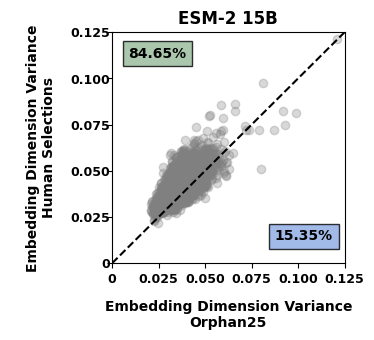

In [164]:

below_color = "#8aa9e3"
above_color = "#95b899"



model_in_q = "esm_2_15B"

orphan_embeddings = glob.glob( orphan_path + "./embeddings/" + model_in_q + "/*.pkl")
orphan_emb_list = []

for p in orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ]
    orphan_emb_list.append(emb) 

non_orphan_embeddings = glob.glob( orphan_path + "./non_orphan_embeddings/" + model_in_q + "/*.pkl")
non_orphan_emb_list = []

for p in non_orphan_embeddings:
    emb = depickle_obj(p)
    emb = emb[1:-1, ] 
    non_orphan_emb_list.append(emb) 

joined_embeddings_orphan = np.concatenate(orphan_emb_list)
joined_embeddings_non_orphan = np.concatenate(non_orphan_emb_list)

x = []
y = []
color_list_full = []

inset_xlim = model_to_inset_pos[model_in_q]
inset_ylim = model_to_inset_pos[model_in_q]

inset_x = []
inset_y = []
color_list_inset = []

above_line = 0
below_line = 0 


for i in range(np.shape(joined_embeddings_orphan)[1]):
    arr_1 = joined_embeddings_orphan[:, i]
    arr_2 = joined_embeddings_non_orphan[:, i]
    v1 = np.var(arr_1)
    v2 = np.var(arr_2)
    if v2 > v1:
        above_line += 1
        color_list_full.append(above_color)
    else:
        below_line += 1
        color_list_full.append(below_color)

    x.append(v1)
    y.append(v2)

    if v1 < inset_xlim and v2 < inset_ylim:
        inset_x.append(v1)
        inset_y.append(v2)
        if v2 > v1:
            color_list_inset.append(above_color)
        else:
            color_list_inset.append(below_color)
            
fig, ax = plt.subplots(figsize = (3,3))
            
ax.scatter(
    x,
    y, 
    c = "gray",
#     c=color_list_full, 
    alpha = 0.3,
    zorder = 1
)
ax.set_xlim(right = 0.125,left = 0)
ax.set_ylim(top = 0.125,bottom = 0)
x1 = np.linspace(0, 0.125, 100)
ax.plot(x1,x1,color = "black", linestyle = "--", zorder = 100)
ticks = [0,0.025,0.05,0.075,0.1,0.125]
ticklabels = ["0", "0.025", "0.050", "0.075", "0.100", "0.125"]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticklabels,rotation = 0, fontsize = 9,fontweight = "bold")
ax.set_yticklabels(ticklabels, fontsize = 9,fontweight = "bold")

for tick in ax.get_yaxis().get_major_ticks():
    tick.set_pad(-2.0)

pct_above = str(round((above_line / (above_line + below_line))*100, 2)) + "%"
pct_below = str(round((below_line / (above_line + below_line))*100, 2)) + "%"

ax.text(
    0.07,0.89,pct_above, transform = ax.transAxes, color = "black", 
    bbox=dict(facecolor=above_color,alpha = 0.8, edgecolor=None),
    fontweight = "bold"
)

ax.text(
    0.7,0.1,pct_below, transform = ax.transAxes, color = "black", 
    bbox=dict(facecolor=below_color,alpha = 0.8, edgecolor=None),
    fontweight = "bold"
)



ax.set_xlabel("Embedding Dimension Variance\nOrphan25",labelpad = 10,  fontsize = 10,  fontweight = "bold")
ax.set_ylabel("\nEmbedding Dimension Variance\nHuman Selections", labelpad = 10,  fontsize = 10,  fontweight = "bold")

ax.set_title(model_to_base_string[model_in_q] + " " + model_to_params_string[model_in_q],  fontweight = "bold")

save_figure(fig, "orphan_human_esm_2_15B_many_vs_few_embedding_variance")

In [165]:
## making table with all the seqeunces 

sequences_table = []

orphan_fasta_path = "../../Orphan25/orphan_25_entries/"
orphan_files = glob.glob(orphan_fasta_path + "*.fasta")

for fn in orphan_files:
    name = fn.replace(orphan_fasta_path, "").replace(".fasta", "")
    with open(fn, "r") as f:
        lines = f.readlines()
    f.close()
    assert len(lines) == 2
    seq = lines[1].replace("\n", "")
    sequences_table.append(["Orphan25", name, seq])
    

human_fasta_path = "../../Orphan25/non_orphan_25_entries/"
human_files = glob.glob(human_fasta_path + "*.fasta")

for fn in human_files:
    name = fn.replace(human_fasta_path, "").replace(".fasta", "")
    with open(fn, "r") as f:
        lines = f.readlines()
    f.close()
    assert len(lines) == 2
    seq = lines[1].replace("\n", "")
    sequences_table.append(["Human Selections", name, seq])
    
    
randeq_path = "../../Orphan25/randseq_generations.fasta"

with open(randeq_path, "r") as f:
    lines = f.readlines()
f.close()
assert len(lines) == 50
lines = list(map(lambda x : x.replace("\n", ""), lines))
lines = np.asarray(lines)
lines = lines.reshape(25, 2)

for entry in lines:
    name = entry[0].split(" ")[0].replace(">", "")
    seq = entry[1]
    sequences_table.append(["Randseq", name, seq])


markov_path = "../../Orphan25/markov_based_seqs/"
for i in range(1,17):
    fasta_name = markov_path + f"markov_sequences_UR50_based_window_size_{i}.fasta"
    group_name = "markov_based_sequences_window_" + str(i)
    with open(fasta_name, "r") as f:
        lines = f.readlines()
    f.close()
    assert len(lines) == 50
    
    lines = list(map(lambda x : x.replace("\n", ""), lines))
    lines = np.asarray(lines)
    lines = lines.reshape(25, 2)
    
    for entry in lines:
        name = entry[0].split(";")[0].replace(">", "")
        seq = entry[1]
        sequences_table.append([group_name, name, seq])
 
df_seq = pd.DataFrame(sequences_table, columns = ["group", "entry", "sequence"])

df_seq.to_csv(supp_table_path + "embedding_space_used_seqeunces.csv", index = False)

In [166]:
df_seq

,group,entry,sequence
0,Orphan25,7AL0_A,APCKLGCKIKKVKQKIKQKLKAKVNAVKTVIGKISEHLG
1,Orphan25,7AD7_C,SVCPDGFDWGYGCAAGSSRFCTRHDWCCYDERADSHTYGFCTGNRV...
2,Orphan25,7COY_bI,SDILPAIMTPLVVLIGGGAAMTAFFYYVER
3,Orphan25,7N50_A,NSRDTGDELMAALLAEGINLILPPRDNIAPGDLIIADPQGGARLGG...
4,Orphan25,6XYH_A,GCKNLNSHCYRQHRECCHGLVCRRPNYGNGRGILWKCVRA
...,...,...,...
470,markov_based_sequences_window_16,window_size_16_sequence_20,MNIEMPILPENLNRPEIVEKSWVVTLSGSRFSILKPDPDAIMIEDI...
471,markov_based_sequences_window_16,window_size_16_sequence_21,MRRFLSSRLLHFFLLGLMLYGITARYDKYQQRFVTCLSQSELQVLA...
472,markov_based_sequences_window_16,window_size_16_sequence_22,ASLINAARARLEASNLNLSGADFMQIDRSKLMRAIQSADPSTESGRLAA
473,markov_based_sequences_window_16,window_size_16_sequence_23,MSHSSPADGAAPLVARLVERHGATWVGADSVD


In [167]:
control_df =  model_to_control_df["esm_2"]

In [168]:
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [169]:
info_df = pd.read_csv("../../Orphan25/random_UR50_protein_embedding_experiment/random_sample_homolog_counts.csv", index_col = 0)

error_df = info_df.loc[info_df["homologs"] == "error"]

info_df = info_df.loc[info_df["homologs"] != "error"]


id_to_raw_homologs = dict(zip(info_df["identifier"].values, list(map(lambda x : float(x), info_df["raw_homologs"].values))))
id_to_defined_homologs = dict(zip(info_df["identifier"].values, list(map(lambda x : float(x), info_df["homologs"].values))))
id_to_e_val_homologs = dict(zip(info_df["identifier"].values, list(map(lambda x : float(x), info_df["e_val_homologs"].values))))


for _, val_1 in error_df.iterrows():
    identifier = val_1["identifier"]
    id_to_raw_homologs[identifier] = np.min(list(id_to_raw_homologs.values()))
    id_to_defined_homologs[identifier] = np.min(list(id_to_defined_homologs.values()))
    id_to_e_val_homologs[identifier] = np.min(list(id_to_e_val_homologs.values()))
    
    

models = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]

param_strings = ["8M", "35M", "150M", "650M", "3B", "15B"]

allowable_strings = [
    "window_size_1_",
    "window_size_2_",
    "window_size_3_",
    "window_size_4_",
    "randseq",
    "Orphan"
]


def is_valid_col(s):
    for a in allowable_strings:
        if a in s:
            return True 
    return False



In [170]:
model_to_weird_embds = {}


weird_emb_groups = [
    "randseq", 
    "window_size_1", 
    "window_size_2", 
    "window_size_3", 
    "window_size_4",
    "orphan25"
]

for model_of_interest in  ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]:
    rand_seq_path = "../../Orphan25/randseq_embeddings/" + model_of_interest + "/"
    randseq_files = glob.glob(rand_seq_path + "*.pkl")
    weird_embs = []
    weird_emb_cls = []
    
    for group in weird_emb_groups:  
        if group == "randseq":
            for fn in randseq_files:
                emb = depickle_obj(fn)
                cls_emb = emb[0]
                emb = emb[1:-1,]
                emb = np.mean(emb, axis = 0)

                weird_embs.append(emb)
                weird_emb_cls.append(cls_emb)

        elif "window" in group:
            files = glob.glob("../../Orphan25/markov_based_embeddings/" + model_of_interest + "/" + group + "/" + "*")
            for fn in files:
                emb = depickle_obj(fn)
                cls_emb = emb[0]
                emb = emb[1:-1,]
                emb = np.mean(emb, axis = 0)
                weird_embs.append(emb)
                weird_emb_cls.append(cls_emb)
                
        elif "orphan" in group:
            files = glob.glob("../../Orphan25/embeddings/" + model_of_interest + "/" + "*")
            for fn in files:
                emb = depickle_obj(fn)
                cls_emb = emb[0]
                emb = emb[1:-1,]
                emb = np.mean(emb, axis = 0)
                weird_embs.append(emb)
                weird_emb_cls.append(cls_emb)
            
                
    model_to_weird_embds[model_of_interest] = {"mean" : weird_embs, "cls" : weird_emb_cls}       



In [171]:
res_dict = {"mean" : {}, "CLS" : {}}
model_to_x_y = {"mean" : {}, "CLS" : {}}

homolog_dict = id_to_defined_homologs

for dist_method in ["mean", "CLS"]:
    

    for i, model in enumerate(models):

        param_string = param_strings[i]

        dist_df = pd.read_csv(f"../../Orphan25/random_UR50_protein_embedding_experiment/all_distance_results/{model}__{dist_method}.csv",index_col = 0)

       
        subset_cols = list(filter(lambda x : is_valid_col(x), list(dist_df.columns)))
        subset_cols = list(dist_df.columns) # using all columns, comment out to only use certain categories 

        print(len(subset_cols))
        dist_subset = dist_df[subset_cols]

        id_to_mean_subset = {}

        for index, row in dist_subset.iterrows():
            id_to_mean_subset[index] = np.mean(row.values)

        print(len(homolog_dict))
        x = []
        y = []
        names = []
        for k,v in id_to_mean_subset.items():
            if k in homolog_dict.keys():
                homs_ = homolog_dict[k]
                if homs_ <= 0:
                    homs_ = 1
                    
                    
                x.append(np.log2(int(homs_)))
                y.append(v)
                names.append(k)
              
                
        corr, p = scipy.stats.spearmanr(x,y)
        res_dict[dist_method][model] = corr
        model_to_x_y[dist_method][model] = {"x" : x , "y" : y, "names" : names}
        
models = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]

labels = ["ESM-2 (8M)", "ESM-2 (35M)","ESM-2 (150M)","ESM-2 (650M)","ESM-2 (3B)", "ESM-2 (15B)",]

model_to_display_str = dict(zip(models, labels))

table_vals = []

for dist_method, model_results in model_to_x_y.items():
    for model, res_dict in model_results.items():
        x_list = res_dict['x']
        y_list = res_dict['y']
        name_list = res_dict['names']
        
        for i, x_val in enumerate(x_list):
            table_vals.append([model_to_display_str[model], "mean_pooled" if dist_method == "mean" else dist_method, name_list[i], x[i], y_list[i]])
        
table_vals = pd.DataFrame(table_vals, columns = ["model", "embedding_type" , 'name', 'log_2 UR50 homologs', 'orphanage_distance'])

table_vals['model'].value_counts()

table_vals_sub = table_vals.loc[
    (table_vals["model"] == "ESM-2 (8M)") &
    (table_vals["embedding_type"] == "CLS")
]

350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000
350
25000


In [172]:
table_vals

,model,embedding_type,name,log_2 UR50 homologs,orphanage_distance
0,ESM-2 (8M),mean_pooled,UniRef50_I1BGZ9,6.475733,0.082460
1,ESM-2 (8M),mean_pooled,UniRef50_A0A370APN1,6.845490,0.123194
2,ESM-2 (8M),mean_pooled,UniRef50_A0A7L3GL52,8.312883,0.166611
3,ESM-2 (8M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.434234
4,ESM-2 (8M),mean_pooled,UniRef50_UPI00129A4DC3,1.584963,0.141598
...,...,...,...,...,...
299995,ESM-2 (15B),CLS,UniRef50_A0A1A9UDK4,3.000000,0.070632
299996,ESM-2 (15B),CLS,UniRef50_UPI0009FD4630,7.426265,0.158210
299997,ESM-2 (15B),CLS,UniRef50_A0A523VHV8,10.087463,0.169368
299998,ESM-2 (15B),CLS,UniRef50_A0A0M1W719,1.000000,0.047447


In [173]:

id_to_homologs = dict(zip(table_vals["name"].values, table_vals["log_2 UR50 homologs"].values))
# id_to_homologs = copy.deepcopy(id_to_defined_homologs)

model_to_sampled_embs = {}

hom_cutoff = -1

for model_of_interest in  ["esm_2_8M", "esm_2_35M", "esm_2_150M","esm_2_650M","esm_2","esm_2_15B"]:
    grouped_emb_path  = "../../Orphan25/random_UR50_protein_embedding_experiment/grouped_extrcted_embeddings/" + model_of_interest + ".pkl"
    grouped_sampled_embs = depickle_obj(grouped_emb_path)
    sampled_embs_mean = []
    sampled_embs_cls = []
    id_tracker_mean = []
    id_tracker_cls = []
    for k,v in grouped_sampled_embs["mean"].items():
        if k in id_to_homologs.keys():
            homs = id_to_homologs[k]
            
            sampled_embs_mean.append(v)
            id_tracker_mean.append(k)
      
            
        
    for k, v in grouped_sampled_embs["cls"].items():
        if k in id_to_homologs.keys():
            homs = id_to_homologs[k]
           
            sampled_embs_cls.append(v)
            id_tracker_cls.append(k)
        
    model_to_sampled_embs[model_of_interest] = {
        "mean" : sampled_embs_mean, 
        "cls" : sampled_embs_cls, 
        "id_tracker_mean" : id_tracker_mean, 
        "id_tracker_cls" : id_tracker_cls
    } 
    
len(grouped_sampled_embs['mean']), len(id_to_homologs)

(25000, 25000)

25000


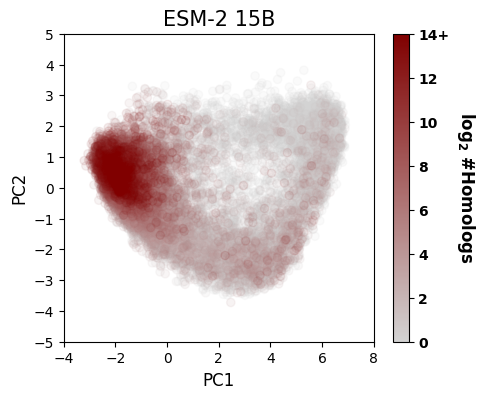

In [174]:

import matplotlib.colors as mcolors

mean_embs_sampled = model_to_sampled_embs[model_of_interest]["mean"]
id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_mean"]

x1 = []
hom_tracker = []
for i, k in enumerate(id_tracker):
    homs = id_to_homologs[k]
    hom_tracker.append(homs)
    x1.append(mean_embs_sampled[i])
    

#         x2.append(mean_embs_sampled[i])
#     else:
       

X = x1 
X = np.asarray(X)

pca = PCA(n_components=2)  # Specify the number of components
pca.fit(X)
embedding = pca.transform(X)


x = embedding[:, 0]
y = embedding[:, 1]


fig, ax = plt.subplots(figsize = (5, 4))

max_cbar= 14
norm = plt.Normalize(vmin=np.min(hom_tracker), vmax=max_cbar)
cmap = mcolors.LinearSegmentedColormap.from_list("my_cbar", ['lightgray', "maroon"])

colors = cmap(norm(hom_tracker))



sorted_indices = np.argsort(hom_tracker)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]
colors_sorted = colors[sorted_indices]


colors_sorted[:, -1] = 0.1  # Set alpha channel directly

sc = ax.scatter(x_sorted, y_sorted, color = colors_sorted)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)  # for colorbar only
sm.set_array([])  # required in some cases
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\mathbf{log_2}$ #Homologs", labelpad=20, fontsize=12, rotation = 270, fontweight = "bold")
ticks = cbar.get_ticks()

# Replace the last tick label with "max specitied value+"
tick_labels = [f"{t:.0f}" for t in ticks]
tick_labels[-1] = str(max_cbar) + "+"


# Set the new tick labels
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels, fontweight = "bold" )

ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())

ax.set_title("ESM-2 15B", fontsize = 15)

ax.set_xlabel("PC1", fontsize = 12)
ax.set_ylabel("PC2", fontsize = 12)



print(len(x_sorted))

25000
25000
25000
25000
25000
25000


Text(0.5, 1.0, 'Mean Pooled Embeddings')

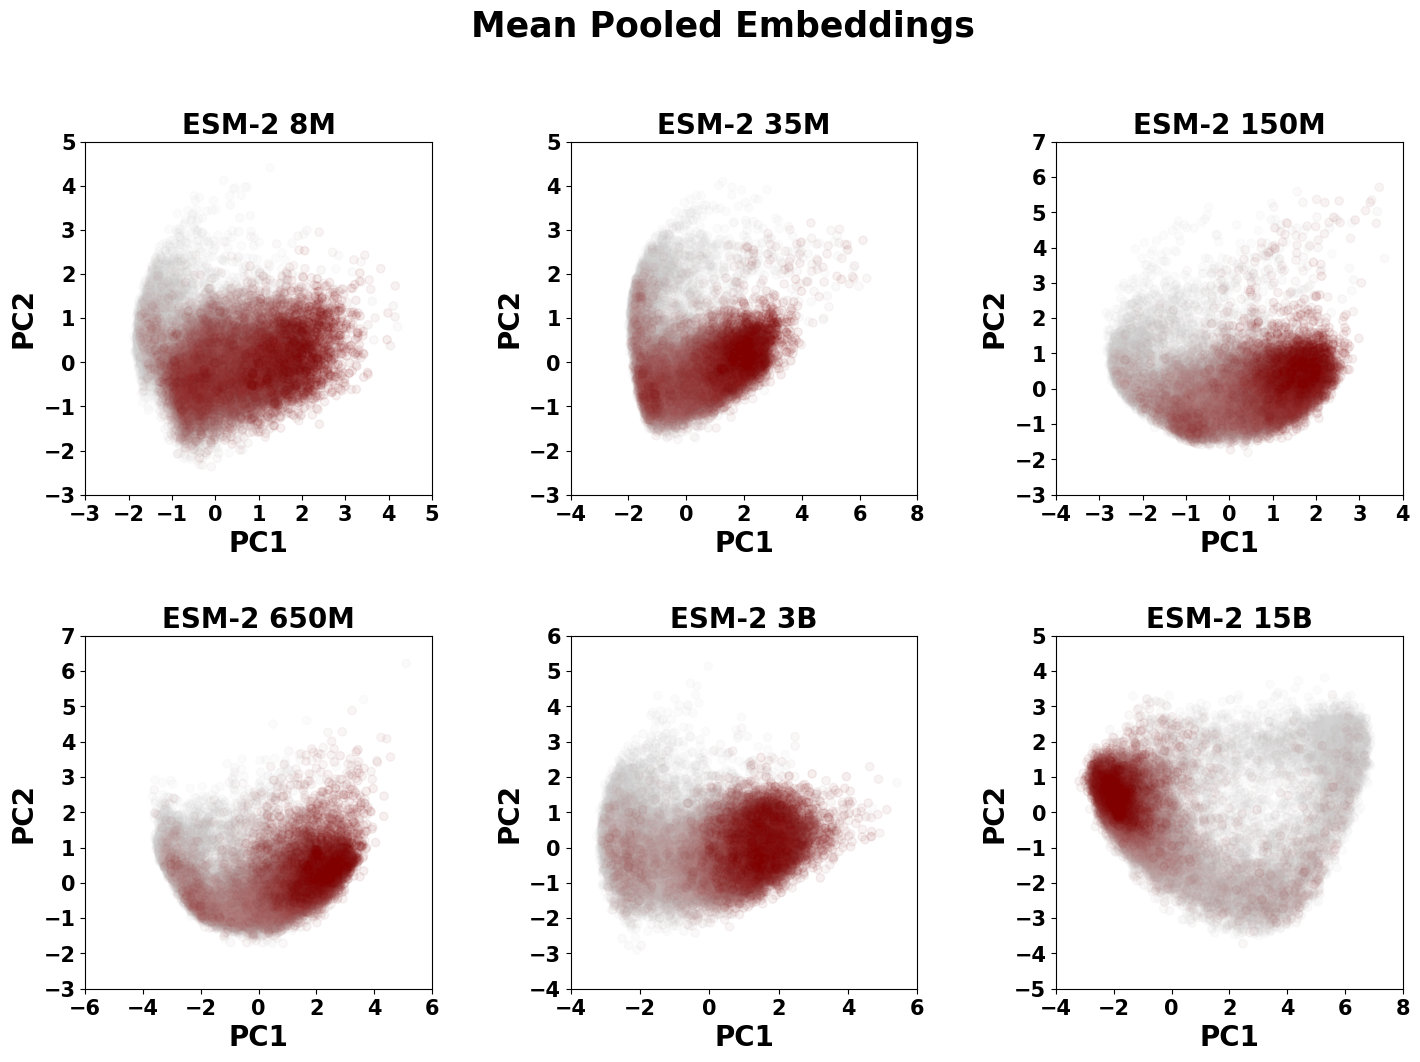

In [175]:
fig, axes = plt.subplots(2,3, figsize = (17, 11))
axes = axes.ravel()
fig.subplots_adjust(wspace = 0.4, hspace = 0.4)

models = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]
labels = ["ESM-2 8M", "ESM-2 35M","ESM-2 150M","ESM-2 650M","ESM-2 3B", "ESM-2 15B",]

for ax_i, (model_of_interest, model_title) in  enumerate(zip(models, labels)):
    mean_embs_sampled = model_to_sampled_embs[model_of_interest]["mean"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_mean"]

    x1 = []
    hom_tracker = []
    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_tracker.append(homs)
        x1.append(mean_embs_sampled[i])

    X = x1 
    X = np.asarray(X)

    pca = PCA(n_components=2)  # Specify the number of components
    pca.fit(X)
    embedding = pca.transform(X)


    x = embedding[:, 0]
    y = embedding[:, 1]

        

    max_cbar= 14
    norm = plt.Normalize(vmin=np.min(hom_tracker), vmax=max_cbar)
    cmap = mcolors.LinearSegmentedColormap.from_list("my_cbar", ['lightgray', "maroon"])

    colors = cmap(norm(hom_tracker))


    ax = axes[ax_i]
    
    sorted_indices = np.argsort(hom_tracker)
    x_sorted = x[sorted_indices]
    y_sorted = y[sorted_indices]
    colors_sorted = colors[sorted_indices]


    colors_sorted[:, -1] = 0.07  # Set alpha channel directly

    sc = ax.scatter(x_sorted, y_sorted, color = colors_sorted)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)  # for colorbar only
    sm.set_array([])  # required in some cases

    ax.set_xticks(ax.get_xticks())
    ax.set_yticks(ax.get_yticks())
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15, fontweight = "bold")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 15, fontweight = "bold")

    ax.set_title(model_title, fontsize = 20, fontweight = "bold")

    ax.set_xlabel("PC1", fontsize = 20, fontweight = "bold")
    ax.set_ylabel("PC2", fontsize = 20, fontweight = "bold")
    
    print(len(x_sorted))

fig.suptitle("Mean Pooled Embeddings", fontsize = 25, y=1.0, fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings')

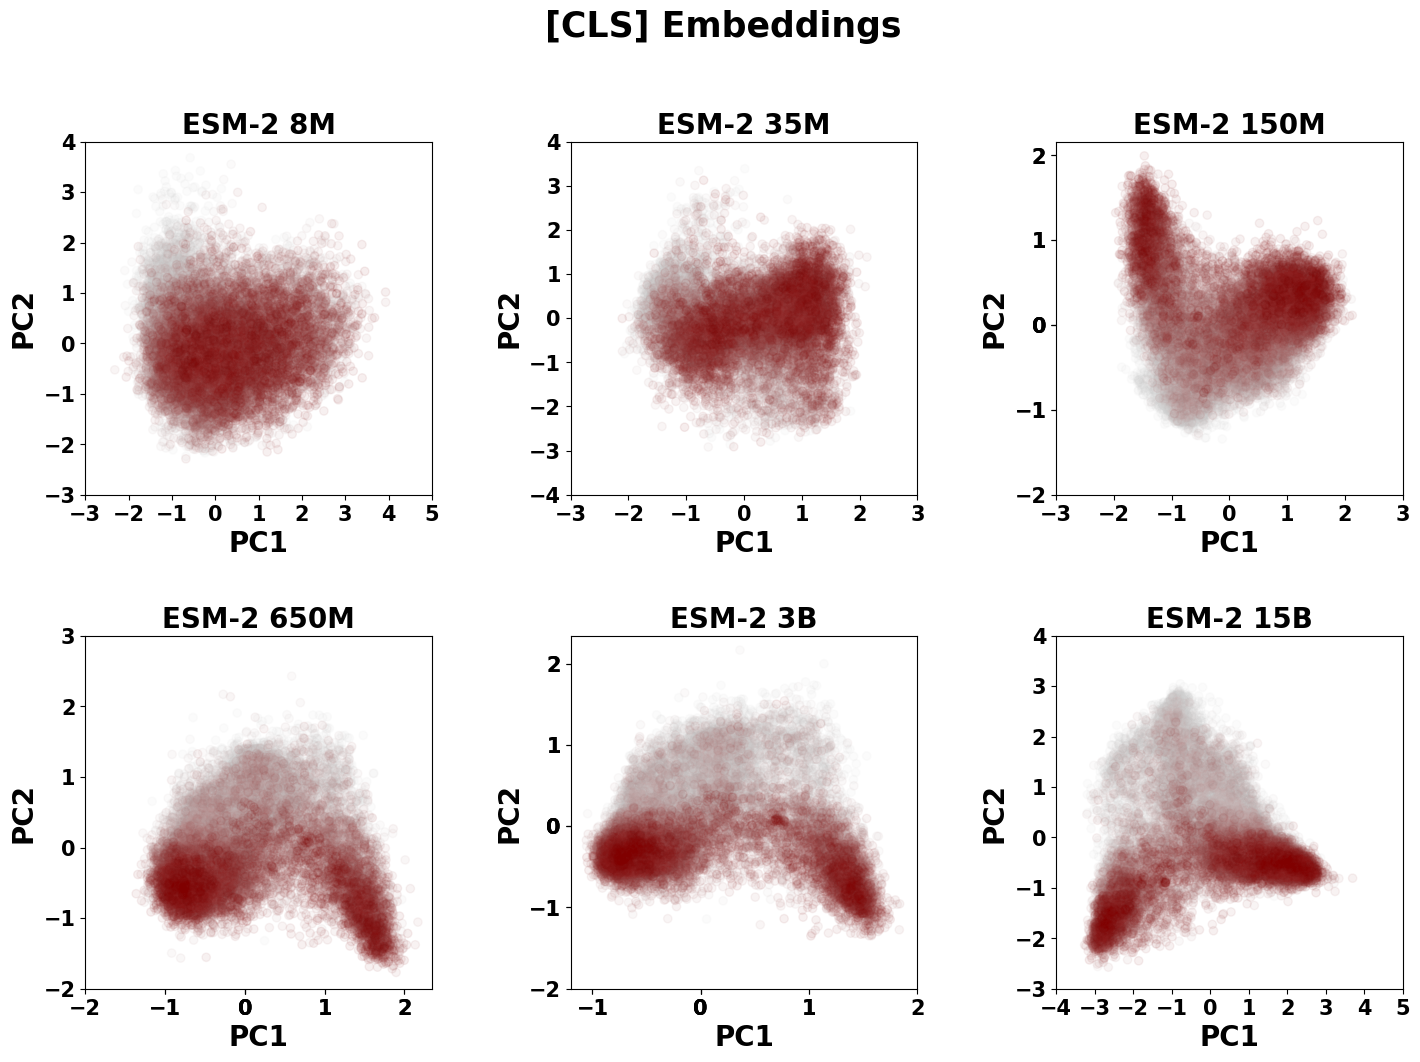

In [176]:
fig, axes = plt.subplots(2,3, figsize = (17, 11))
axes = axes.ravel()
fig.subplots_adjust(wspace = 0.4, hspace = 0.4)

models = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]
labels = ["ESM-2 8M", "ESM-2 35M","ESM-2 150M","ESM-2 650M","ESM-2 3B", "ESM-2 15B",]

for ax_i, (model_of_interest, model_title) in  enumerate(zip(models, labels)):
    mean_embs_sampled = model_to_sampled_embs[model_of_interest]["cls"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_cls"]

    x1 = []
    hom_tracker = []
    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_tracker.append(homs)
        x1.append(mean_embs_sampled[i])

    X = x1 
    X = np.asarray(X)

    pca = PCA(n_components=2)  # Specify the number of components
    pca.fit(X)
    embedding = pca.transform(X)


    x = embedding[:, 0]
    y = embedding[:, 1]

        

    max_cbar= 14
    norm = plt.Normalize(vmin=np.min(hom_tracker), vmax=max_cbar)
    cmap = mcolors.LinearSegmentedColormap.from_list("my_cbar", ['lightgray', "maroon"])

    colors = cmap(norm(hom_tracker))


    ax = axes[ax_i]
    
    sorted_indices = np.argsort(hom_tracker)
    x_sorted = x[sorted_indices]
    y_sorted = y[sorted_indices]
    colors_sorted = colors[sorted_indices]


    colors_sorted[:, -1] = 0.07  # Set alpha channel directly

    sc = ax.scatter(x_sorted, y_sorted, color = colors_sorted)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)  # for colorbar only
    sm.set_array([])  # required in some cases


    ax.set_xticks(list(map(lambda x : int(x), ax.get_xticks())))
    ax.set_yticks(list(map(lambda x : int(x), ax.get_yticks())))
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15, fontweight = "bold")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 15, fontweight = "bold")

    ax.set_title(model_title, fontsize = 20, fontweight = "bold")

    ax.set_xlabel("PC1", fontsize = 20, fontweight = "bold")
    ax.set_ylabel("PC2", fontsize = 20, fontweight = "bold")
    

fig.suptitle("[CLS] Embeddings", fontsize = 25, y=1.0, fontweight = "bold")

In [177]:
pc_correlation_tracker = {"mean": {}, "cls" : {}}

In [178]:
model_to_id_orphanage_dist = {"mean" : {}, "cls" : {}}

display_name_to_key = {
    "ESM-2 (8M)" : "esm_2_8M",
    "ESM-2 (35M)": "esm_2_35M",
    "ESM-2 (150M)": "esm_2_150M",
    "ESM-2 (650M)": "esm_2_650M",
    "ESM-2 (3B)": "esm_2",
    "ESM-2 (15B)" : "esm_2_15B",
}
mean_pool_table = table_vals.loc[table_vals["embedding_type"] == "mean_pooled"]
for model, sub_df in mean_pool_table.groupby("model"):
    key = display_name_to_key[model]
    id_to_distance = dict(zip(sub_df["name"].values, sub_df["orphanage_distance"].values))
    model_to_id_orphanage_dist["mean"][key] = id_to_distance

cls_pool_table = table_vals.loc[table_vals["embedding_type"] == "CLS"]
for model, sub_df in cls_pool_table.groupby("model"):
    key = display_name_to_key[model]
    id_to_distance = dict(zip(sub_df["name"].values, sub_df["orphanage_distance"].values))
    model_to_id_orphanage_dist["cls"][key] = id_to_distance

len( model_to_id_orphanage_dist["cls"][key] )

25000

25000
25000
25000
25000
25000
25000


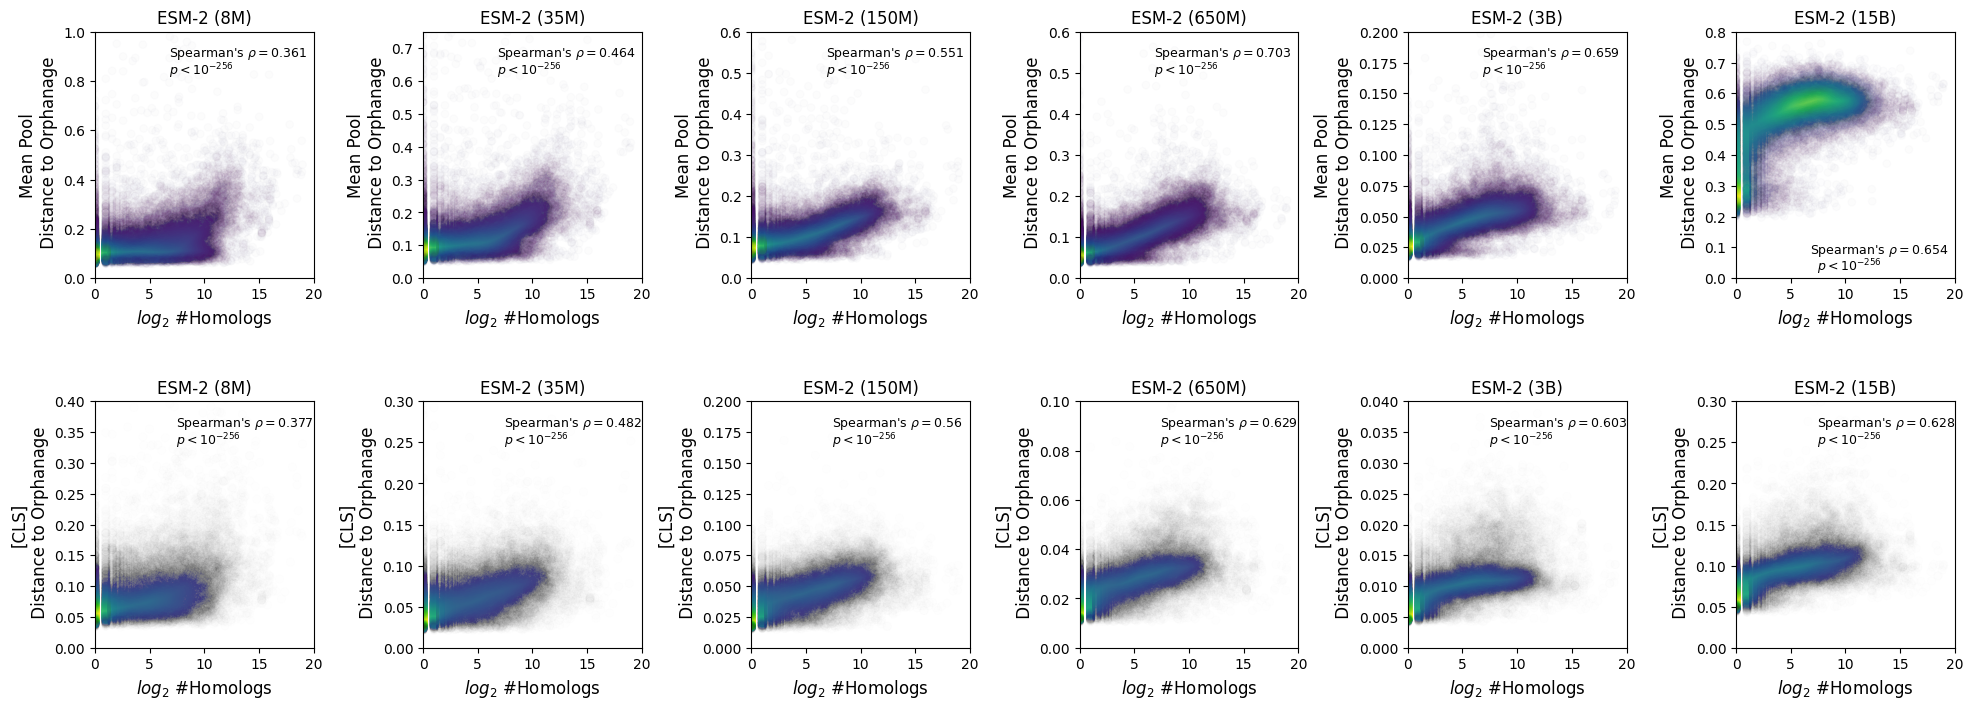

In [179]:
fig, axes = plt.subplots(2,6,figsize = (24, 8))
fig.subplots_adjust(hspace = 0.5, wspace = 0.5)



models = [
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_150M",
    "esm_2_650M",
    "esm_2",
    "esm_2_15B"
]
labels = ["ESM-2 (8M)", "ESM-2 (35M)","ESM-2 (150M)","ESM-2 (650M)","ESM-2 (3B)", "ESM-2 (15B)",]


cls_top_cutoffs = [0.4, 0.3, 0.2,0.1, 0.04, 0.3]
mean_top_cutoffs = [1.0, 0.75, 0.6, 0.6, 0.2, 0.8]

pc_correlation_tracker["mean"]["homs_v_orphanage"] = {}
pc_correlation_tracker["cls"]["homs_v_orphanage"] = {}

for i, model in enumerate(models):
    ax1 = axes[0][i]
    ax2 = axes[1][i]
    
    
    model_table = table_vals.loc[table_vals["model"] == labels[i]]
    
    x1 = model_table.loc[model_table['embedding_type'] == "mean_pooled"]["log_2 UR50 homologs"].values
    y1 = model_table.loc[model_table['embedding_type'] == "mean_pooled"]["orphanage_distance"].values
    
    xy = np.vstack([x1,y1])
    z = gaussian_kde(xy)(xy)
    
    ax1.scatter(x1,y1, s = 30, c = z, alpha = 0.01)
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xlabel("$log_2$ #Homologs", fontsize = 12)
    ax1.set_ylim(bottom = 0., top = mean_top_cutoffs[i])
    ax1.set_title(labels[i])
    ax1.set_ylabel("Mean Pool\n Distance to Orphanage", fontsize = 12)
    corr, p = scipy.stats.spearmanr(x1,y1,)
    pc_correlation_tracker["mean"]["homs_v_orphanage"][model] = {"corr" : corr, "p" : p}
    ax1.set_xlim(left = 0)
    if model == "esm_2_15B":
        ax2.text(0.34, 0.1, r"Spearman's $\rho=$" + str(round(corr, 3)),transform = ax1.transAxes, fontsize = 9)
        ax2.text(0.37, 0.03, r"$p" + format_p(p) + "$",transform = ax1.transAxes, fontsize = 9)
    else:
        ax2.text(0.34, 0.9, r"Spearman's $\rho=$" + str(round(corr, 3)),transform = ax1.transAxes, fontsize = 9)
        ax2.text(0.34, 0.825, r"$p" + format_p(p) + "$",transform = ax1.transAxes, fontsize = 9)
    
    x1 = model_table.loc[model_table['embedding_type'] == "CLS"]["log_2 UR50 homologs"].values
    y1 = model_table.loc[model_table['embedding_type'] == "CLS"]["orphanage_distance"].values
    
    print(len(x1))
    
    xy = np.vstack([x1,y1])
    z = gaussian_kde(xy)(xy)
    ax2.scatter(x1, y1, c = z, alpha = 0.005)
    ax2.set_ylim(bottom = 0., top = cls_top_cutoffs[i])
    ax2.set_xticks(ax2.get_xticks())
    ax2.set_ylabel("[CLS]\n Distance to Orphanage", fontsize = 12)
    ax2.set_xlabel("$log_2$ #Homologs", fontsize = 12)
    ax2.set_title(labels[i])
    corr, p = scipy.stats.spearmanr(x1,y1)
    pc_correlation_tracker["cls"]["homs_v_orphanage"][model] = {"corr" : corr, "p" : p}
    ax2.text(0.37, 0.9, r"Spearman's $\rho=$" + str(round(corr, 3)),transform = ax2.transAxes, fontsize = 9)
    ax2.text(0.37, 0.825, r"$p" + format_p(p) + "$",transform = ax2.transAxes, fontsize = 9)
    ax2.set_xlim(left = 0)

/tmp/ipykernel_21302/3234602303.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(ax1.get_yticklabels(), fontweight = "bold", fontsize = 12)


25000


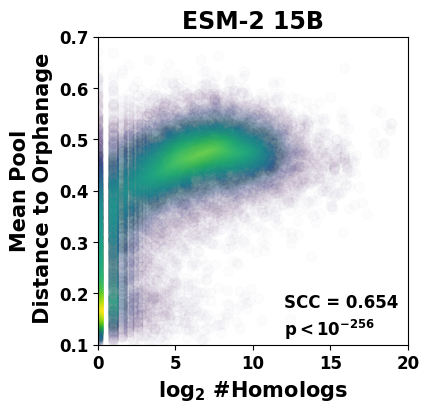

In [180]:
model = "esm_2_15B"

fig, ax1 = plt.subplots(figsize = (4,4))

model_table = table_vals.loc[table_vals["model"] == "ESM-2 (15B)"]
    
x1 = model_table.loc[model_table['embedding_type'] == "mean_pooled"]["log_2 UR50 homologs"].values
y1 = model_table.loc[model_table['embedding_type'] == "mean_pooled"]["orphanage_distance"].values

xy = np.vstack([x1,y1])
z = gaussian_kde(xy)(xy)

ax1.scatter(x1,y1, s = 50, c = z, alpha = 0.01)
ax1.set_xticks(ax1.get_xticks())

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight = "bold", fontsize = 12)
ax1.set_yticklabels(ax1.get_yticklabels(), fontweight = "bold", fontsize = 12)

ax1.set_xlabel("$\mathbf{log_2}$ #Homologs", fontsize = 15, fontweight = "bold")
ax1.set_ylim(bottom = 0.2, top = 0.8)
ax1.set_title("ESM-2 15B", fontsize=17, fontweight = "bold")
ax1.set_ylabel("Mean Pool\n Distance to Orphanage", fontsize = 15, fontweight = "bold")
corr, p = scipy.stats.spearmanr(x1,y1,)
ax1.set_xlim(left = 0)

print(len(x1))

if model == "esm_2_15B":
    ax1.text(0.6, 0.12, "SCC = " + str(round(corr, 3)),transform = ax1.transAxes, fontsize = 12, fontweight = "bold")
    ax1.text(0.6, 0.03, r"$\mathbf{p" + format_p(p) + "}$",transform = ax1.transAxes, fontsize = 12, fontweight = "bold")
else:
    ax1.text(0.4, 0.9, r"Spearman's $\rho=$" + str(round(corr, 3)),transform = ax1.transAxes, fontsize = 12, fontweight = "bold")
    ax1.text(0.4, 0.825, r"$p" + format_p(p) + "$",transform = ax1.transAxes, fontsize = 12, fontweight = "bold")

In [181]:
pc_tracker = {"PC1" : {"mean" : {}, "cls" : {}}, "PC2" :  {"mean" : {}, "cls" : {}}}

esm_2_8M
[0.18652792 0.11252478]
SpearmanrResult(correlation=0.8239361462312844, pvalue=0.0)
esm_2_35M
[0.2405151  0.11353789]
SpearmanrResult(correlation=0.8938131982290419, pvalue=0.0)
esm_2_150M
[0.2548708  0.10840535]
SpearmanrResult(correlation=0.7862612058641077, pvalue=0.0)
esm_2_650M
[0.39466694 0.078298  ]
SpearmanrResult(correlation=0.9080824765441541, pvalue=0.0)
esm_2
[0.30421773 0.08284685]
SpearmanrResult(correlation=0.9069912940442667, pvalue=0.0)
esm_2_15B
[0.21088718 0.04375203]
SpearmanrResult(correlation=-0.9119484100124072, pvalue=0.0)


Text(0.5, 1.05, 'Mean Pooled Embeddings')

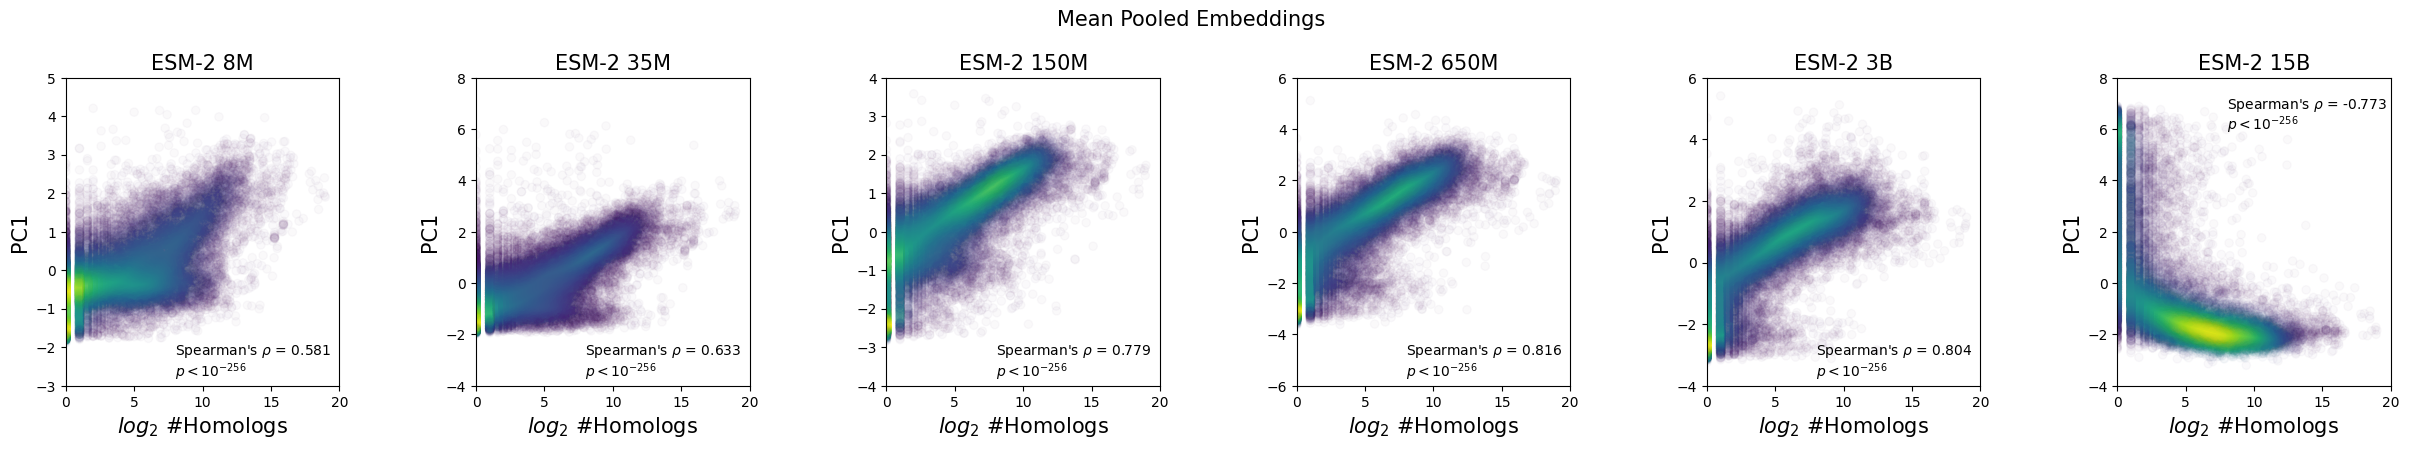

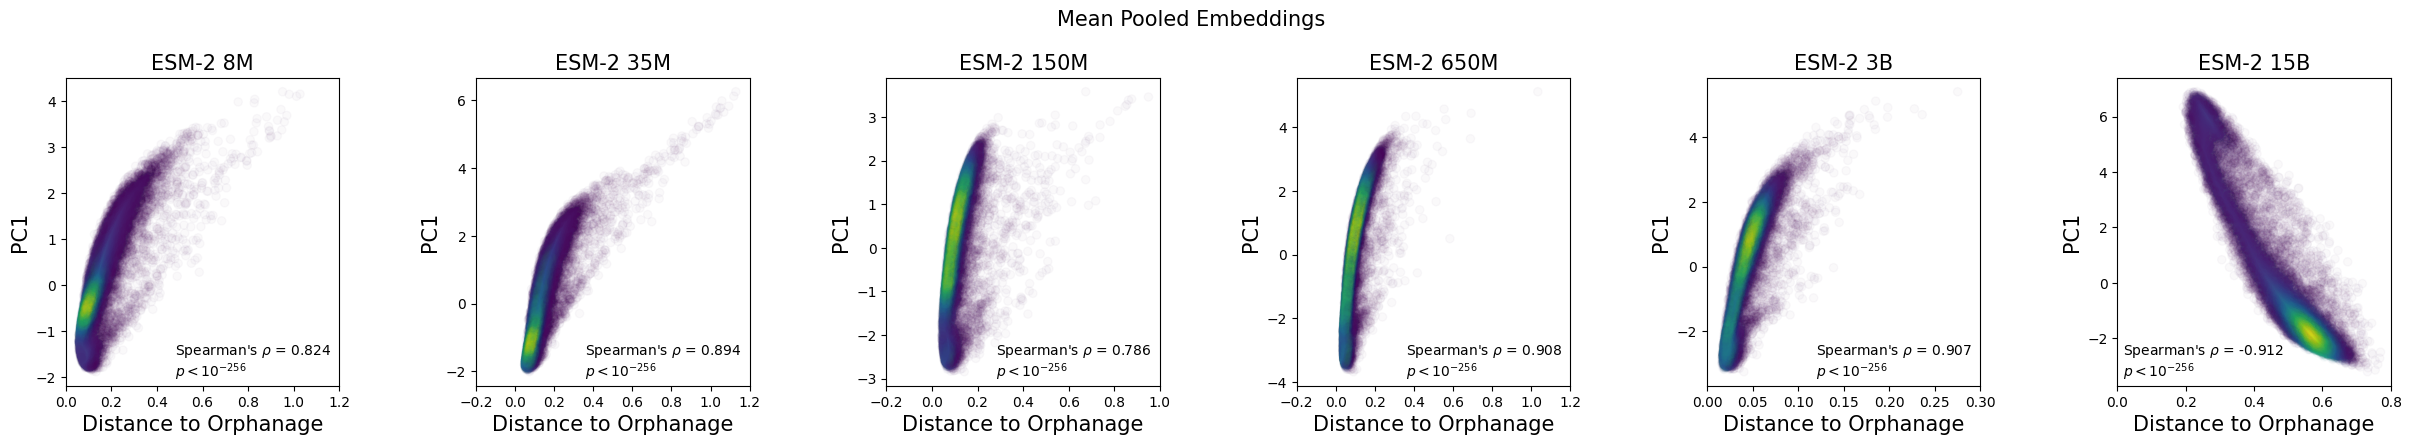

In [182]:
fig, axes = plt.subplots(1,6,figsize = (30, 4))
fig.subplots_adjust(wspace = 0.5)

fig2, axes2 = plt.subplots(1,6,figsize = (30, 4))
fig2.subplots_adjust(wspace = 0.5)

ev_tracker = []
label_tracker = []

pc_correlation_tracker["mean"]["homs_v_PC1"] = {}
pc_correlation_tracker["mean"]["orphanage_dist_v_PC1"] = {}



for ax_i, model_of_interest in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M","esm_2_650M","esm_2","esm_2_15B"]):
    print(model_of_interest)
    mean_embs_sampled = model_to_sampled_embs[model_of_interest]["mean"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_mean"]

    hom_list = []
    orphanage_dist = []
    orphanage_dist_key = model_to_id_orphanage_dist["mean"][model_of_interest]

    X = []
    
    id_list = []

    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_list.append(homs)
        id_list.append(k)
        X.append(mean_embs_sampled[i])
        orphanage_dist.append(orphanage_dist_key[k])

    X = np.asarray(X)

    pca = PCA(n_components=2, random_state=2025)  # Specify the number of components
    pca.fit(X)
    print(pca.explained_variance_ratio_)
    
    model_label = model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest]
    ev_tracker.append(pca.explained_variance_ratio_)
    label_tracker.append(model_label)
    embedding = pca.transform(X)

    dim_1 = embedding[:,0]
    
    pc_tracker["PC1"]["mean"][model_label] = dict(zip(id_list, dim_1))
    
    ax = axes[ax_i]
    
    xy = np.vstack([hom_list, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(hom_list, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(hom_list, dim_1)
    
    pc_correlation_tracker["mean"]["homs_v_PC1"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("$log_2$ #Homologs", fontsize = 15)
    ax.set_ylabel("PC1", fontsize = 15)
    ax.set_xticks([0,5,10,15,20])
    ax.set_xlim(left = 0, right = 20)
    ax.set_yticks(ax.get_yticks())
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
        
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
        
    if model_of_interest == "esm_2_15B":
        ax.text(0.4, 0.9,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.83, p_string, transform = ax.transAxes)
        
            
#         ax.text(0.6, 0.9, "Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    else:
        ax.text(0.4, 0.1, r"Spearman's $\rho$ = "  + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    
    print(scipy.stats.spearmanr(orphanage_dist, dim_1))
    
    ax = axes2[ax_i]
    
    xy = np.vstack([orphanage_dist, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(orphanage_dist, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(orphanage_dist, dim_1)
    pc_correlation_tracker["mean"]["orphanage_dist_v_PC1"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("Distance to Orphanage", fontsize = 15)
    ax.set_ylabel("PC1", fontsize = 15)
    ax.set_xticks(ax.get_xticks())
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
        
    if model_of_interest == "esm_2_15B":
        ax.text(0.02, 0.1,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.02,0.03, p_string, transform = ax.transAxes)
        
            
#         ax.text(0.6, 0.9, "Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    else:
        ax.text(0.4, 0.1, r"Spearman's $\rho$ = "  + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    
        
fig.suptitle("Mean Pooled Embeddings", y = 1.05, fontsize = 15)
fig2.suptitle("Mean Pooled Embeddings", y = 1.05, fontsize = 15)


25000


/tmp/ipykernel_21302/3977892821.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold", fontsize = 12)
/tmp/ipykernel_21302/3977892821.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", fontsize = 12)


Text(0.6, 0.82, '$\\mathbf{p < 10^{-256}}$')

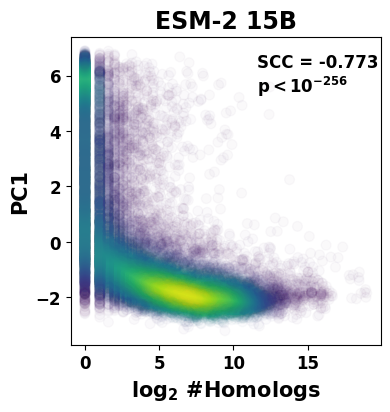

In [183]:
model = "esm_2_15B"

fig, ax = plt.subplots(figsize = (4,4))

mean_embs_sampled = model_to_sampled_embs[model]["mean"]
id_tracker = model_to_sampled_embs[model]["id_tracker_mean"]

hom_list = []
orphanage_dist = []
orphanage_dist_key = model_to_id_orphanage_dist["mean"][model]

X = []

for i, k in enumerate(id_tracker):
    homs = id_to_homologs[k]
    hom_list.append(homs)
    X.append(mean_embs_sampled[i])
    orphanage_dist.append(orphanage_dist_key[k])

X = np.asarray(X)

pca = PCA(n_components=2, random_state=2025)  # Specify the number of components
pca.fit(X)
embedding = pca.transform(X)

dim_1 = embedding[:,0]

xy = np.vstack([hom_list, dim_1])
z = gaussian_kde(xy)(xy)

ax.scatter(hom_list, dim_1, c = z, s = 50, cmap = "viridis", alpha = 0.022)

corr, p = scipy.stats.spearmanr(hom_list, dim_1)

ax.set_xlabel("$\mathbf{log_2}$ #Homologs", fontsize = 15, fontweight = "bold")
ax.set_ylabel("PC1", fontsize = 15, fontweight = "bold")


ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold", fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", fontsize = 12)


print(len(hom_list))

ax.set_title(model_to_base_string[model] + " " + model_to_params_string[model], fontsize = 17, fontweight = "bold")
if p < 10**(-256):
    p_string = r"$\mathbf{p < 10^{-256}}$"
else:
    p_string = r"p = $\mathbf{" + format_p(p) + "}$"

ax.text(0.6, 0.9, "SCC = " + str(round(corr, 3)), transform = ax.transAxes, fontsize = 12, fontweight = "bold")
ax.text(0.6, 0.82, p_string, transform = ax.transAxes, fontsize = 12, fontweight = "bold")

Text(0.6, 0.82, '$\\mathbf{p < 10^{-256}}$')

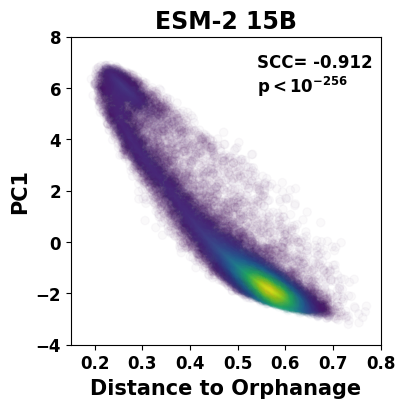

In [184]:
fig, ax = plt.subplots(figsize = (4,4))

xy = np.vstack([orphanage_dist, dim_1])
z = gaussian_kde(xy)(xy)

ax.scatter(orphanage_dist, dim_1, c = z, cmap = "viridis", alpha = 0.022)

corr, p = scipy.stats.spearmanr(orphanage_dist, dim_1)

ax.set_xlabel("Distance to Orphanage", fontsize = 15, fontweight = "bold")
ax.set_ylabel("PC1", fontsize = 15, fontweight = "bold")
ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())


ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold", fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", fontsize = 12)

ax.set_title("ESM-2 15B", fontsize = 17,fontweight = "bold")
if p < 10**(-256):
    p_string = r"$\mathbf{p < 10^{-256}}$"
else:
    p_string = r"p = $\mathbf{" + format_p(p) + "}$"

ax.set_xlim(left = 0.15, right = 0.8)
ax.text(0.6, 0.9,r"SCC= " + str(round(corr, 3)), transform = ax.transAxes, fontsize = 12, fontweight = "bold")
ax.text(0.6,0.82, p_string, transform = ax.transAxes, fontsize = 12, fontweight = "bold")

esm_2_8M
[0.18652792 0.11252478]
SpearmanrResult(correlation=0.14007462676945318, pvalue=9.770421266287944e-110)
esm_2_35M
[0.2405151  0.11353789]
SpearmanrResult(correlation=0.12485020544172806, pvalue=2.1179506844940817e-87)
esm_2_150M
[0.2548708  0.10840535]
SpearmanrResult(correlation=0.4486997044353029, pvalue=0.0)
esm_2_650M
[0.39466694 0.078298  ]
SpearmanrResult(correlation=0.23768078261949344, pvalue=0.0)
esm_2
[0.30421773 0.08284685]
SpearmanrResult(correlation=0.13741994176117267, pvalue=1.18976964787356e-105)
esm_2_15B
[0.21088718 0.04375203]
SpearmanrResult(correlation=0.26025253597628395, pvalue=0.0)


Text(0.5, 1.05, 'Mean Pooled Embeddings')

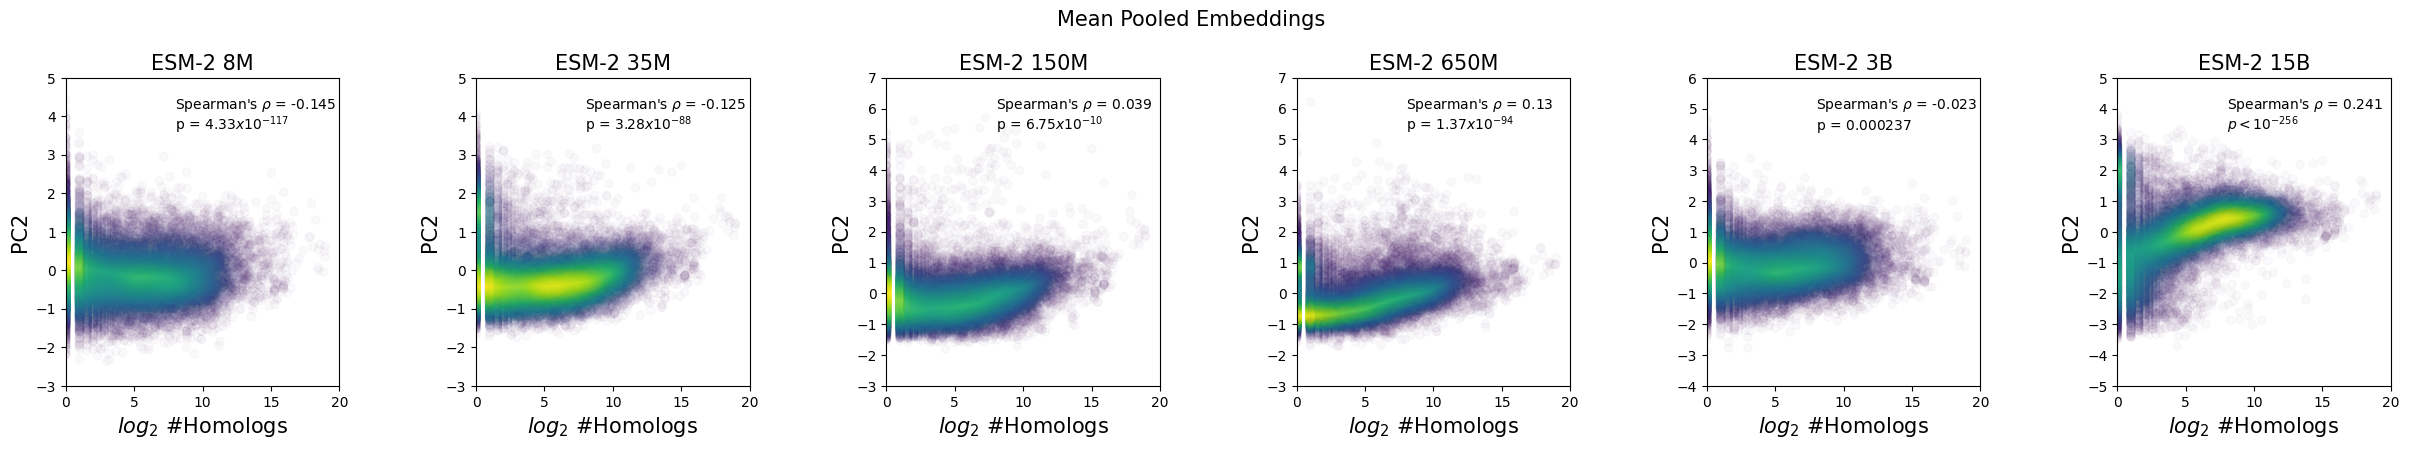

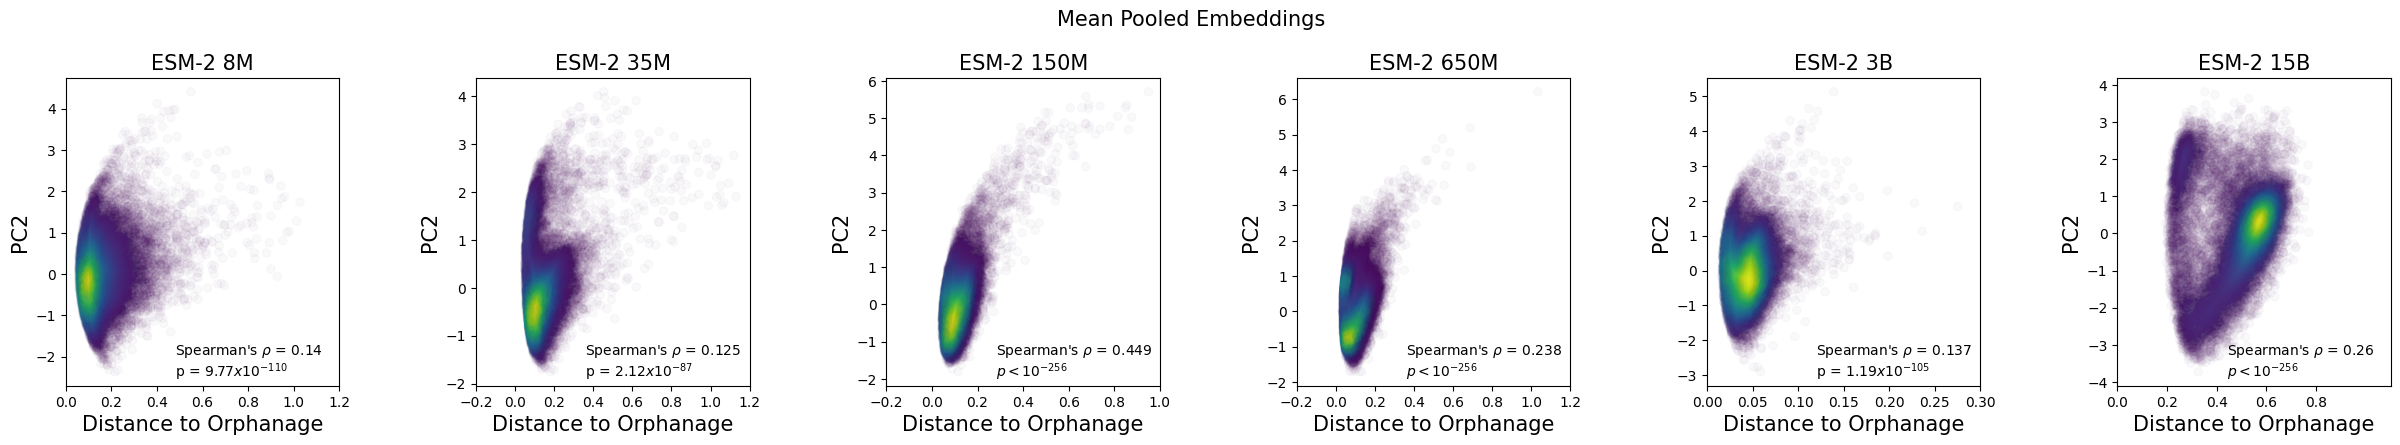

In [185]:
fig, axes = plt.subplots(1,6,figsize = (30, 4))
fig.subplots_adjust(wspace = 0.5)

fig2, axes2 = plt.subplots(1,6,figsize = (30, 4))
fig2.subplots_adjust(wspace = 0.5)

ev_tracker = []
label_tracker = []

pc_correlation_tracker["mean"]["homs_v_PC2"] = {}
pc_correlation_tracker["mean"]["orphanage_dist_v_PC2"] = {}

for ax_i, model_of_interest in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M","esm_2_650M","esm_2","esm_2_15B"]):
    print(model_of_interest)
    mean_embs_sampled = model_to_sampled_embs[model_of_interest]["mean"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_mean"]

    hom_list = []
    orphanage_dist = []
    orphanage_dist_key = model_to_id_orphanage_dist["mean"][model_of_interest]

    X = []
    id_list = []
    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_list.append(homs)
        id_list.append(k)
        X.append(mean_embs_sampled[i])
        orphanage_dist.append(orphanage_dist_key[k])

    X = np.asarray(X)

    pca = PCA(n_components=2, random_state=2025)  # Specify the number of components
    pca.fit(X)
    print(pca.explained_variance_ratio_)
    
    model_label = model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest]
    ev_tracker.append(pca.explained_variance_ratio_)
    label_tracker.append(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest])
    embedding = pca.transform(X)

    dim_1 = embedding[:, 1]
    
    pc_tracker["PC2"]["mean"][model_label] = dict(zip(id_list, dim_1))
    
    ax = axes[ax_i]
    
    xy = np.vstack([hom_list, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(hom_list, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(hom_list, dim_1)
    
    pc_correlation_tracker["mean"]["homs_v_PC2"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("$log_2$ #Homologs", fontsize = 15)
    ax.set_ylabel("PC2", fontsize = 15)
    ax.set_xticks([0,5,10,15,20])
    ax.set_xlim(left = 0, right = 20)
    ax.set_yticks(ax.get_yticks())
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
        
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
        
    ax.text(0.4, 0.9,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    ax.text(0.4,0.83, p_string, transform = ax.transAxes)
        
    
    print(scipy.stats.spearmanr(orphanage_dist, dim_1))
    
    ax = axes2[ax_i]
    
    xy = np.vstack([orphanage_dist, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(orphanage_dist, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(orphanage_dist, dim_1)
    pc_correlation_tracker["mean"]["orphanage_dist_v_PC2"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("Distance to Orphanage", fontsize = 15)
    ax.set_ylabel("PC2", fontsize = 15)
    ax.set_xticks(ax.get_xticks())
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
        
    
    
    if model_of_interest == "esm_2_15B":
        ax.set_xlim(right = 1.1)
        
        ax.text(0.4, 0.1,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    else:
       
        ax.text(0.4, 0.1,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
        
        
        
fig.suptitle("Mean Pooled Embeddings", y = 1.05, fontsize = 15)
fig2.suptitle("Mean Pooled Embeddings", y = 1.05, fontsize = 15)

Text(0.5, 0.98, 'Mean Pooled Embeddings')

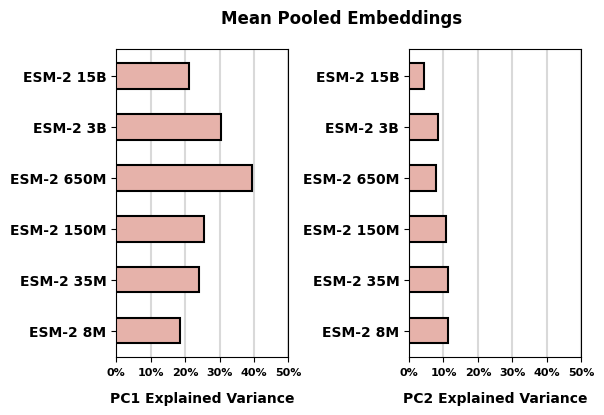

In [186]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (6,4))
fig.subplots_adjust(wspace = 0.7)


ax = ax1

y = list(range(len(ev_tracker)))

x = list(map(lambda x : x[0], ev_tracker))



ax.barh(y, x, height = 0.5, color = "#e6b2aa", zorder = 100, linewidth = 1.5, edgecolor = "black")

ax.set_yticks(y)
ax.set_yticklabels(label_tracker, fontsize = 10, fontweight = "bold",)

ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5])
ax.set_xticklabels(list(map(lambda x : str(int(round(x, 2) * 100)) + "%" , ax.get_xticks())), fontsize = 8,fontweight = "bold",)
ax.set_xlabel("PC1 Explained Variance", labelpad = 10, fontsize = 10, fontweight = "bold")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, color = "black", alpha = 0.15, zorder = 1)
    
    
ax = ax2

y = list(range(len(ev_tracker)))

x = list(map(lambda x : x[1], ev_tracker))



ax.barh(y, x, height = 0.5, color = "#e6b2aa", zorder = 100, linewidth = 1.5, edgecolor = "black")

ax.set_yticks(y)
ax.set_yticklabels(label_tracker, fontsize = 10, fontweight = "bold")

ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5])
ax.set_xticklabels(list(map(lambda x : str(int(round(x, 2) * 100)) + "%" , ax.get_xticks())), fontsize = 8, fontweight = "bold")
ax.set_xlabel("PC2 Explained Variance", labelpad = 10, fontsize = 10, fontweight = "bold")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, color = "black", alpha = 0.15, zorder = 1)
    
fig.suptitle("Mean Pooled Embeddings", fontweight = "bold")

esm_2_8M
[0.15489905 0.09143217]
SpearmanrResult(correlation=0.5088674069626815, pvalue=0.0)
25000
esm_2_35M
[0.16278403 0.10242365]
SpearmanrResult(correlation=0.6396038460697402, pvalue=0.0)
25000
esm_2_150M
[0.2193454  0.08344916]
SpearmanrResult(correlation=0.5478471194319982, pvalue=0.0)
25000
esm_2_650M
[0.22183454 0.1670969 ]
SpearmanrResult(correlation=-0.14155054632814795, pvalue=4.824487490823006e-112)
25000
esm_2
[0.20425357 0.12002384]
SpearmanrResult(correlation=0.01579197894563568, pvalue=0.012526239634563032)
25000
esm_2_15B
[0.1856252  0.09223662]
SpearmanrResult(correlation=0.13065064762203046, pvalue=1.3427297647973029e-95)
25000


Text(0.5, 1.05, '[CLS] Embeddings')

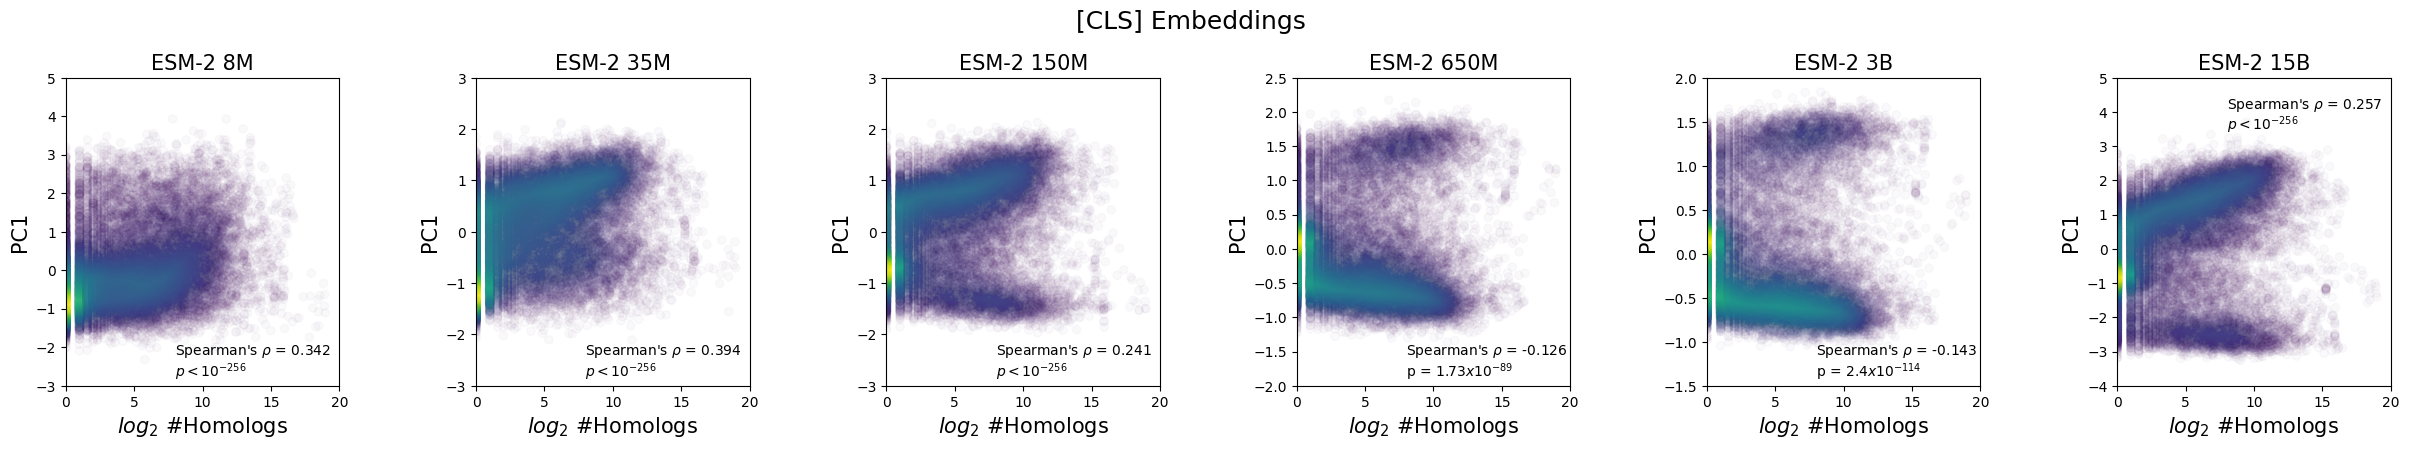

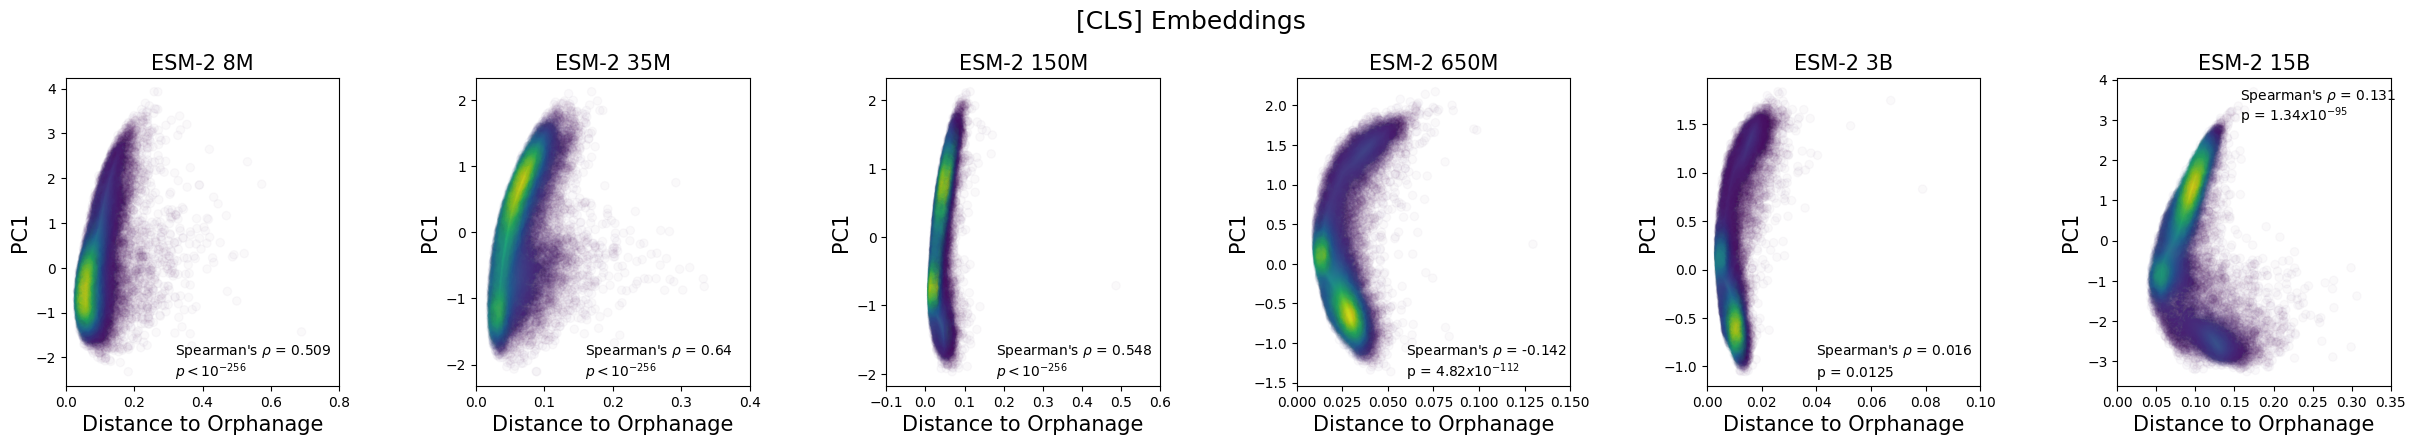

In [187]:
fig, axes = plt.subplots(1,6,figsize = (30, 4))
fig.subplots_adjust(wspace = 0.5)

fig2, axes2 = plt.subplots(1,6,figsize = (30, 4))
fig2.subplots_adjust(wspace = 0.5)

ev_tracker = []
label_tracker = []

pc_correlation_tracker["cls"]["homs_v_PC1"] = {}
pc_correlation_tracker["cls"]["orphanage_dist_v_PC1"] = {}

for ax_i, model_of_interest in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M","esm_2_650M","esm_2","esm_2_15B"]):
    print(model_of_interest)
    cls_embs_sampled = model_to_sampled_embs[model_of_interest]["cls"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_cls"]

    hom_list = []
    orphanage_dist = []
    orphanage_dist_key = model_to_id_orphanage_dist["cls"][model_of_interest]

    X = []
    id_list = []
    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_list.append(homs)
        X.append(cls_embs_sampled[i])
        id_list.append(k)
        orphanage_dist.append(orphanage_dist_key[k])

    X = np.asarray(X)

    pca = PCA(n_components=2, random_state=2025)  # Specify the number of components
    pca.fit(X)
    print(pca.explained_variance_ratio_)
    
    model_label = model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest]
    ev_tracker.append(pca.explained_variance_ratio_)
    label_tracker.append(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest])
    embedding = pca.transform(X)

    dim_1 = embedding[:,0]
    
    model_label = model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest]
    
    pc_tracker["PC1"]["cls"][model_label] = dict(zip(id_list, dim_1))
    
    ax = axes[ax_i]
    
    xy = np.vstack([hom_list, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(hom_list, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(hom_list, dim_1)
    
    pc_correlation_tracker["cls"]["homs_v_PC1"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("$log_2$ #Homologs", fontsize = 15)
    ax.set_ylabel("PC1", fontsize = 15)
    ax.set_xticks([0,5,10,15,20])
    ax.set_xlim(left = 0, right = 20)
    ax.set_yticks(ax.get_yticks())
    
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    if model_of_interest == "esm_2_15B":
        ax.text(0.4, 0.9,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.83, p_string, transform = ax.transAxes)
    else:
        ax.text(0.4, 0.1, r"Spearman's $\rho$ = "  + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    
    print(scipy.stats.spearmanr(orphanage_dist, dim_1))
    
    ax = axes2[ax_i]
    
    xy = np.vstack([orphanage_dist, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(orphanage_dist, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    print(len(orphanage_dist))
    
    corr, p = scipy.stats.spearmanr(orphanage_dist, dim_1)
    pc_correlation_tracker["cls"]["orphanage_dist_v_PC1"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("Distance to Orphanage", fontsize = 15)
    ax.set_ylabel("PC1", fontsize = 15)
    ax.set_xticks(ax.get_xticks())
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
        
    if model_of_interest == "esm_2_15B":
        ax.text(0.45, 0.93,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.45,0.86, p_string, transform = ax.transAxes)
            
#         ax.text(0.6, 0.9, "Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    else:
        ax.text(0.4, 0.1, r"Spearman's $\rho$ = "  + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    
        
fig.suptitle("[CLS] Embeddings", fontsize = 18, y = 1.05)
fig2.suptitle("[CLS] Embeddings", fontsize = 18, y = 1.05)

esm_2_8M
[0.15489905 0.09143217]
SpearmanrResult(correlation=0.03446815968256091, pvalue=5.0019325749303974e-08)
25000
esm_2_35M
[0.16278403 0.10242365]
SpearmanrResult(correlation=0.028630987677069064, pvalue=5.964089832894378e-06)
25000
esm_2_150M
[0.2193454  0.08344916]
SpearmanrResult(correlation=0.6715033483692598, pvalue=0.0)
25000
esm_2_650M
[0.22183454 0.1670969 ]
SpearmanrResult(correlation=-0.8794195941319244, pvalue=0.0)
25000
esm_2
[0.20425357 0.12002384]
SpearmanrResult(correlation=-0.8449938800374139, pvalue=0.0)
25000
esm_2_15B
[0.1856252  0.09223662]
SpearmanrResult(correlation=-0.9005383532739628, pvalue=0.0)
25000


Text(0.5, 1.05, '[CLS] Embeddings')

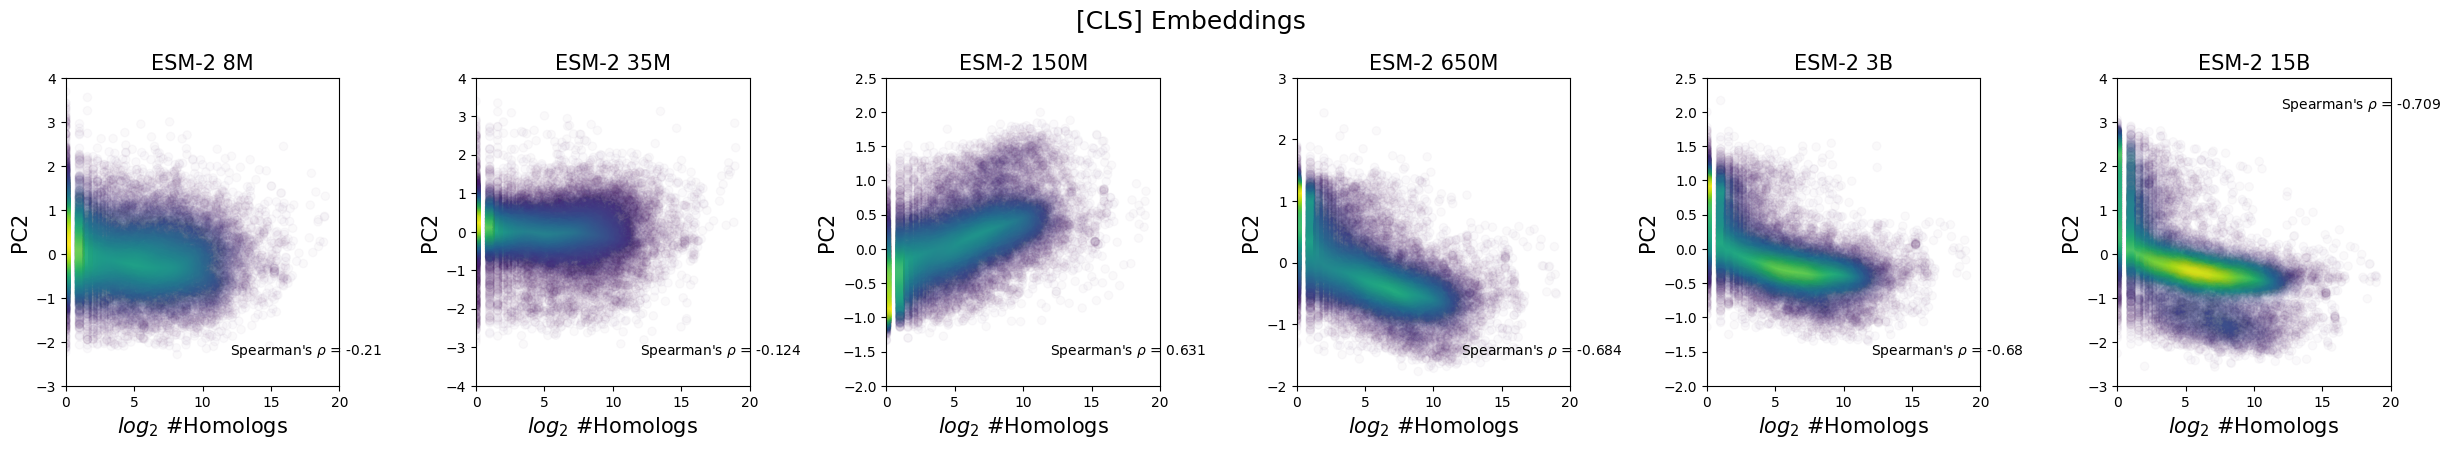

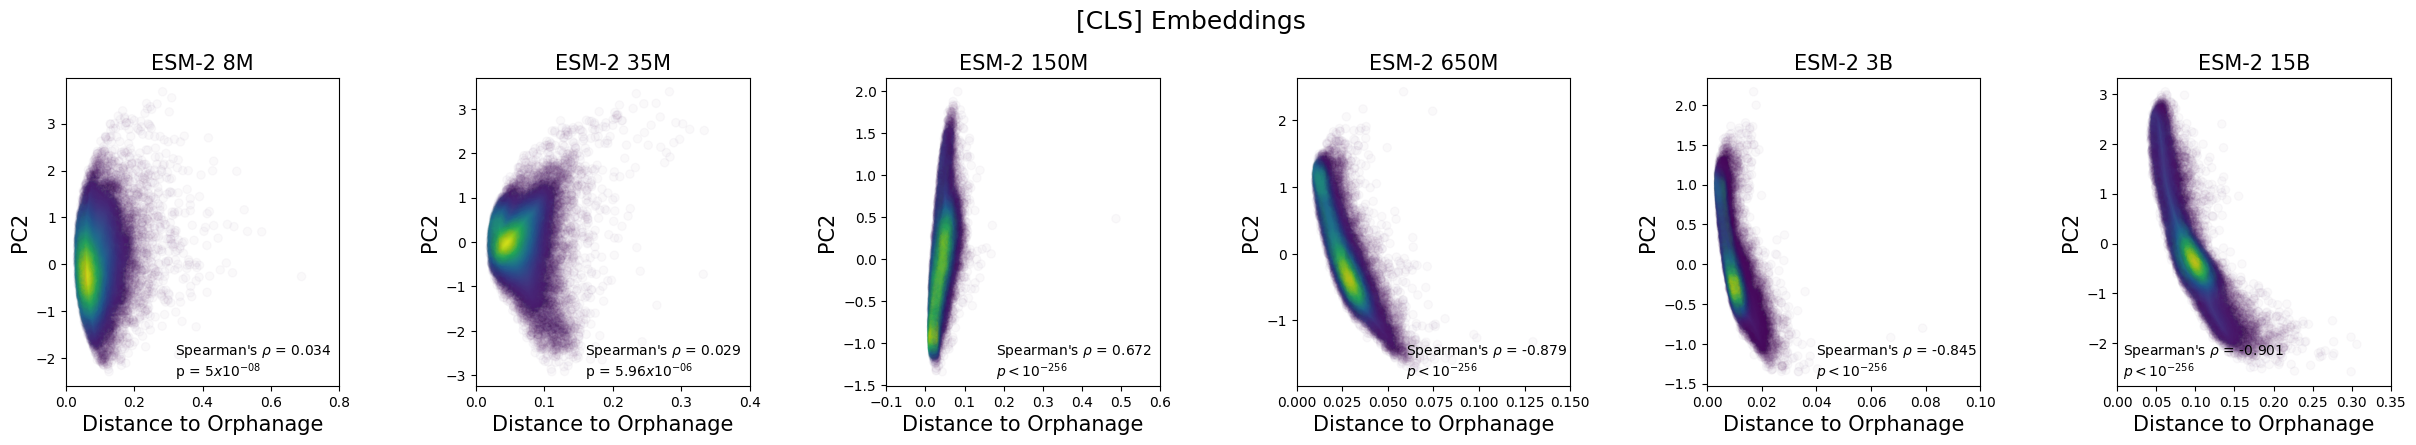

In [188]:
fig, axes = plt.subplots(1,6,figsize = (30, 4))
fig.subplots_adjust(wspace = 0.5)

fig2, axes2 = plt.subplots(1,6,figsize = (30, 4))
fig2.subplots_adjust(wspace = 0.5)

ev_tracker = []
label_tracker = []

pc_correlation_tracker["cls"]["homs_v_PC2"] = {}
pc_correlation_tracker["cls"]["orphanage_dist_v_PC2"] = {}

for ax_i, model_of_interest in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M","esm_2_650M","esm_2","esm_2_15B"]):
    print(model_of_interest)
    cls_embs_sampled = model_to_sampled_embs[model_of_interest]["cls"]
    id_tracker = model_to_sampled_embs[model_of_interest]["id_tracker_cls"]

    hom_list = []
    orphanage_dist = []
    orphanage_dist_key = model_to_id_orphanage_dist["cls"][model_of_interest]

    X = []
    id_list = []
    for i, k in enumerate(id_tracker):
        homs = id_to_homologs[k]
        hom_list.append(homs)
        id_list.append(k)
        X.append(cls_embs_sampled[i])
        orphanage_dist.append(orphanage_dist_key[k])

    X = np.asarray(X)

    pca = PCA(n_components=2, random_state=2025)  # Specify the number of components
    pca.fit(X)
    print(pca.explained_variance_ratio_)
    
    ev_tracker.append(pca.explained_variance_ratio_)
    label_tracker.append(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest])
    embedding = pca.transform(X)

    dim_1 = embedding[:,1]
    
    model_label = model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest]
    
    pc_tracker["PC2"]["cls"][model_label] = dict(zip(id_list, dim_1))
    
    ax = axes[ax_i]
    
    xy = np.vstack([hom_list, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(hom_list, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(hom_list, dim_1)
    pc_correlation_tracker["cls"]["homs_v_PC2"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("$log_2$ #Homologs", fontsize = 15)
    ax.set_ylabel("PC2", fontsize = 15)
    ax.set_xticks([0,5,10,15,20])
    ax.set_xlim(left = 0, right = 20)
    ax.set_yticks(ax.get_yticks())
    
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    if model_of_interest == "esm_2_15B":
        ax.text(0.6, 0.9, r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    else:
        ax.text(0.6, 0.1, r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    
    print(scipy.stats.spearmanr(orphanage_dist, dim_1))
    
    ax = axes2[ax_i]
    
    xy = np.vstack([orphanage_dist, dim_1])
    z = gaussian_kde(xy)(xy)
    
    ax.scatter(orphanage_dist, dim_1, c = z, cmap = "viridis", alpha = 0.022)
    
    corr, p = scipy.stats.spearmanr(orphanage_dist, dim_1)
    
    print(len(orphanage_dist))
    pc_correlation_tracker["cls"]["orphanage_dist_v_PC2"][model_of_interest] = {"corr" : corr, "p" : p}
    
    ax.set_xlabel("Distance to Orphanage", fontsize = 15)
    ax.set_ylabel("PC2", fontsize = 15)
    ax.set_xticks(ax.get_xticks())
    
    if p < 10**(-256):
        p_string = r"$p < 10^{-256}$"
    else:
        p_string = r"p = $" + format_p(p) + "$"
    
    ax.set_title(model_to_base_string[model_of_interest] + " " + model_to_params_string[model_of_interest], fontsize = 15)
    
        
    if model_of_interest == "esm_2_15B":
        ax.text(0.02, 0.1,r"Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.02,0.03, p_string, transform = ax.transAxes)
            
#         ax.text(0.6, 0.9, "Spearman's $\rho$ = " + str(round(corr, 3)), transform = ax.transAxes)
    else:
        ax.text(0.4, 0.1, r"Spearman's $\rho$ = "  + str(round(corr, 3)), transform = ax.transAxes)
        ax.text(0.4,0.03, p_string, transform = ax.transAxes)
    
        
fig.suptitle("[CLS] Embeddings", fontsize = 18, y = 1.05)
fig2.suptitle("[CLS] Embeddings", fontsize = 18, y = 1.05)

Text(0.5, 0.98, '[CLS] Embeddings')

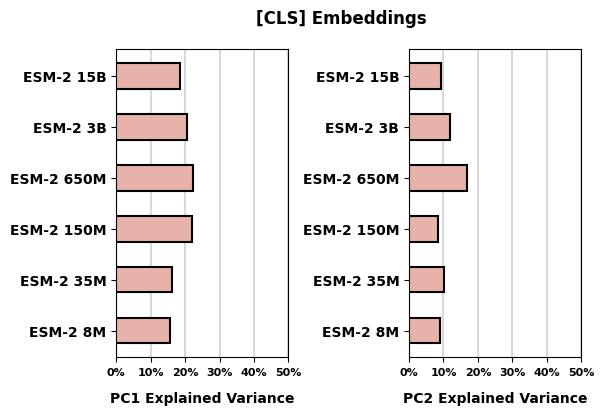

In [189]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (6,4))
fig.subplots_adjust(wspace = 0.7)


ax = ax1

y = list(range(len(ev_tracker)))

x = list(map(lambda x : x[0], ev_tracker))



ax.barh(y, x, height = 0.5, color = "#e6b2aa", zorder = 100, linewidth = 1.5, edgecolor = "black")

ax.set_yticks(y)
ax.set_yticklabels(label_tracker, fontsize = 10, fontweight = "bold")

ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5])
ax.set_xticklabels(list(map(lambda x : str(int(round(x, 2) * 100)) + "%" , ax.get_xticks())), fontsize = 8, fontweight = "bold")
ax.set_xlabel("PC1 Explained Variance", labelpad = 10, fontsize = 10, fontweight = "bold")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, color = "black", alpha = 0.15, zorder = 1)
    
    
ax = ax2

y = list(range(len(ev_tracker)))

x = list(map(lambda x : x[1], ev_tracker))



ax.barh(y, x, height = 0.5, color = "#e6b2aa", zorder = 100, linewidth = 1.5, edgecolor = "black")

ax.set_yticks(y)
ax.set_yticklabels(label_tracker, fontsize = 10, fontweight = "bold")

ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5])
ax.set_xticklabels(list(map(lambda x : str(int(round(x, 2) * 100)) + "%" , ax.get_xticks())), fontsize = 8, fontweight = "bold")
ax.set_xlabel("PC2 Explained Variance", labelpad = 10, fontsize = 10, fontweight = "bold")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, color = "black", alpha = 0.15, zorder = 1)
    
fig.suptitle("[CLS] Embeddings", fontweight = "bold")

In [190]:
key_to_label_2 = {
    "esm_2_8M" : "ESM-2\n8M",
    "esm_2_35M" : "ESM-2\n35M",
    "esm_2_150M" : "ESM-2\n150M",
    "esm_2_650M" : "ESM-2\n650M",
    "esm_2" : "ESM-2\n3B",
    "esm_2_15B" : "ESM-2\n15B",
}
pc_correlation_tracker["mean"].keys()

dict_keys(['homs_v_orphanage', 'homs_v_PC1', 'orphanage_dist_v_PC1', 'homs_v_PC2', 'orphanage_dist_v_PC2'])

Text(0.5, 1.0, 'Mean Pooled Embeddings\nHomologs vs. Distance To Orphanage')

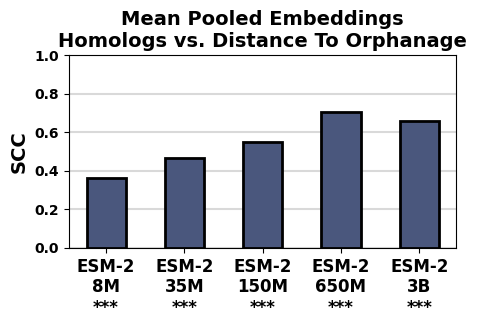

In [206]:
fig, ax = plt.subplots(figsize = (5.,2.5))


needed_method = "mean"
needed_col = "homs_v_orphanage"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    if k == "esm_2_15B":
        continue 
    x.append(i)
    y.append(v["corr"])
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)
    
ax.set_ylabel(r"SCC", fontsize = 14, fontweight = "bold")

ax.set_title("Mean Pooled Embeddings\nHomologs vs. Distance To Orphanage", fontsize = 14, fontweight = "bold")

Text(0.5, 1.0, 'Mean Pooled Embeddings\nHomologs vs. PC1')

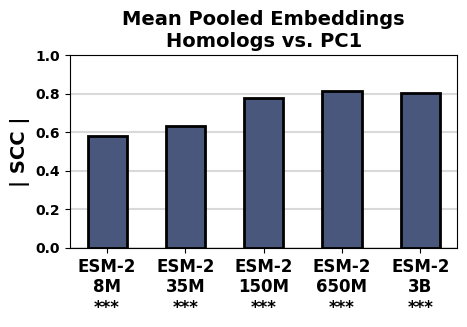

In [208]:
fig, ax = plt.subplots(figsize = (5.,2.5))


needed_method = "mean"
needed_col = "homs_v_PC1"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    if k == "esm_2_15B":
        continue 
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)
    
ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")
ax.set_title("Mean Pooled Embeddings\nHomologs vs. PC1", fontsize = 14,  fontweight = "bold")

Text(0.5, 1.0, 'Mean Pooled Embeddings\nHomologs vs. PC2')

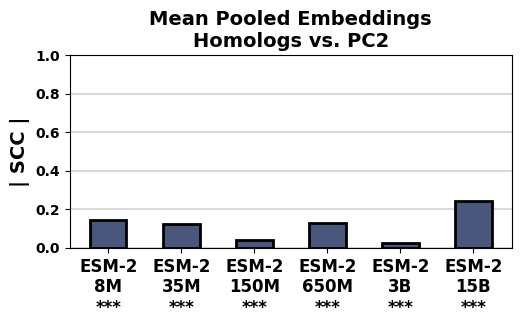

In [209]:
fig, ax = plt.subplots(figsize = (5.7,2.5))


needed_method = "mean"
needed_col = "homs_v_PC2"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)
    
ax.set_ylabel(r"| SCC |", fontsize = 14, fontweight = "bold")

ax.set_title("Mean Pooled Embeddings\nHomologs vs. PC2", fontsize = 14, fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings\nHomologs vs. Distance To Orphanage')

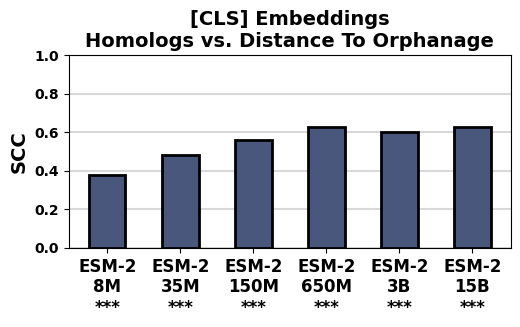

In [207]:
fig, ax = plt.subplots(figsize = (5.7,2.5))


needed_method = "cls"
needed_col = "homs_v_orphanage"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(v["corr"])
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)
    
ax.set_ylabel(r"SCC", fontsize = 14,  fontweight = "bold")

ax.set_title("[CLS] Embeddings\nHomologs vs. Distance To Orphanage", fontsize = 14, fontweight = "bold")

[0.8239361462312844, 0.8938131982290419, 0.7862612058641077, 0.9080824765441541, 0.9069912940442667]


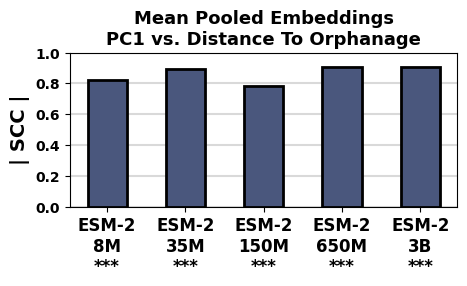

In [195]:

fig, ax = plt.subplots(figsize = (5,2))


needed_method = "mean"
needed_col = "orphanage_dist_v_PC1"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    if k == "esm_2_15B":
        continue 
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)


ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)
    
ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")
ax.set_title("Mean Pooled Embeddings\nPC1 vs. Distance To Orphanage", fontsize = 13, fontweight = "bold")

print(y)

Text(0.5, 1.0, 'Mean Pooled Embeddings\nPC2 vs. Distance To Orphanage')

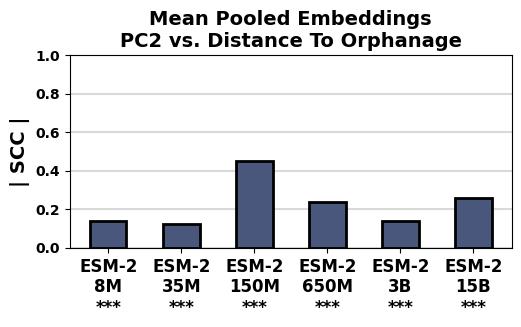

In [210]:
fig, ax = plt.subplots(figsize = (5.7, 2.5))


needed_method = "mean"
needed_col = "orphanage_dist_v_PC2"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)


ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")



ax.set_title("Mean Pooled Embeddings\nPC2 vs. Distance To Orphanage", fontsize = 14, fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings\nPC1 vs. Distance To Orphanage')

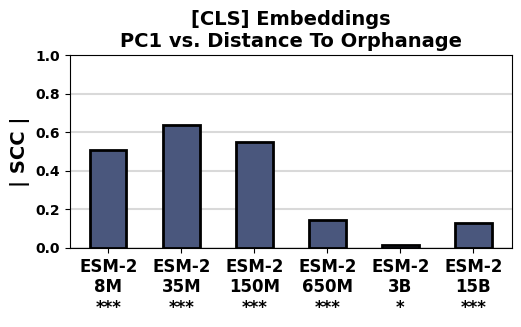

In [211]:
fig, ax = plt.subplots(figsize = (5.7,2.5))


needed_method = "cls"
needed_col = "orphanage_dist_v_PC1"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")
ax.set_title("[CLS] Embeddings\nPC1 vs. Distance To Orphanage", fontsize = 14, fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings\nPC2 vs. Distance To Orphanage')

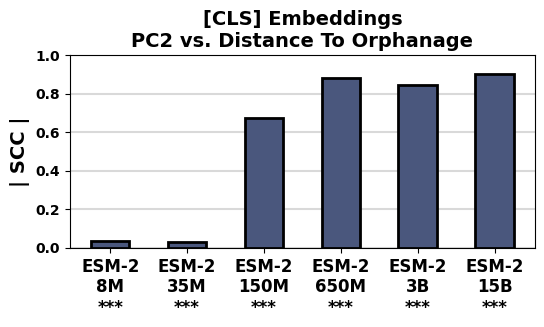

In [198]:
fig, ax = plt.subplots(figsize = (6,2.5))


needed_method = "cls"
needed_col = "orphanage_dist_v_PC2"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)

ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")

ax.set_title("[CLS] Embeddings\nPC2 vs. Distance To Orphanage", fontsize = 14,  fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings\nHomologs vs. PC1')

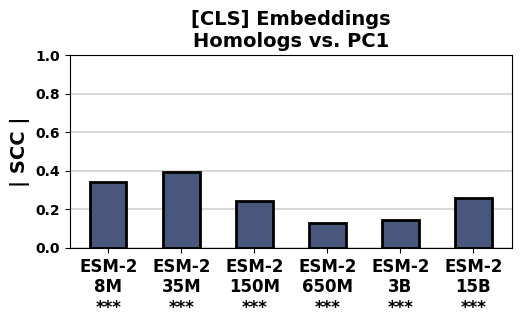

In [212]:
fig, ax = plt.subplots(figsize = (5.7,2.5))


needed_method = "cls"
needed_col = "homs_v_PC1"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)


ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")

ax.set_title("[CLS] Embeddings\nHomologs vs. PC1", fontsize = 14, fontweight = "bold")

Text(0.5, 1.0, '[CLS] Embeddings\nHomologs vs. PC2')

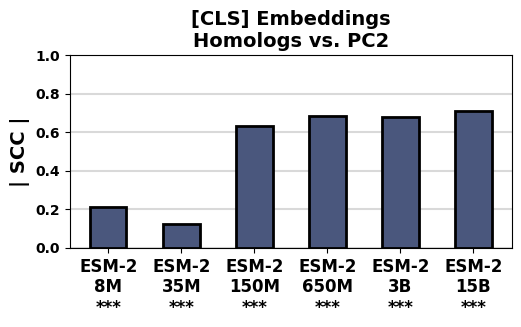

In [213]:
fig, ax = plt.subplots(figsize = (5.7,2.5))


needed_method = "cls"
needed_col = "homs_v_PC2"

data = pc_correlation_tracker[needed_method][needed_col]

x = [] 
y = []
labels = []
p_star_list = []
for i, (k, v) in enumerate(data.items()):
    x.append(i)
    y.append(abs(v["corr"]))
    p_star_list.append(p_val_to_stars(v["p"]))
    labels.append(key_to_label_2[k] + "\n" + p_val_to_stars(v["p"]))
    

ax.set_xticks(x)
ax.bar(x,y, color = "#4a577d", edgecolor = "black", alpha = 1, width = 0.5, linewidth = 2, zorder = 100)


ax.set_xticklabels(labels, fontsize = 12, fontweight = "bold")
ax.set_yticks([0, 0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10, fontweight = "bold")
# ax.set_yticks(ax.get_yticks())
for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

ax.set_ylabel(r"| SCC |", fontsize = 14,  fontweight = "bold")

ax.set_title("[CLS] Embeddings\nHomologs vs. PC2", fontsize = 14,  fontweight = "bold")

In [201]:
large_supp_table_vals = copy.deepcopy(table_vals)



mean_table = large_supp_table_vals.loc[large_supp_table_vals["embedding_type"] == "mean_pooled"]
cls_table = large_supp_table_vals.loc[large_supp_table_vals["embedding_type"] == "CLS"]

df_pieces_mean = []
for model, sub_df in mean_table.groupby("model"):
    model_str = model.replace("(", "").replace(")", "")
    sub_df = copy.deepcopy(sub_df)
    sub_df["PC1"] = sub_df["name"].apply(lambda x : pc_tracker["PC1"]["mean"][model_str][x])
    sub_df["PC2"] = sub_df["name"].apply(lambda x : pc_tracker["PC2"]["mean"][model_str][x])
    df_pieces_mean.append(sub_df)
    
for sub_df in df_pieces_mean:
    
    x = sub_df["orphanage_distance"].values
    y = sub_df["PC1"].values
    z = sub_df["PC2"].values
    h = sub_df["log_2 UR50 homologs"].values
    
    print("PC1 v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,y), )
    print("PC2 v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,z), )
    print("homs v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,h), )
    
df_pieces_cls = []
for model, sub_df in cls_table.groupby("model"):
    model_str = model.replace("(", "").replace(")", "")
    sub_df = copy.deepcopy(sub_df)
    sub_df["PC1"] = sub_df["name"].apply(lambda x : pc_tracker["PC1"]["cls"][model_str][x])
    sub_df["PC2"] = sub_df["name"].apply(lambda x : pc_tracker["PC2"]["cls"][model_str][x])
    df_pieces_cls.append(sub_df)


print("########################")
for sub_df in df_pieces_cls:
    
    x = sub_df["orphanage_distance"].values
    y = sub_df["PC1"].values
    z = sub_df["PC2"].values
    h = sub_df["log_2 UR50 homologs"].values
    print("PC1 v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,y)[0], )
    print("PC2 v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,z), )
    print("homs v orphanage dist")
    print(sub_df.iloc[0]["model"], scipy.stats.spearmanr(x,h), )


PC1 v orphanage dist
ESM-2 (150M) SpearmanrResult(correlation=0.7862612058641077, pvalue=0.0)
PC2 v orphanage dist
ESM-2 (150M) SpearmanrResult(correlation=0.4486997044353029, pvalue=0.0)
homs v orphanage dist
ESM-2 (150M) SpearmanrResult(correlation=0.5509984071225976, pvalue=0.0)
PC1 v orphanage dist
ESM-2 (15B) SpearmanrResult(correlation=-0.9119484100124072, pvalue=0.0)
PC2 v orphanage dist
ESM-2 (15B) SpearmanrResult(correlation=0.26025253597628395, pvalue=0.0)
homs v orphanage dist
ESM-2 (15B) SpearmanrResult(correlation=0.6540175157373722, pvalue=0.0)
PC1 v orphanage dist
ESM-2 (35M) SpearmanrResult(correlation=0.8938131982290419, pvalue=0.0)
PC2 v orphanage dist
ESM-2 (35M) SpearmanrResult(correlation=0.12485020544172806, pvalue=2.1179506844940817e-87)
homs v orphanage dist
ESM-2 (35M) SpearmanrResult(correlation=0.46408793596997816, pvalue=0.0)
PC1 v orphanage dist
ESM-2 (3B) SpearmanrResult(correlation=0.9069912940442667, pvalue=0.0)
PC2 v orphanage dist
ESM-2 (3B) SpearmanrR

In [202]:
identifiers_full, seqs = read_fasta("../../Orphan25/random_UR50_protein_embedding_experiment/randomly_chosen_proteins_UR50.fasta", return_headers=True)
identifiers_cleaned = list(map(lambda x : x.split(" ")[0], identifiers_full))

cleaned_ident_to_full = dict(zip(identifiers_cleaned, identifiers_full))

ident_to_seq = dict(zip(identifiers_cleaned, seqs))

df_mean_pooled_large = pd.concat(df_pieces_mean)
df_cls_large = pd.concat(df_pieces_cls)

df_large = pd.concat([df_mean_pooled_large, df_cls_large])
df_large["sequence"] = df_large["name"].apply(lambda x : ident_to_seq[x])
df_large["full_identifier"] = df_large["name"].apply(lambda x : cleaned_ident_to_full[x])

In [203]:
df_large.to_csv(supp_table_path + "orphanage_pcs_homologs_seqeunces_all_models_all_pooling.csv")

In [204]:
df_large.loc[df_large["name"] == "UniRef50_A0A832H6K0"]

,model,embedding_type,name,log_2 UR50 homologs,orphanage_distance,PC1,PC2,sequence,full_identifier
50003,ESM-2 (150M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.187409,1.212288,0.850855,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
125003,ESM-2 (15B),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.572154,-1.539322,0.321201,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
25003,ESM-2 (35M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.307121,2.024393,0.107573,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
100003,ESM-2 (3B),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.059901,1.253736,0.053251,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
75003,ESM-2 (650M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.145047,1.410778,0.378883,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
3,ESM-2 (8M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.434234,1.905594,0.095798,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
200003,ESM-2 (150M),CLS,UniRef50_A0A832H6K0,14.792028,0.041657,0.038050,0.265701,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
275003,ESM-2 (15B),CLS,UniRef50_A0A832H6K0,14.792028,0.096512,1.276945,-0.222580,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
175003,ESM-2 (35M),CLS,UniRef50_A0A832H6K0,14.792028,0.092883,1.032305,-0.389184,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
250003,ESM-2 (3B),CLS,UniRef50_A0A832H6K0,14.792028,0.011126,-0.590422,-0.347712,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
